In [1]:
import torch
import torchvision

#https://github.com/JohannesTheo/multi_object_datasets_torch
# @misc{multiobjectdatasets19,
#   title={Multi-Object Datasets},
#   author={Kabra, Rishabh and Burgess, Chris and Matthey, Loic and
#           Kaufman, Raphael Lopez and Greff, Klaus and Reynolds, Malcolm and
#           Lerchner, Alexander},
#   howpublished={https://github.com/JohannesTheo/multi_object_datasets_torch},
#   year={2019}
# }
from multi_object_datasets_torch import MultiDSprites ,ClevrWithMasks,Tetrominoes


import model_solved as models
import tqdm
import argparse
import pickle
import matplotlib.pyplot as plt

In [2]:

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

parser = argparse.ArgumentParser()

model_dir='broadcast'
seed=0
batch_size=300
num_slots=7
num_iterations=3
hid_dim=64
learning_rate=10e-3
warmup_steps=2
decay_rate=0
num_workers=20
num_epochs=1000
decay_steps=num_epochs
reload=False

parser.add_argument('--model_dir', default=model_dir, type=str, help='where to save models' )
parser.add_argument('--seed', default=seed, type=int, help='random seed')
parser.add_argument('--batch_size', default=batch_size, type=int)
parser.add_argument('--num_slots', default=num_slots, type=int, help='# of slots')
parser.add_argument('--num_iterations', default=num_iterations, type=int, help='# iterations')
parser.add_argument('--hid_dim', default=hid_dim, type=int, help='hidden dimension size')
parser.add_argument('--learning_rate', default=learning_rate, type=float)
parser.add_argument('--warmup_steps', default=warmup_steps, type=int, help='# of warmup steps')
parser.add_argument('--decay_rate', default=decay_rate, type=float, help='decay rate')
parser.add_argument('--decay_steps', default=decay_steps, type=float, help='decay rate')
parser.add_argument('--num_workers', default=num_workers, type=int, help='# of workers for loading data')
parser.add_argument('--num_epochs', default=num_workers, type=int, help='# of epochs')

# opt = parser.parse_args()
# model_dir=opt.model_dir
# seed=opt.seed
# batch_size=opt.batch_size
# num_slots=opt.num_slots
# num_iterations=opt.num_iterations
# hid_dim=opt.hid_dim
# learning_rate=opt.learning_rate
# warmup_steps=opt.warmup_steps
# decay_rate=opt.decay_rate
# num_workers=opt.num_workers
# num_epochs=opt.num_epochs

_StoreAction(option_strings=['--num_epochs'], dest='num_epochs', nargs=None, const=None, default=20, type=<class 'int'>, choices=None, required=False, help='# of epochs', metavar=None)

In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ConvertImageDtype(torch.float32),
])


In [4]:
train_set=Tetrominoes("data/Tetrominoes",download=True)
train_dataloader=torch.utils.data.DataLoader(train_set,batch_size=batch_size,shuffle=True,num_workers=num_workers)

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0

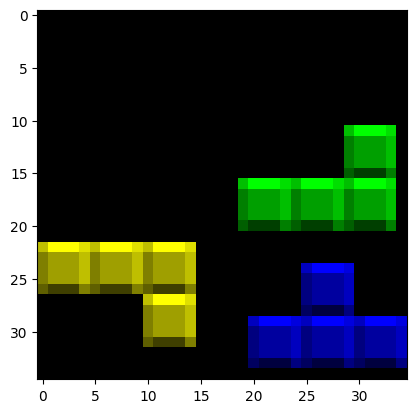

In [5]:
torch.manual_seed(seed)

visual=transform(train_set[0]['image'].unsqueeze(0)).to(device)
plt.imshow(visual.detach().to('cpu')[0,:,:,:].permute(1,2,0))
print(visual)

In [6]:
loss_evolution=[]
model=models.AutoEncoder(target_resolution=(35,35),slot_iterations=num_iterations,just_alpha=False,n_slots=num_slots).to(device)
if reload:
    model.load_state_dict(torch.load(model_dir+"/autosave.pt", weights_only=True), strict=False)
    with open(model_dir+"/stats.pkl",'rb') as r:
        loss_evolution=pickle.load(r)

In [7]:
def lr_sched(epoch):
    epoch+=1
    lr=learning_rate
    if epoch<warmup_steps:
        lr=lr/(epoch/warmup_steps)
    #lr*=decay_rate**(epoch/decay_steps)
    return lr

In [8]:
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
crit=torch.nn.MSELoss()
sched=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_sched)

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 28.494918823242188, epoch:0/1000


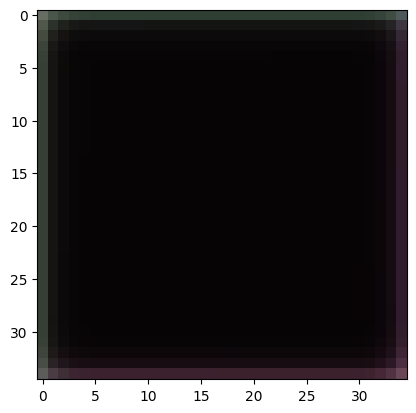

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 16.331289291381836, epoch:1/1000


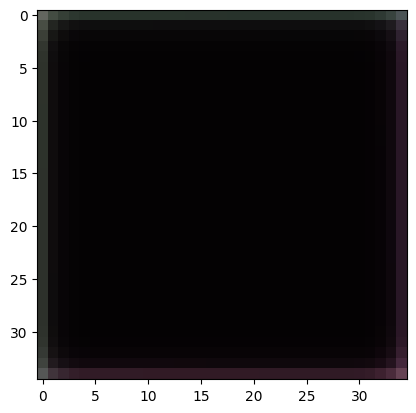

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 16.221397399902344, epoch:2/1000


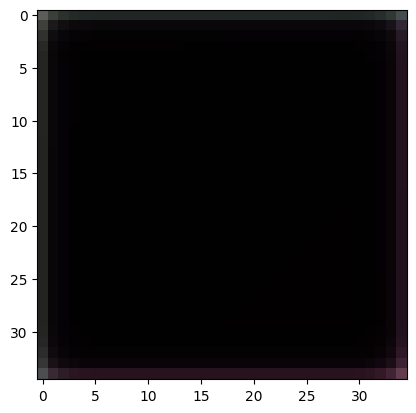

100%|██████████| 300/300 [00:54<00:00,  5.47it/s]


loss: 16.126522064208984, epoch:3/1000


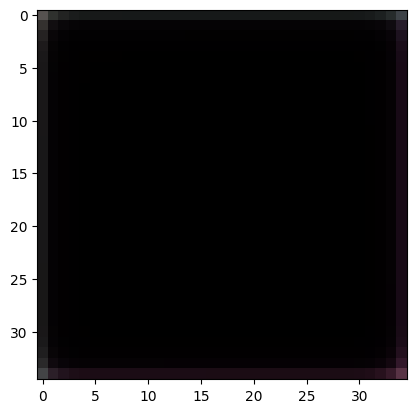

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 16.049320220947266, epoch:4/1000


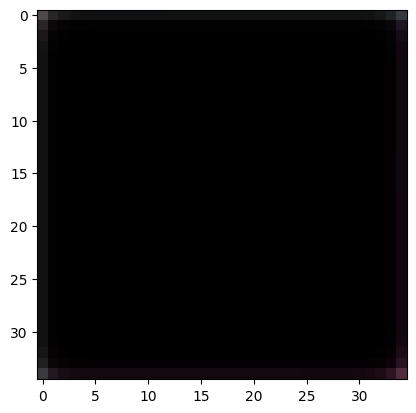

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.998318672180176, epoch:5/1000


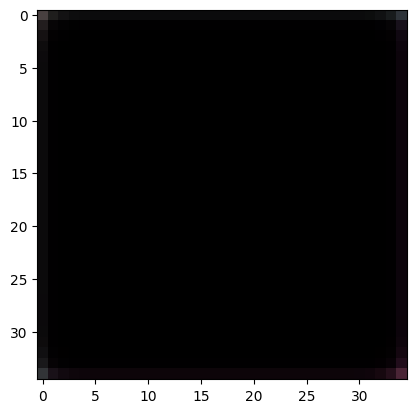

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 15.969890594482422, epoch:6/1000


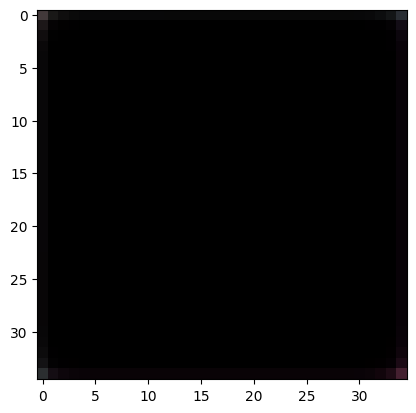

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 15.954484939575195, epoch:7/1000


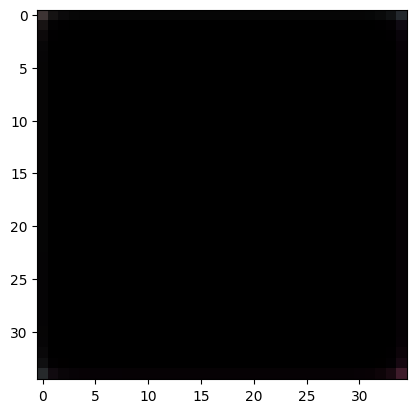

100%|██████████| 300/300 [00:54<00:00,  5.47it/s]


loss: 15.945597648620605, epoch:8/1000


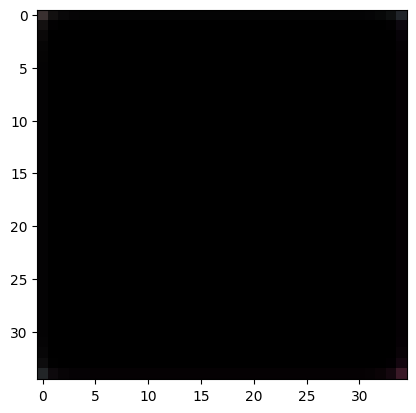

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 15.93997859954834, epoch:9/1000


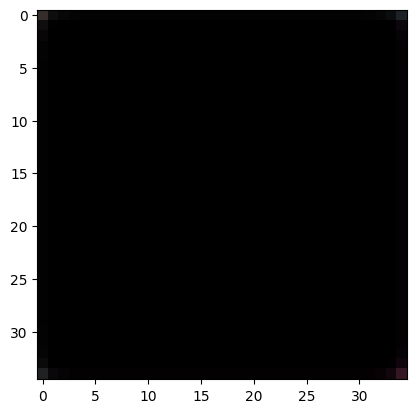

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 15.936128616333008, epoch:10/1000


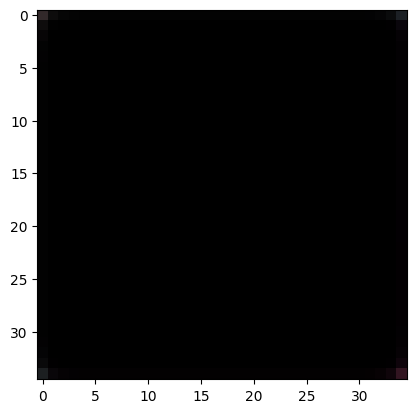

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.93332576751709, epoch:11/1000


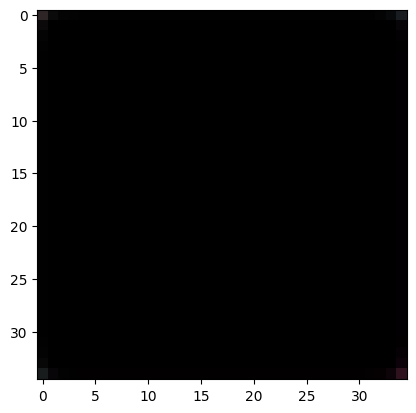

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.931180000305176, epoch:12/1000


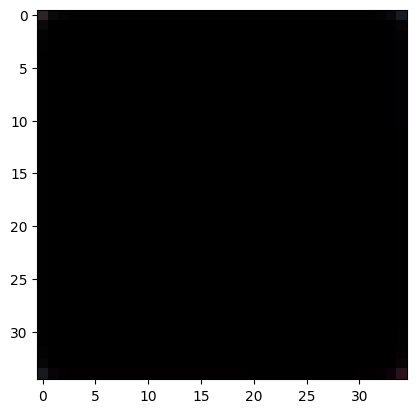

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.929466247558594, epoch:13/1000


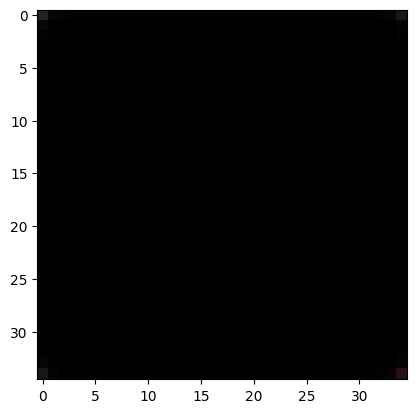

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.928071975708008, epoch:14/1000


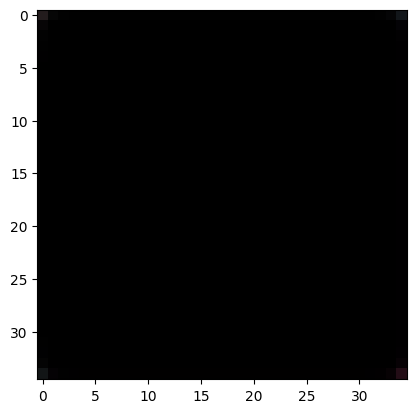

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 15.926892280578613, epoch:15/1000


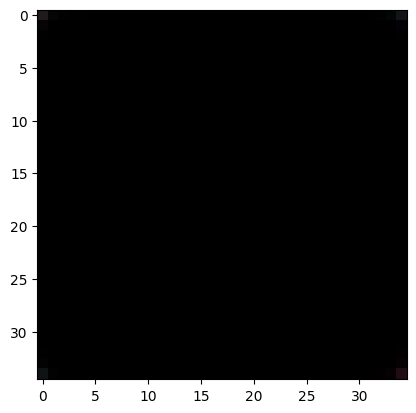

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.925887107849121, epoch:16/1000


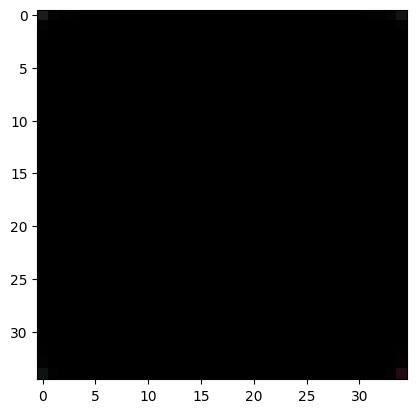

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.925039291381836, epoch:17/1000


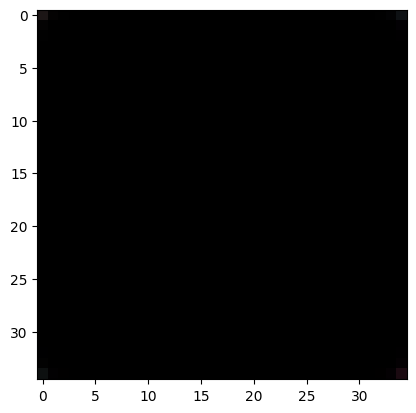

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.92431354522705, epoch:18/1000


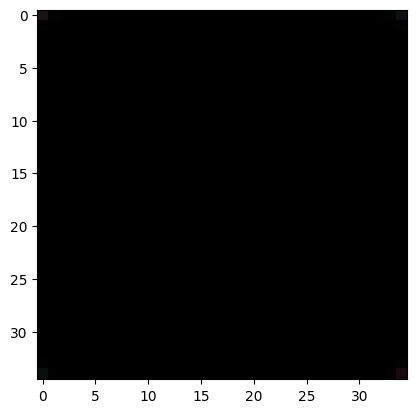

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.923694610595703, epoch:19/1000


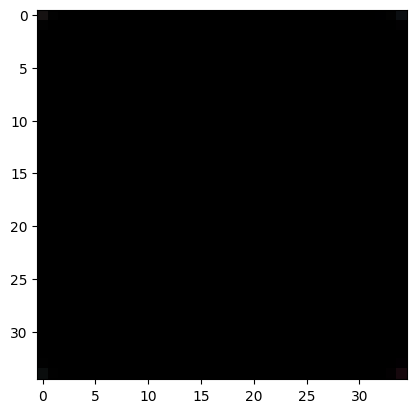

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.923188209533691, epoch:20/1000


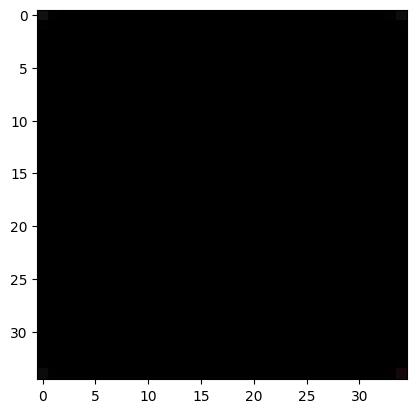

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.922739028930664, epoch:21/1000


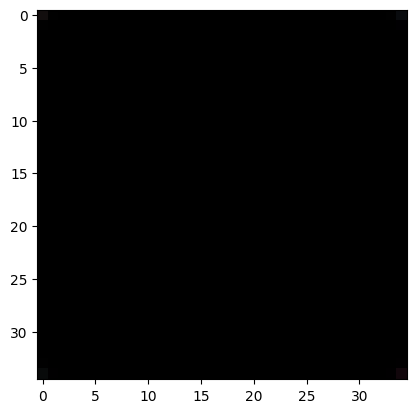

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.922368049621582, epoch:22/1000


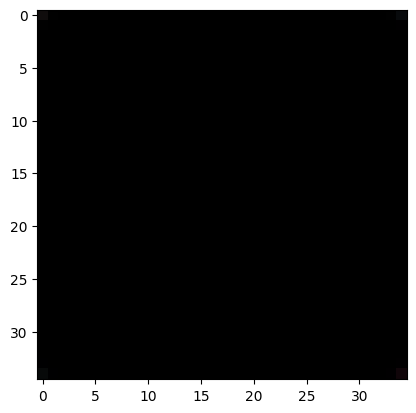

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.922056198120117, epoch:23/1000


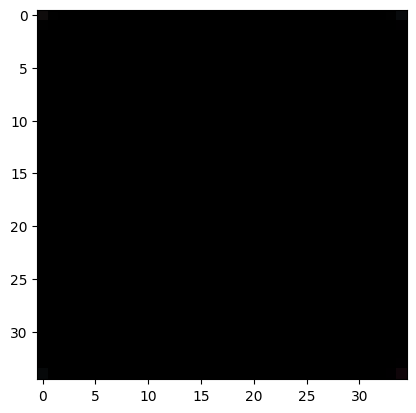

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.921821594238281, epoch:24/1000


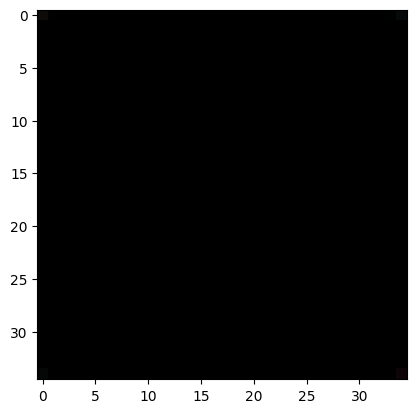

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.921642303466797, epoch:25/1000


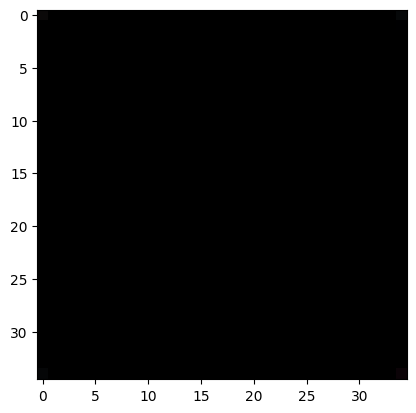

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.921483993530273, epoch:26/1000


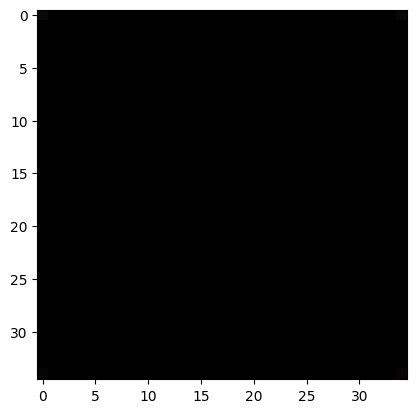

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 15.921360969543457, epoch:27/1000


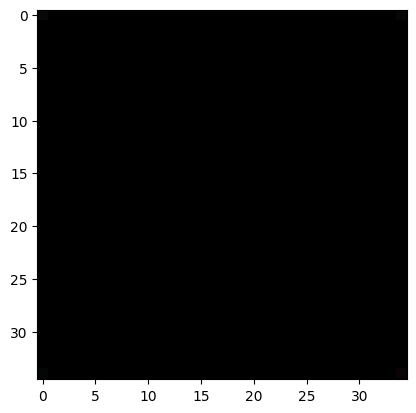

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.921271324157715, epoch:28/1000


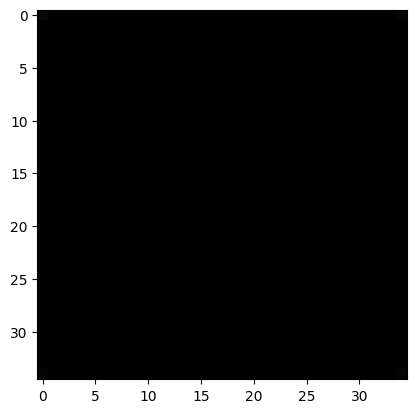

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.92119026184082, epoch:29/1000


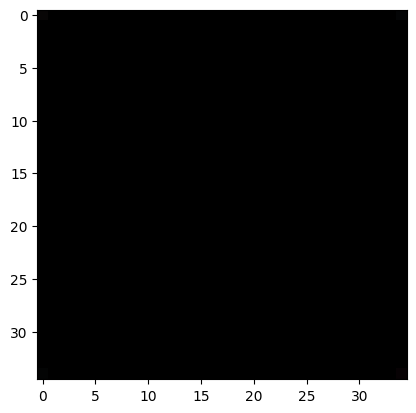

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.921130180358887, epoch:30/1000


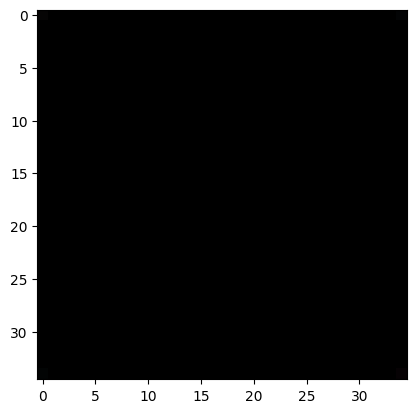

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.921082496643066, epoch:31/1000


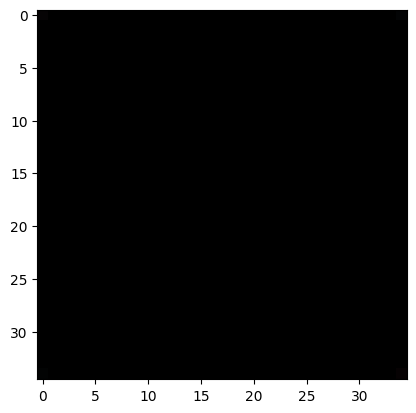

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.921041488647461, epoch:32/1000


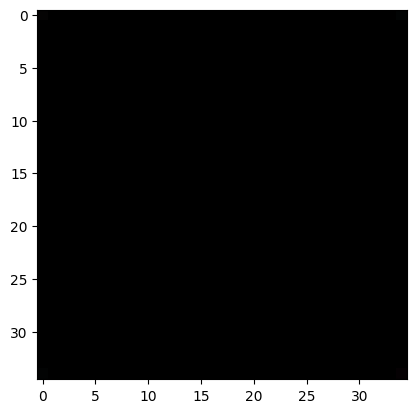

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.92101001739502, epoch:33/1000


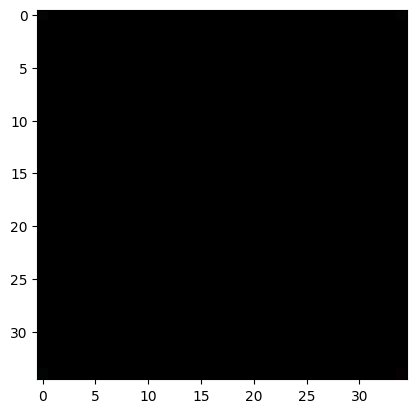

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 15.920989036560059, epoch:34/1000


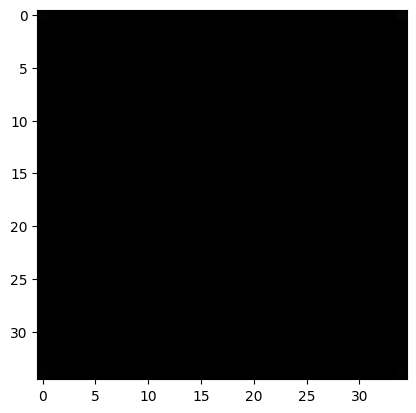

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920970916748047, epoch:35/1000


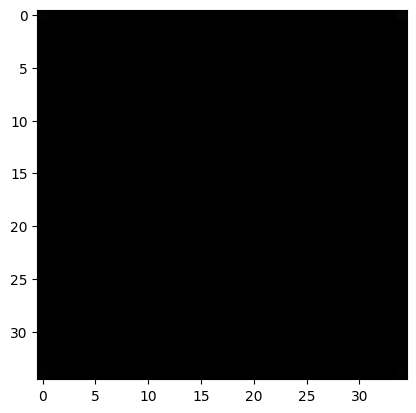

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920958518981934, epoch:36/1000


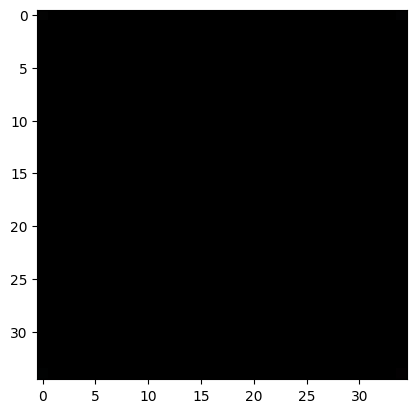

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 15.920945167541504, epoch:37/1000


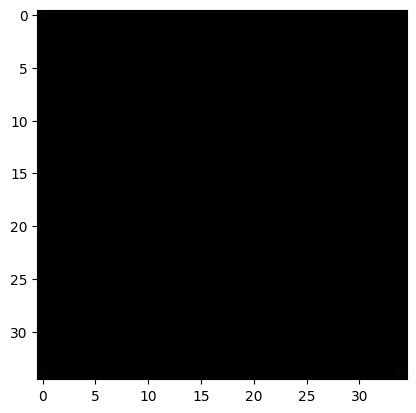

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920936584472656, epoch:38/1000


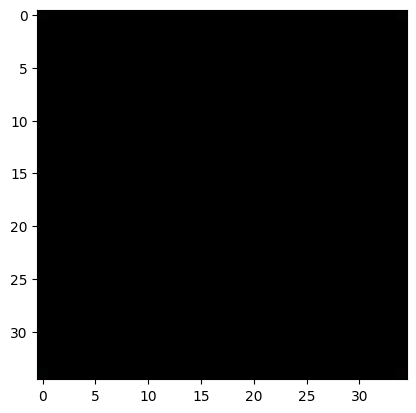

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920924186706543, epoch:39/1000


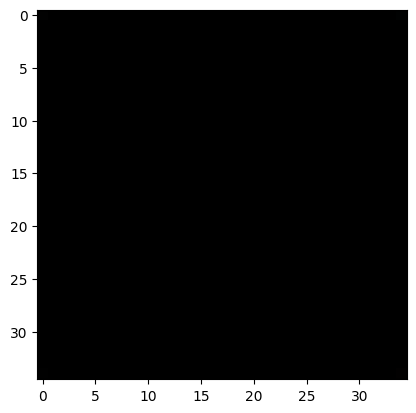

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920918464660645, epoch:40/1000


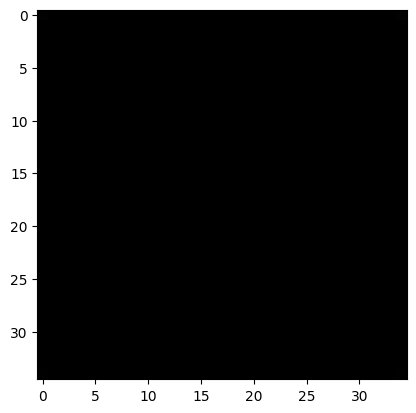

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 15.920914649963379, epoch:41/1000


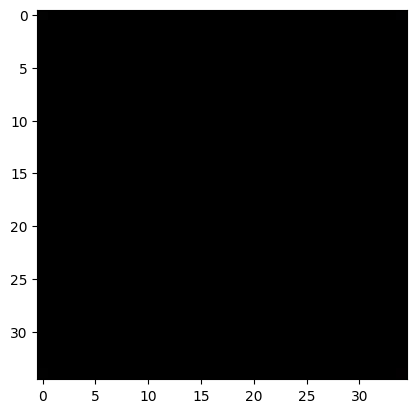

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.920903205871582, epoch:42/1000


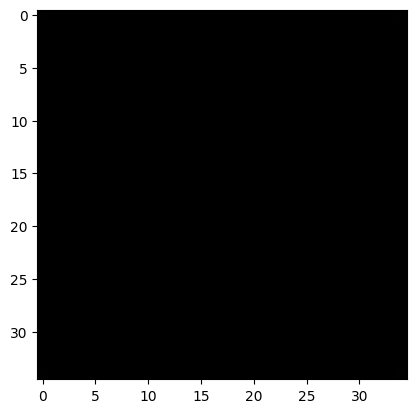

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920906066894531, epoch:43/1000


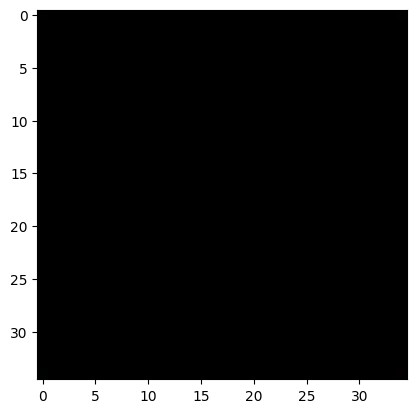

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920899391174316, epoch:44/1000


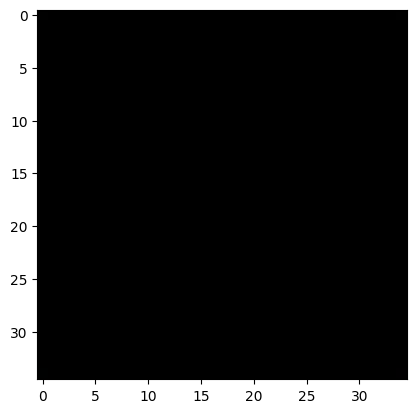

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920903205871582, epoch:45/1000


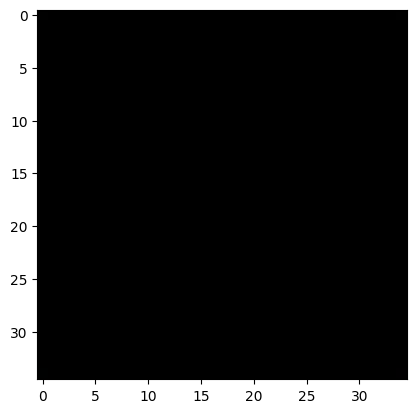

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920899391174316, epoch:46/1000


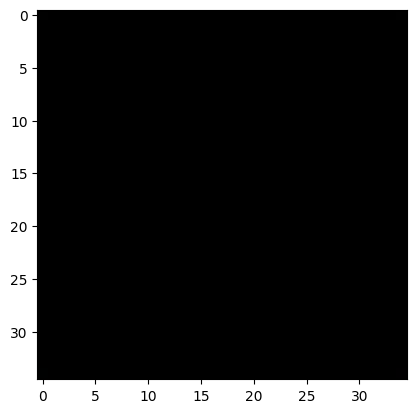

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 15.920897483825684, epoch:47/1000


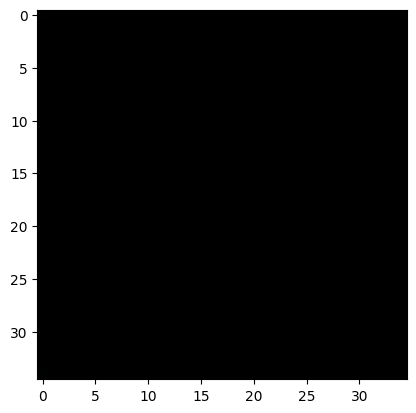

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 15.920892715454102, epoch:48/1000


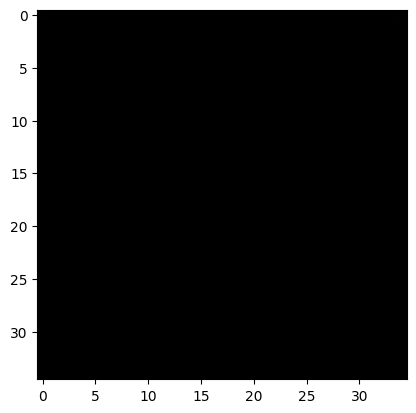

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920897483825684, epoch:49/1000


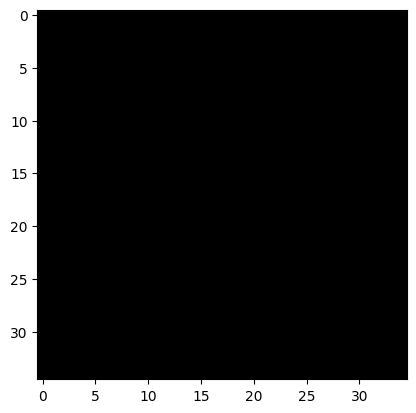

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920886993408203, epoch:50/1000


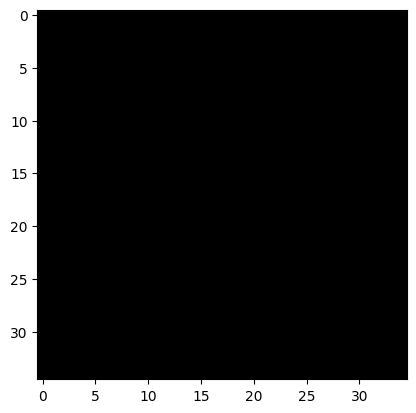

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920896530151367, epoch:51/1000


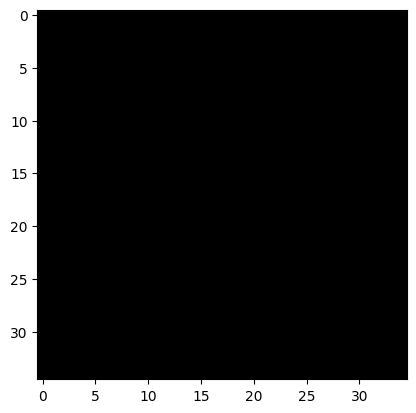

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920890808105469, epoch:52/1000


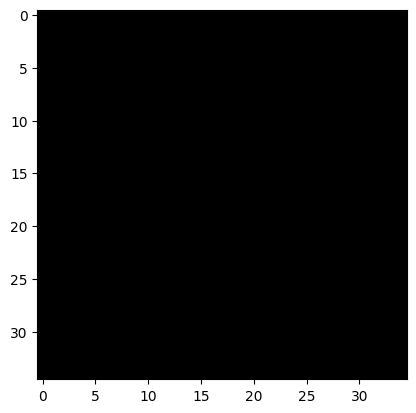

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.920893669128418, epoch:53/1000


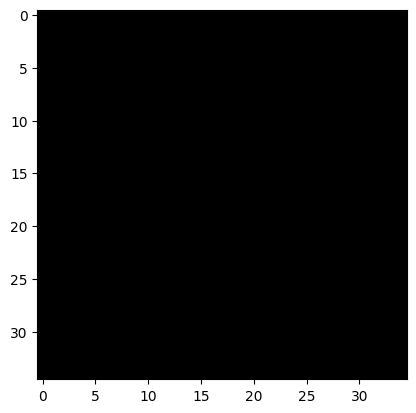

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.92088794708252, epoch:54/1000


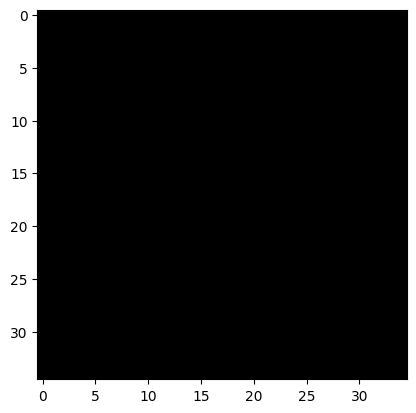

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 15.920899391174316, epoch:55/1000


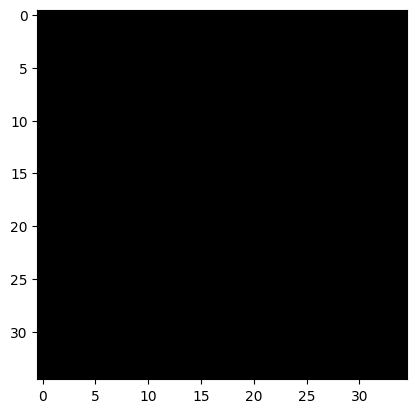

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 15.92088794708252, epoch:56/1000


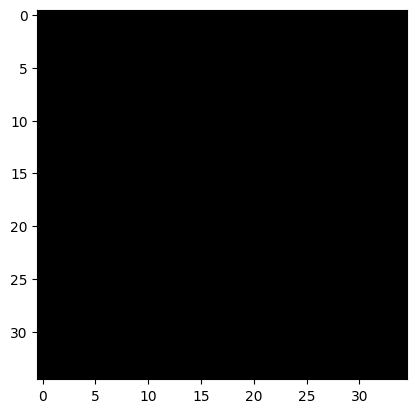

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 15.920886039733887, epoch:57/1000


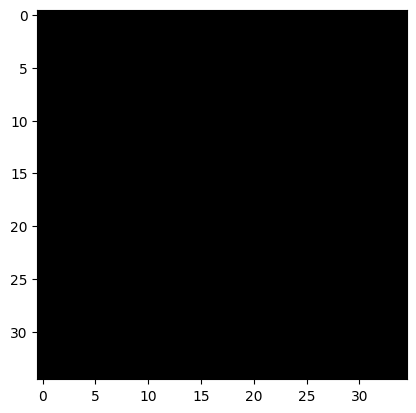

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920893669128418, epoch:58/1000


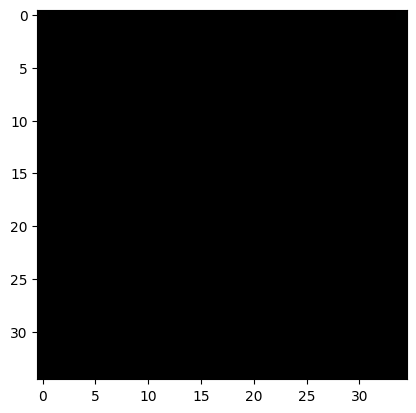

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920886039733887, epoch:59/1000


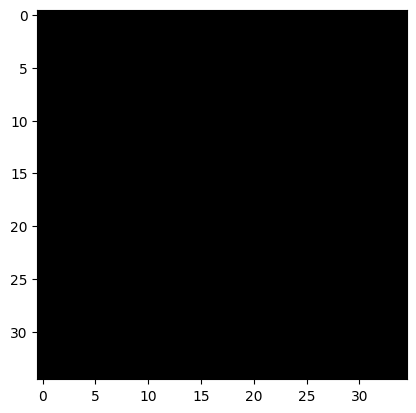

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 15.920892715454102, epoch:60/1000


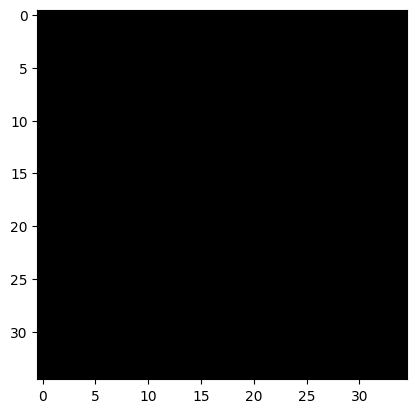

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.92089557647705, epoch:61/1000


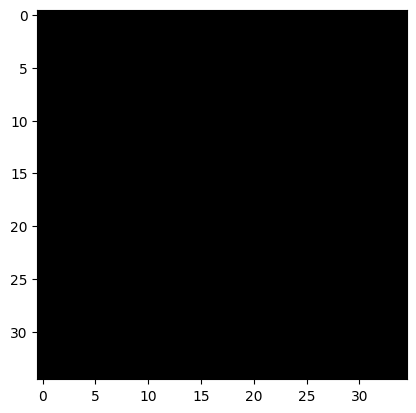

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920890808105469, epoch:62/1000


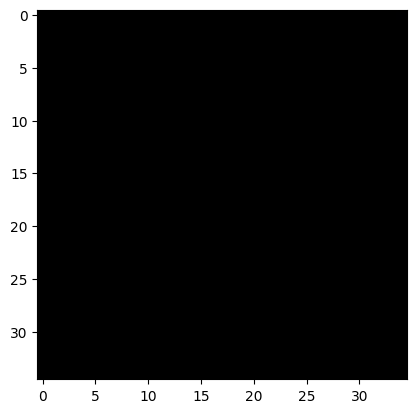

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 15.920889854431152, epoch:63/1000


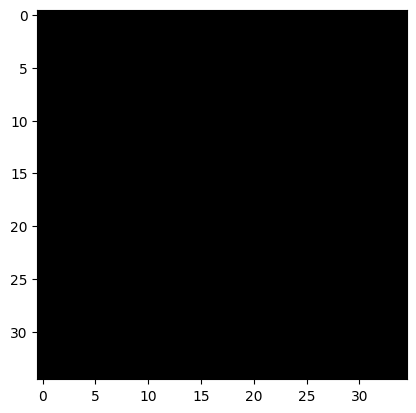

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920890808105469, epoch:64/1000


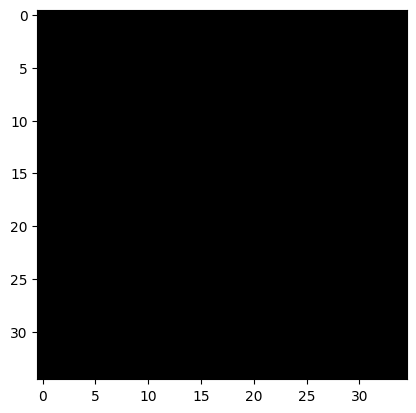

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 15.920890808105469, epoch:65/1000


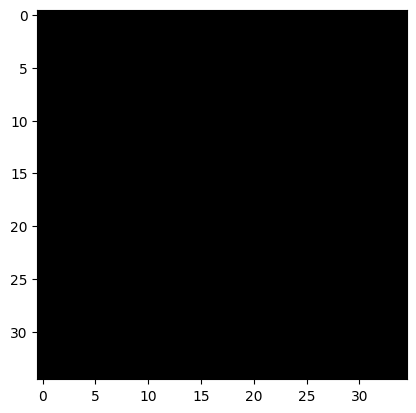

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.92088794708252, epoch:66/1000


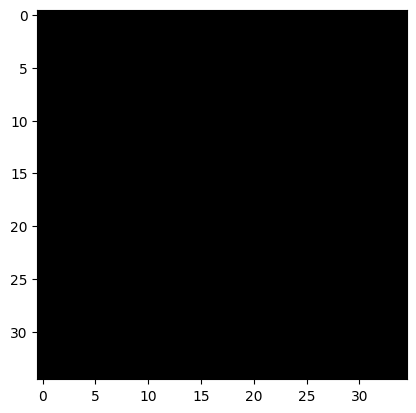

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 15.92088794708252, epoch:67/1000


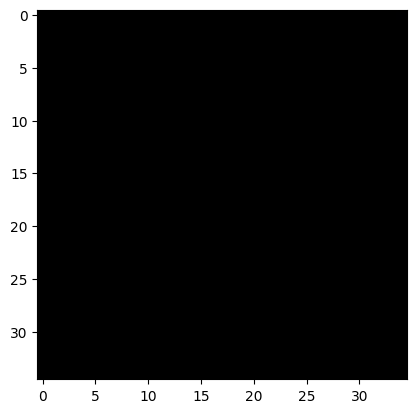

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.920894622802734, epoch:68/1000


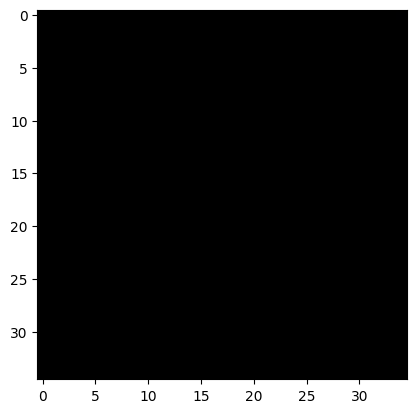

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920892715454102, epoch:69/1000


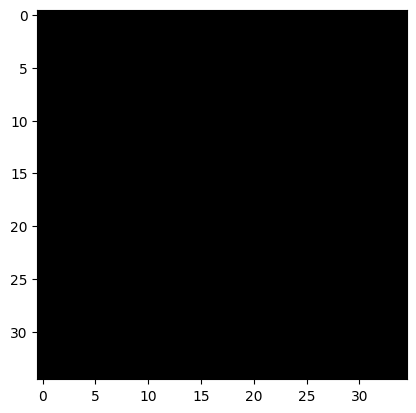

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920891761779785, epoch:70/1000


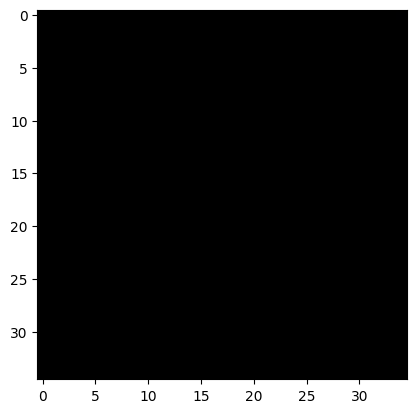

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920891761779785, epoch:71/1000


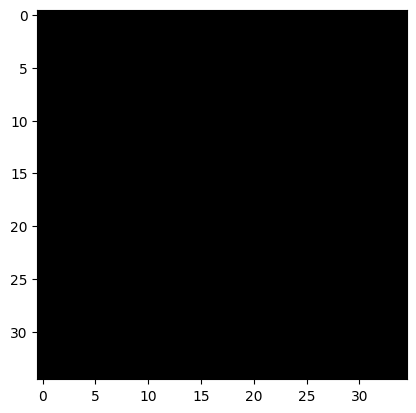

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920899391174316, epoch:72/1000


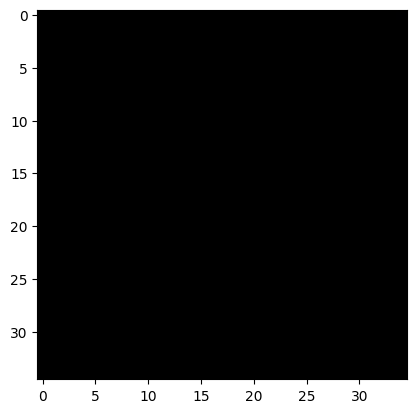

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.92089557647705, epoch:73/1000


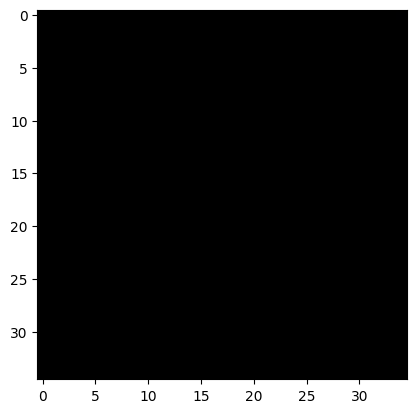

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.920888900756836, epoch:74/1000


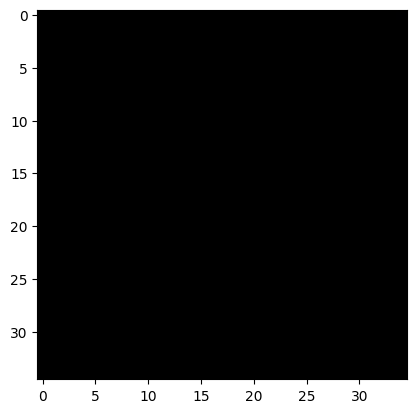

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920889854431152, epoch:75/1000


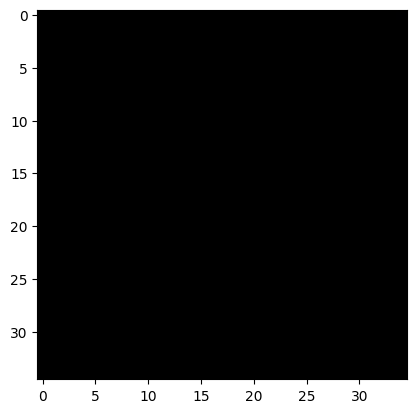

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920889854431152, epoch:76/1000


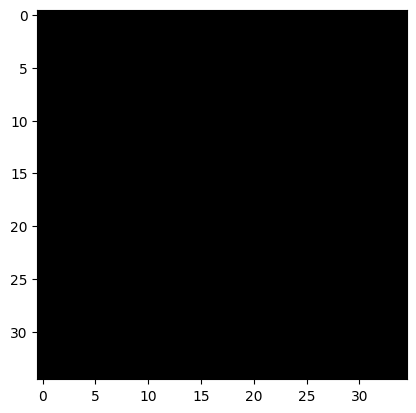

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920893669128418, epoch:77/1000


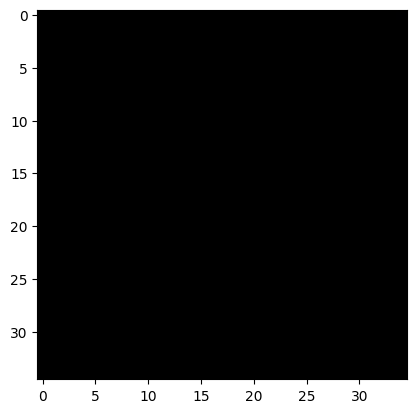

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920888900756836, epoch:78/1000


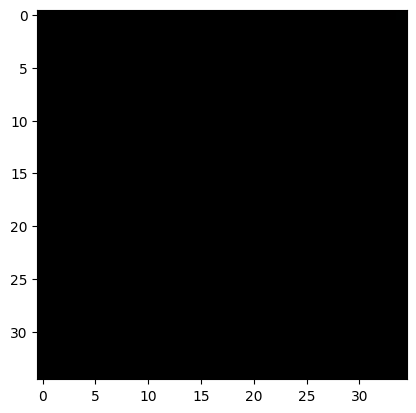

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920892715454102, epoch:79/1000


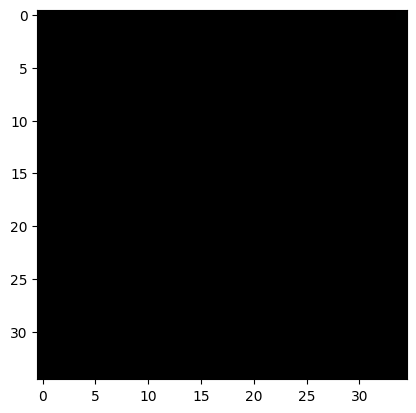

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920892715454102, epoch:80/1000


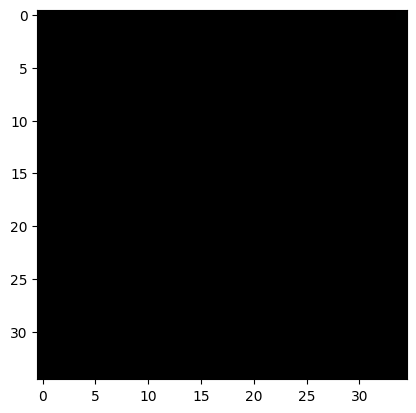

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.92088794708252, epoch:81/1000


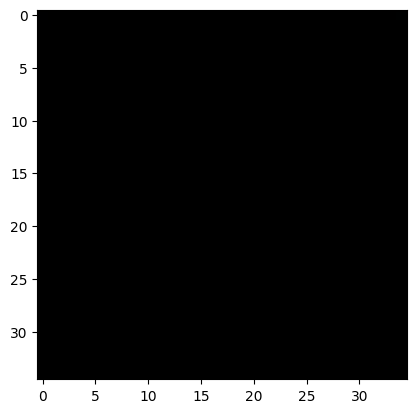

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920888900756836, epoch:82/1000


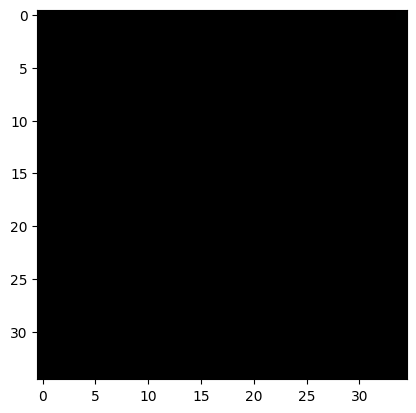

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920890808105469, epoch:83/1000


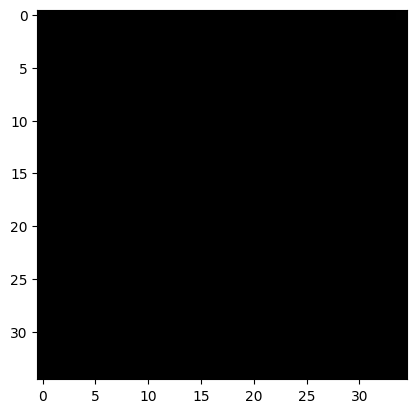

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920894622802734, epoch:84/1000


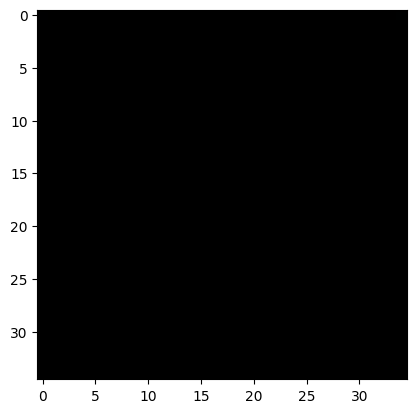

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920893669128418, epoch:85/1000


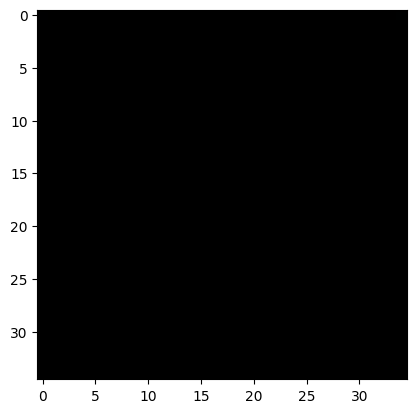

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.920886039733887, epoch:86/1000


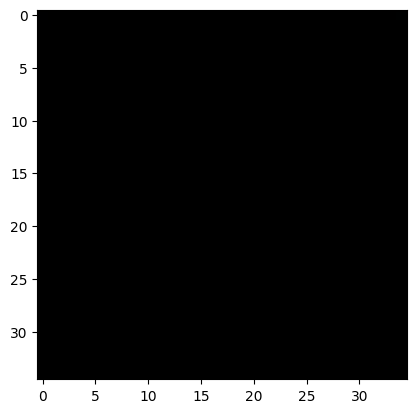

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.92089557647705, epoch:87/1000


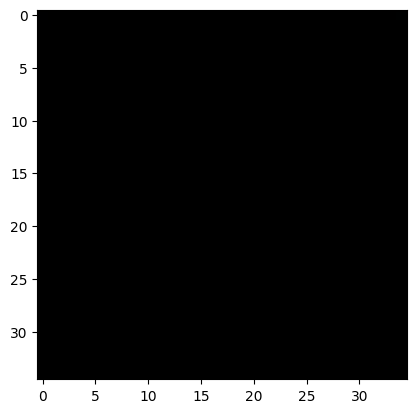

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920892715454102, epoch:88/1000


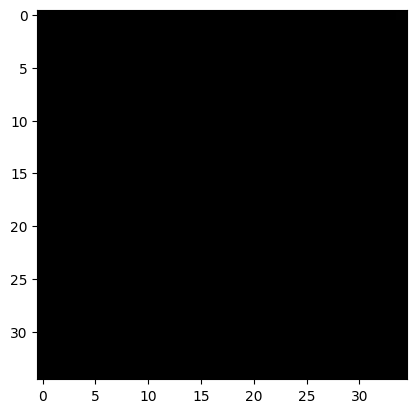

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920891761779785, epoch:89/1000


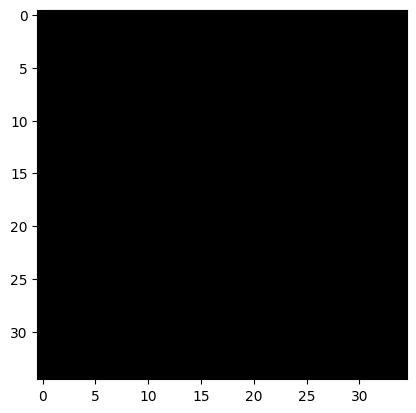

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.920890808105469, epoch:90/1000


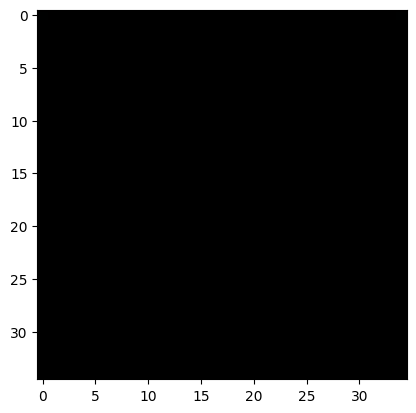

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 15.920890808105469, epoch:91/1000


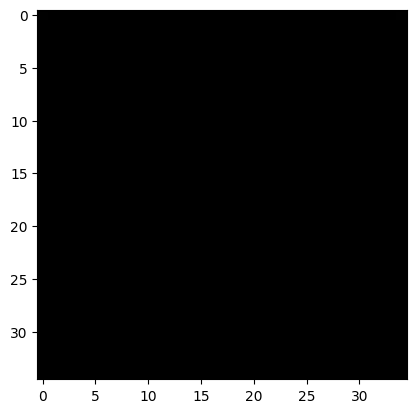

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.92088508605957, epoch:92/1000


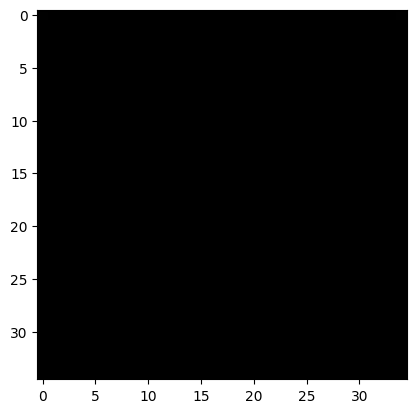

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.920886993408203, epoch:93/1000


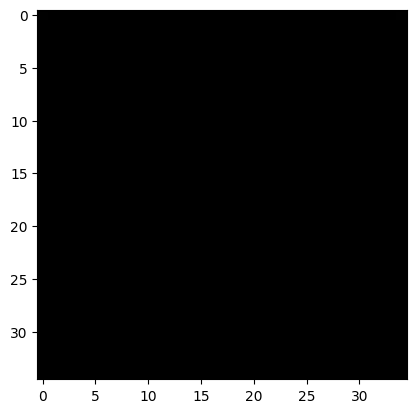

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.92088794708252, epoch:94/1000


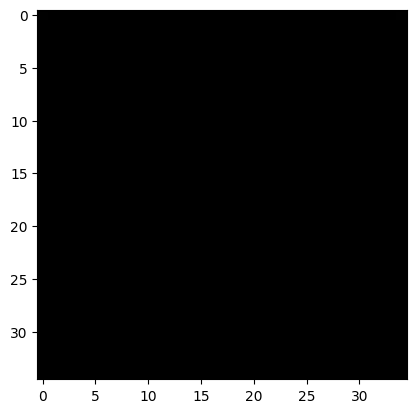

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 15.920877456665039, epoch:95/1000


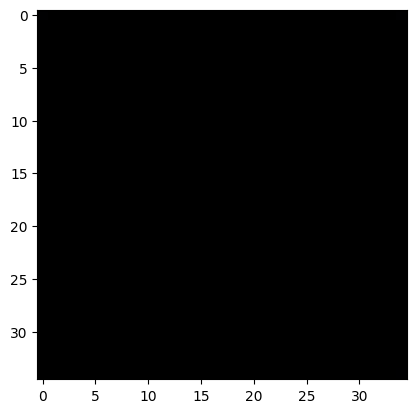

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.807238578796387, epoch:96/1000


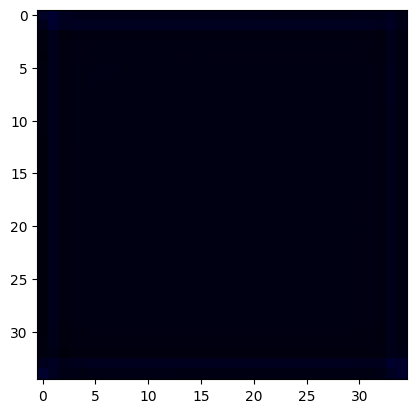

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 15.261507034301758, epoch:97/1000


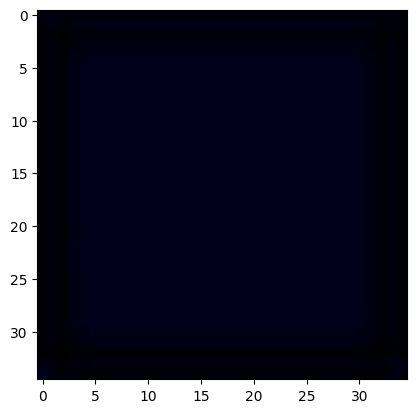

100%|██████████| 300/300 [00:53<00:00,  5.56it/s]


loss: 15.220161437988281, epoch:98/1000


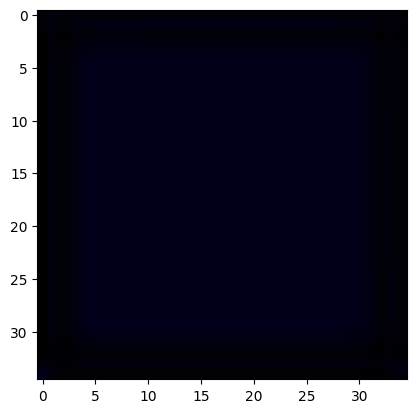

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 15.19327449798584, epoch:99/1000


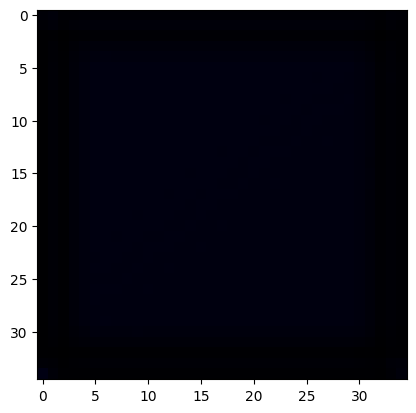

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 15.039339065551758, epoch:100/1000


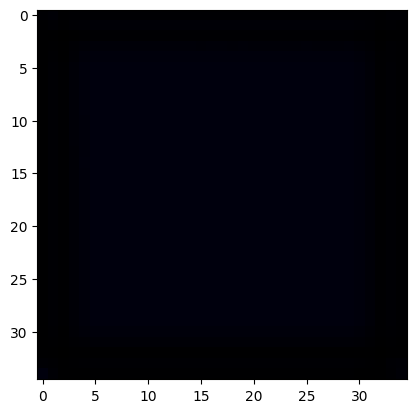

100%|██████████| 300/300 [00:53<00:00,  5.56it/s]


loss: 15.005542755126953, epoch:101/1000


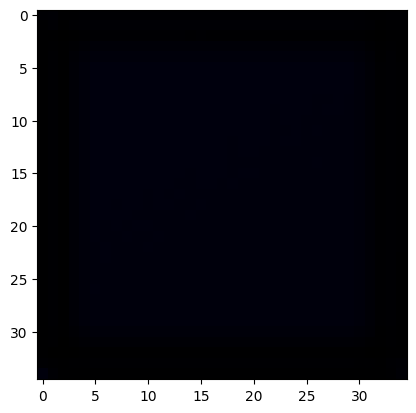

100%|██████████| 300/300 [00:53<00:00,  5.56it/s]


loss: 14.99190616607666, epoch:102/1000


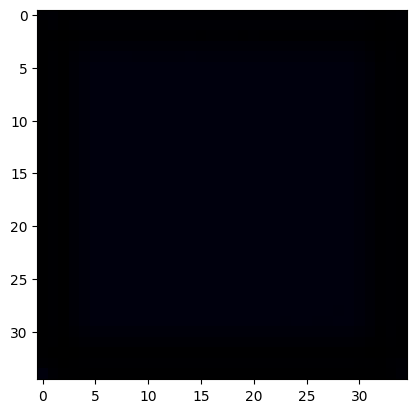

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.986019134521484, epoch:103/1000


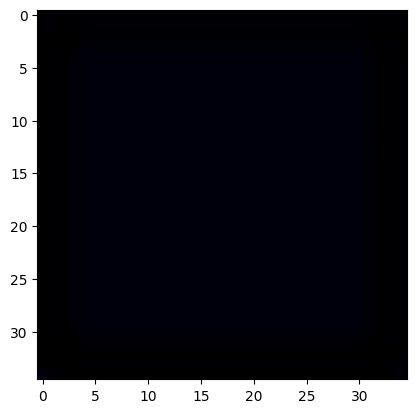

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.982943534851074, epoch:104/1000


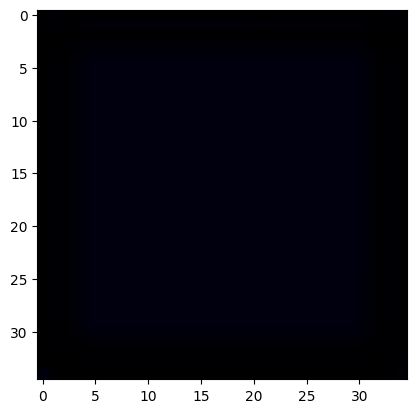

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 14.980804443359375, epoch:105/1000


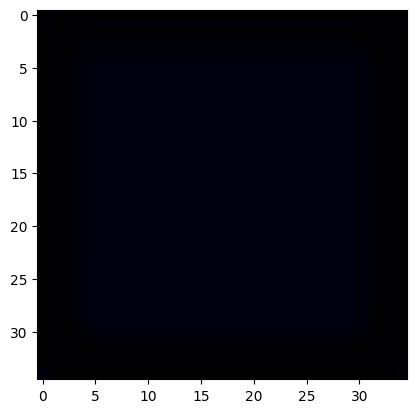

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 14.979254722595215, epoch:106/1000


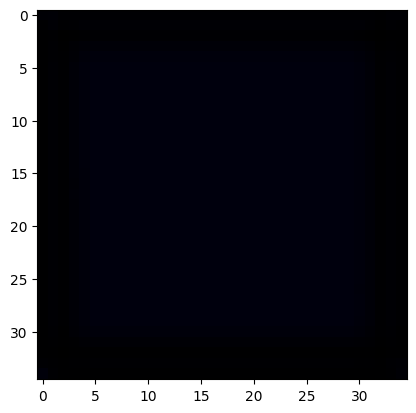

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.97805404663086, epoch:107/1000


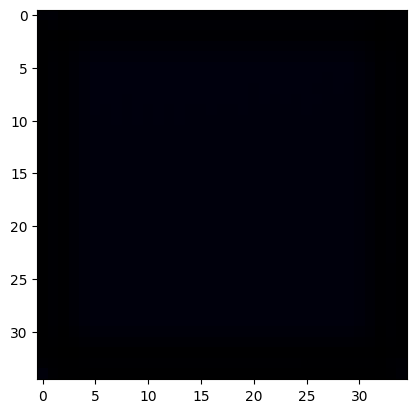

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.976983070373535, epoch:108/1000


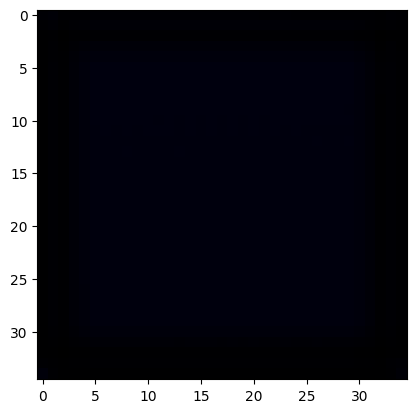

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 14.976033210754395, epoch:109/1000


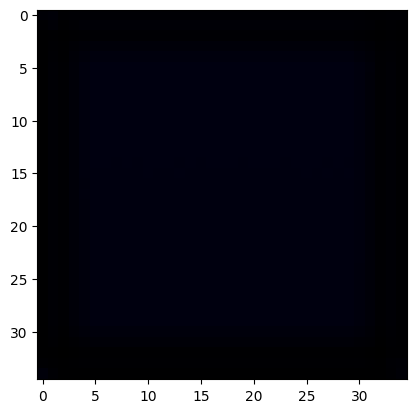

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 14.975220680236816, epoch:110/1000


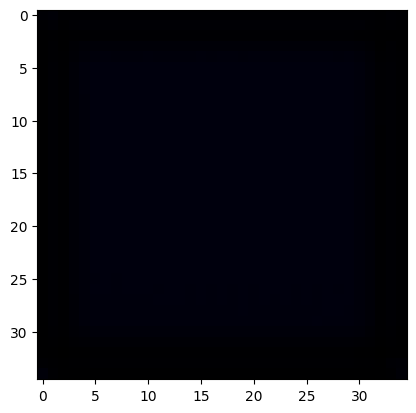

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.974434852600098, epoch:111/1000


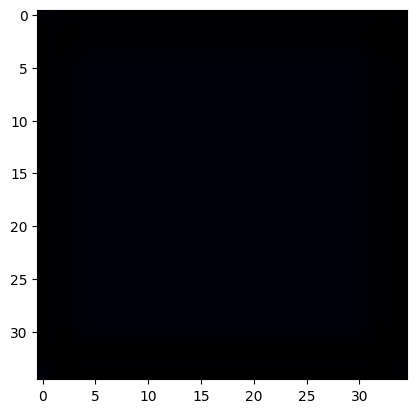

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 14.973687171936035, epoch:112/1000


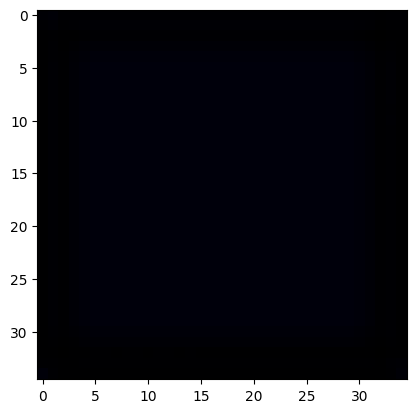

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.9730863571167, epoch:113/1000


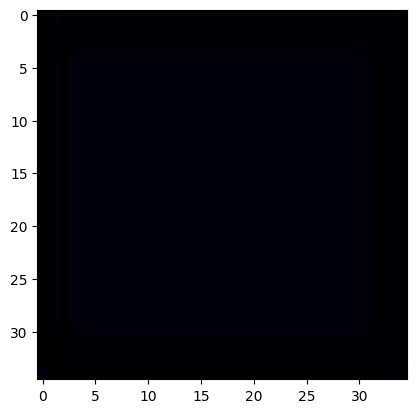

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 14.97246265411377, epoch:114/1000


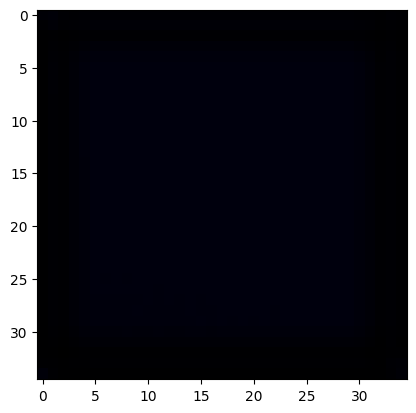

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 14.971854209899902, epoch:115/1000


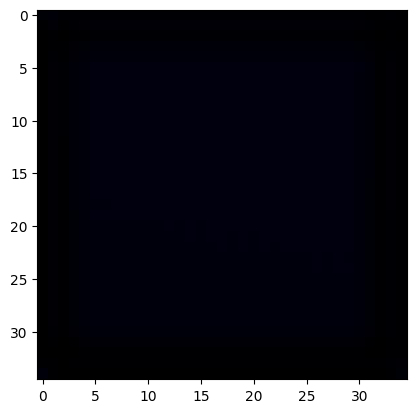

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 14.971234321594238, epoch:116/1000


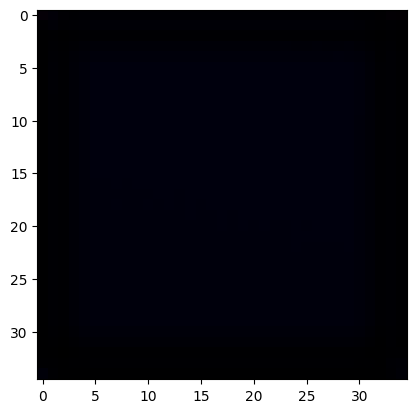

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 14.969890594482422, epoch:117/1000


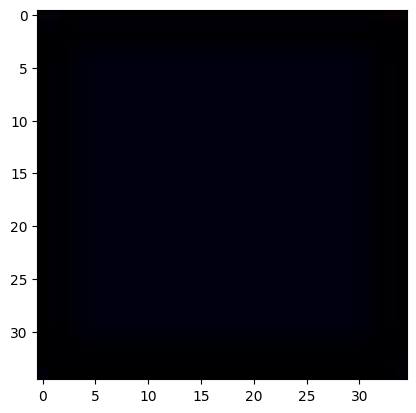

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 14.884203910827637, epoch:118/1000


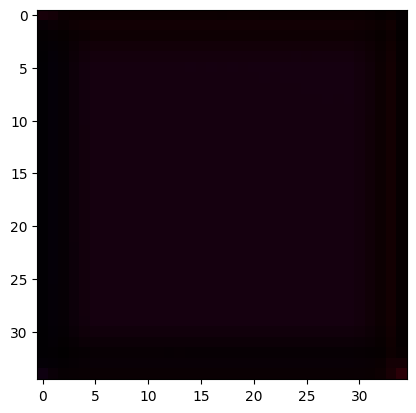

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.256421089172363, epoch:119/1000


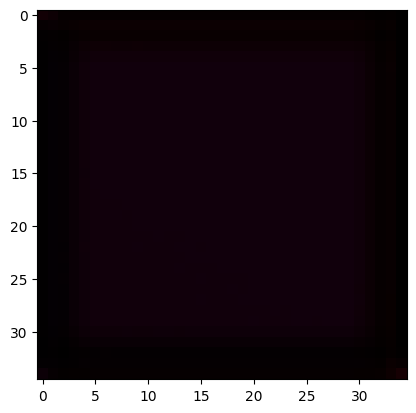

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 14.129104614257812, epoch:120/1000


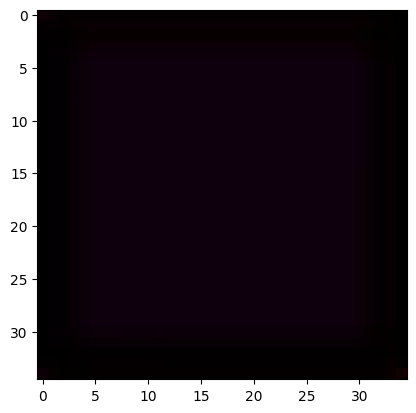

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 14.115468978881836, epoch:121/1000


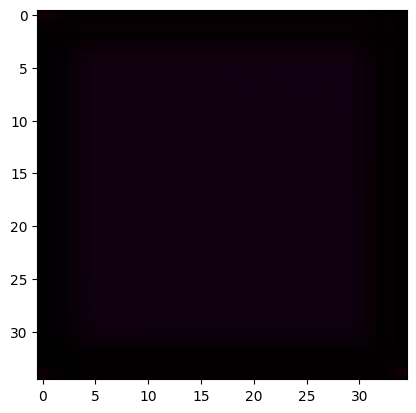

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 14.08796501159668, epoch:122/1000


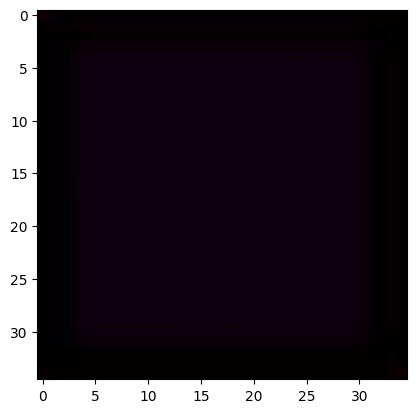

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.077591896057129, epoch:123/1000


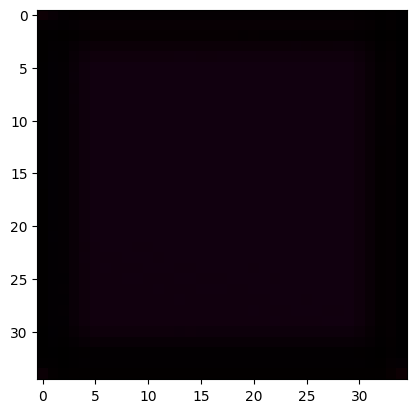

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.071965217590332, epoch:124/1000


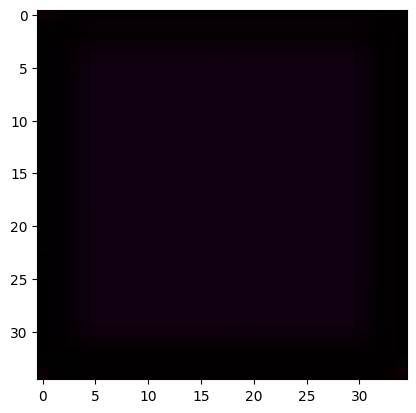

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 14.067046165466309, epoch:125/1000


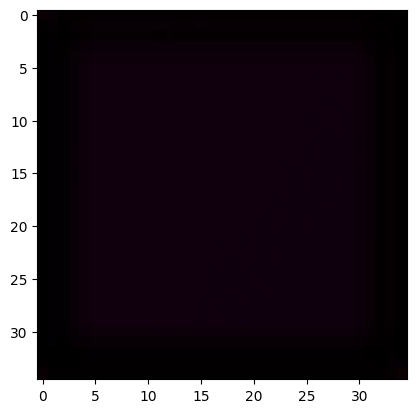

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 14.06313419342041, epoch:126/1000


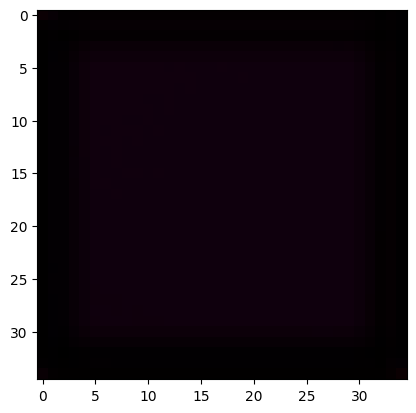

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 14.060064315795898, epoch:127/1000


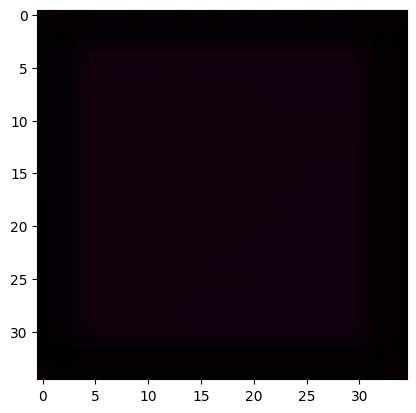

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 14.056585311889648, epoch:128/1000


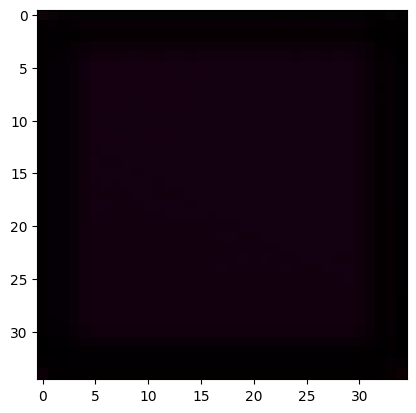

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 14.053455352783203, epoch:129/1000


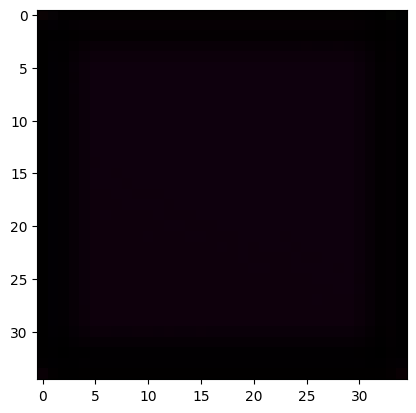

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 14.051100730895996, epoch:130/1000


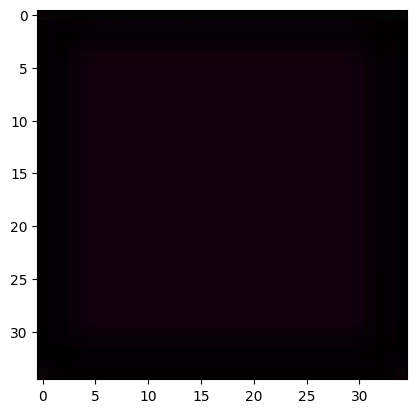

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.541118621826172, epoch:131/1000


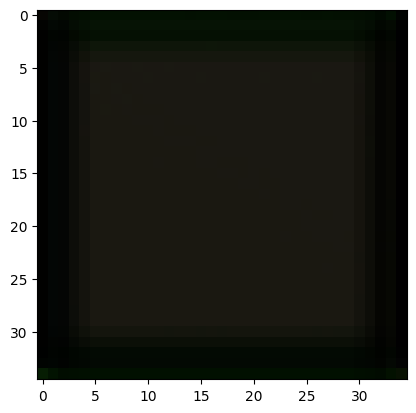

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.449112892150879, epoch:132/1000


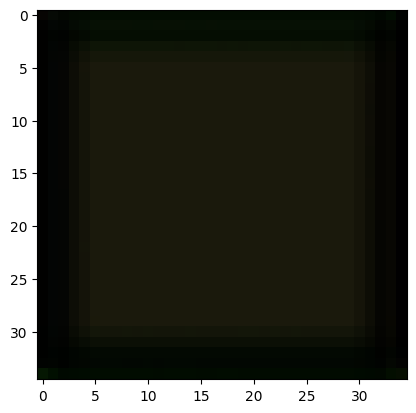

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.436711311340332, epoch:133/1000


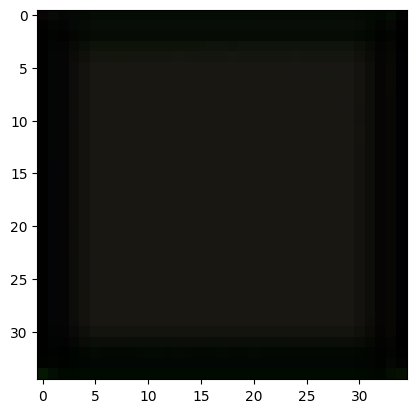

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.429733276367188, epoch:134/1000


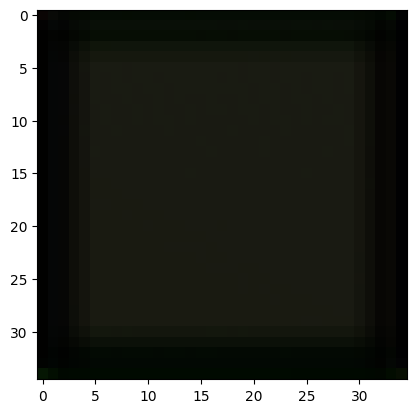

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.425370216369629, epoch:135/1000


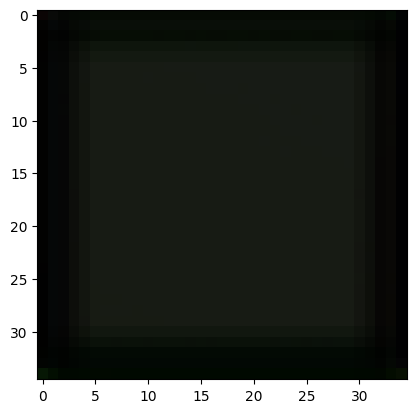

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.420446395874023, epoch:136/1000


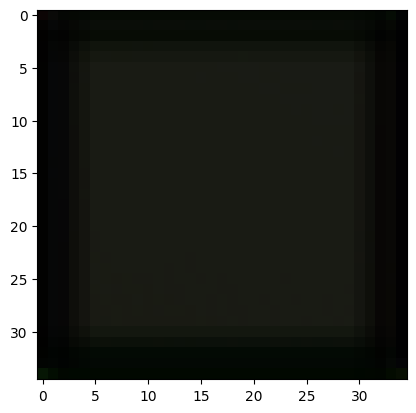

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.41672420501709, epoch:137/1000


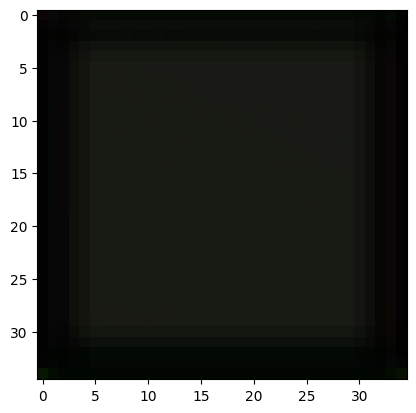

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]

loss: 13.413558006286621, epoch:138/1000


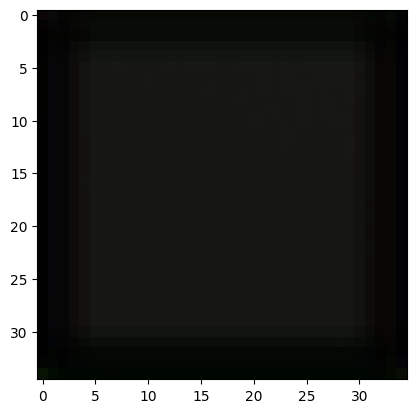

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.409296035766602, epoch:139/1000


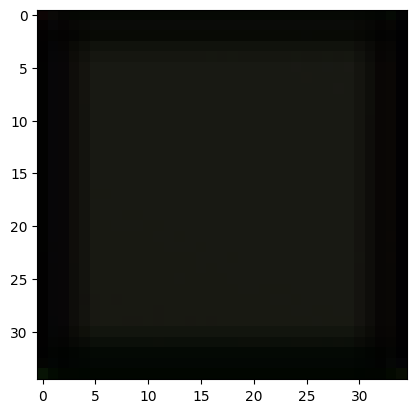

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.404930114746094, epoch:140/1000


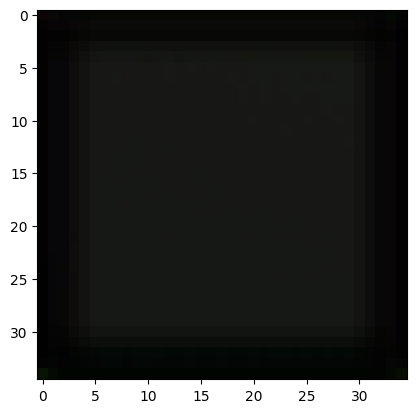

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.401372909545898, epoch:141/1000


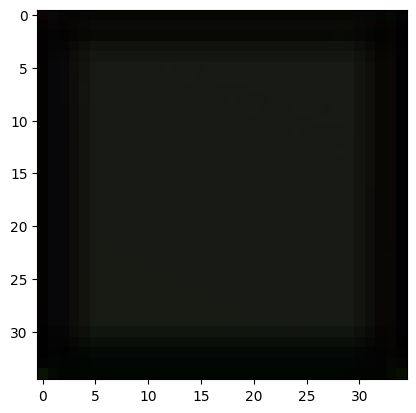

100%|██████████| 300/300 [00:55<00:00,  5.37it/s]


loss: 13.398493766784668, epoch:142/1000


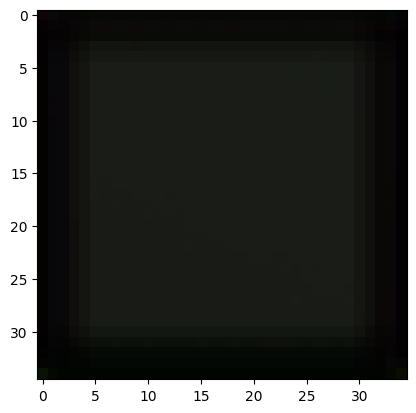

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.394543647766113, epoch:143/1000


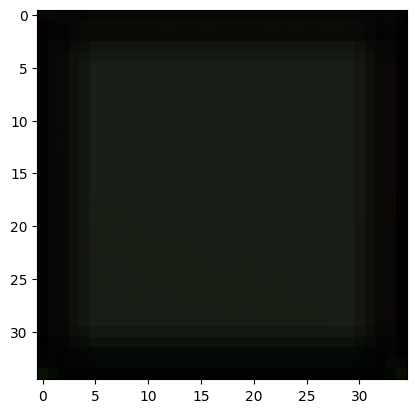

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.390137672424316, epoch:144/1000


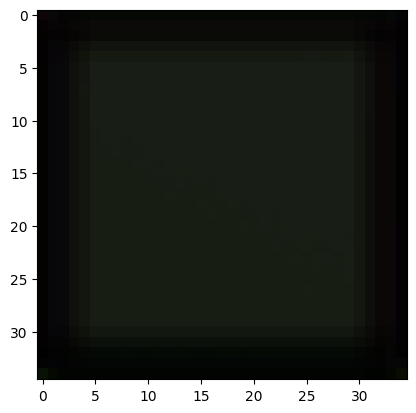

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.385189056396484, epoch:145/1000


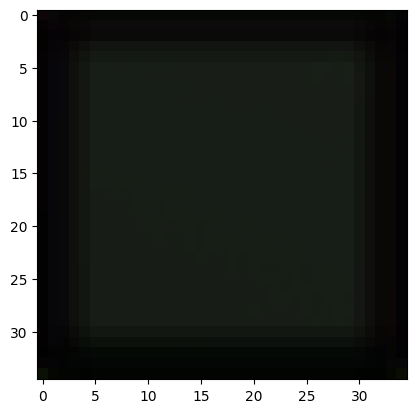

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.379895210266113, epoch:146/1000


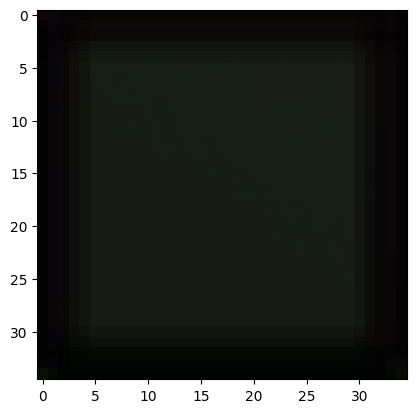

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.37442398071289, epoch:147/1000


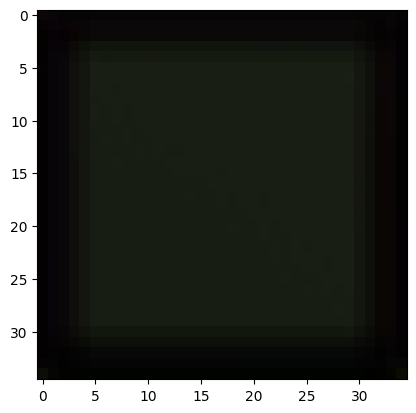

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.366181373596191, epoch:148/1000


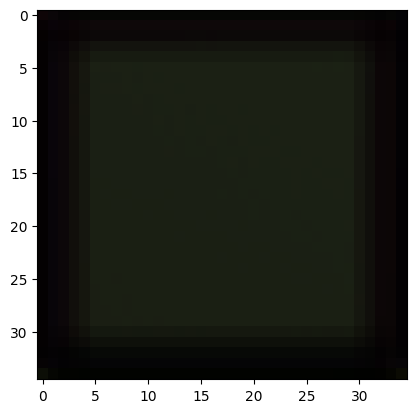

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.352783203125, epoch:149/1000


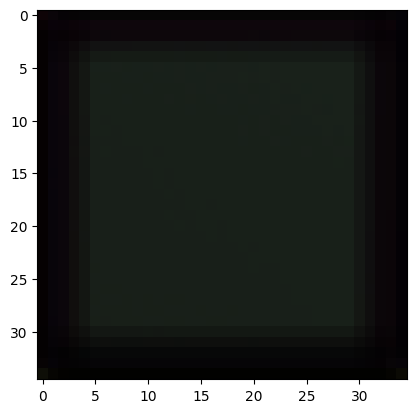

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.336790084838867, epoch:150/1000


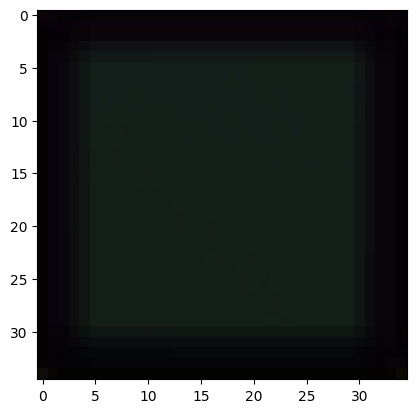

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 13.30297565460205, epoch:151/1000


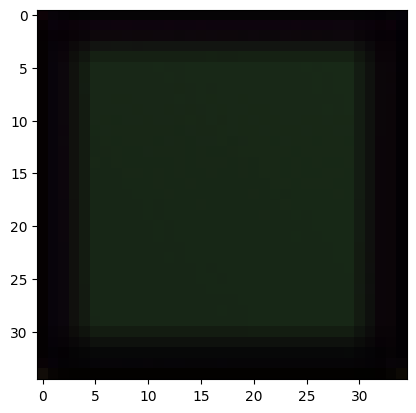

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 13.241325378417969, epoch:152/1000


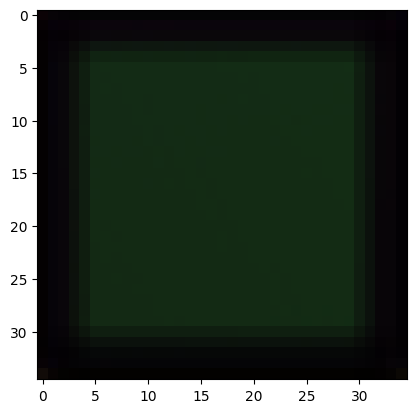

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.195630073547363, epoch:153/1000


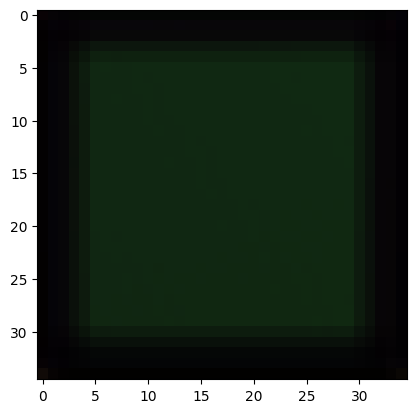

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.167470932006836, epoch:154/1000


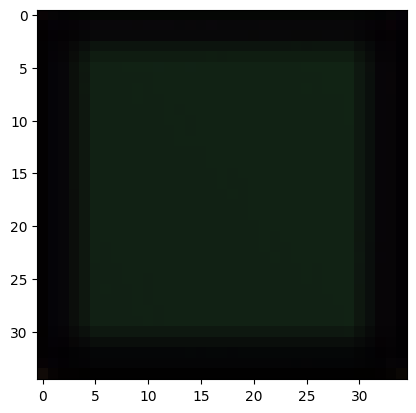

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 13.149282455444336, epoch:155/1000


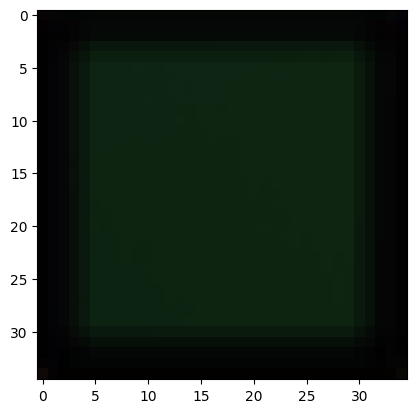

100%|██████████| 300/300 [00:53<00:00,  5.57it/s]


loss: 13.15788459777832, epoch:156/1000


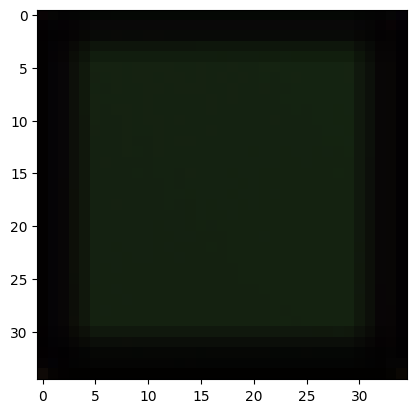

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.15147590637207, epoch:157/1000


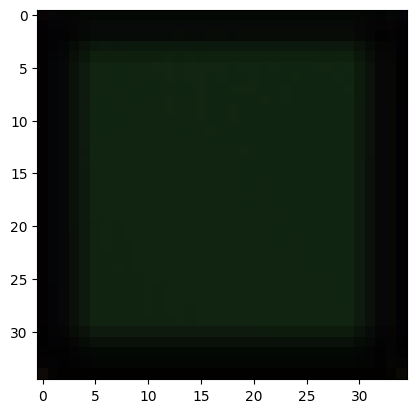

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.133289337158203, epoch:158/1000


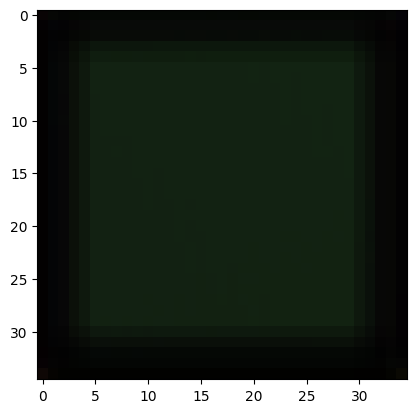

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.126198768615723, epoch:159/1000


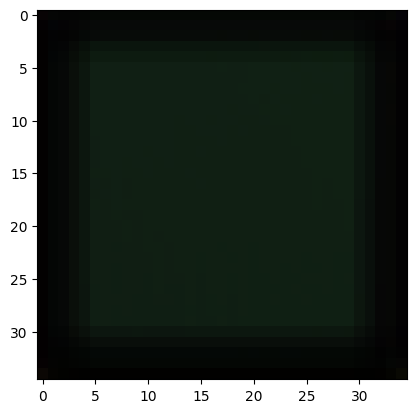

100%|██████████| 300/300 [00:53<00:00,  5.56it/s]


loss: 13.121088981628418, epoch:160/1000


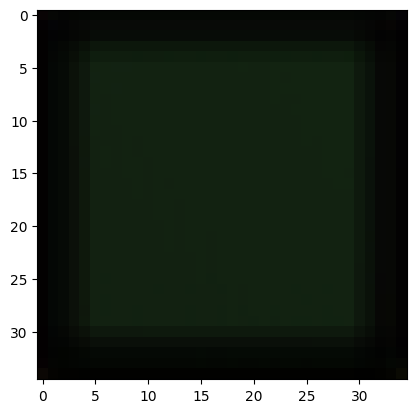

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.117105484008789, epoch:161/1000


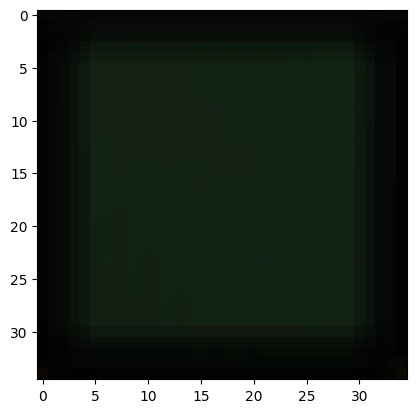

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.113718032836914, epoch:162/1000


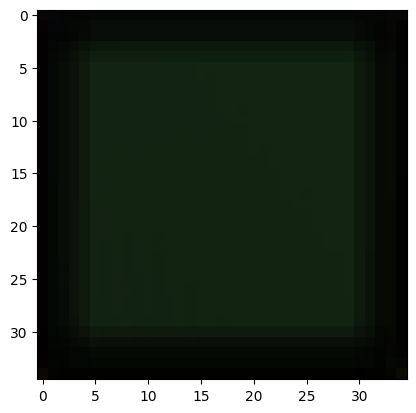

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.111111640930176, epoch:163/1000


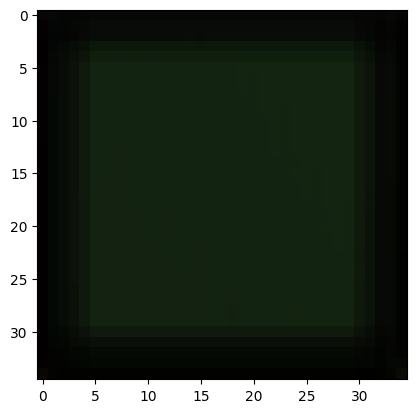

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.10822582244873, epoch:164/1000


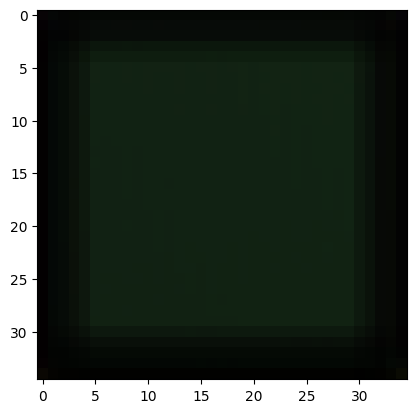

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.105704307556152, epoch:165/1000


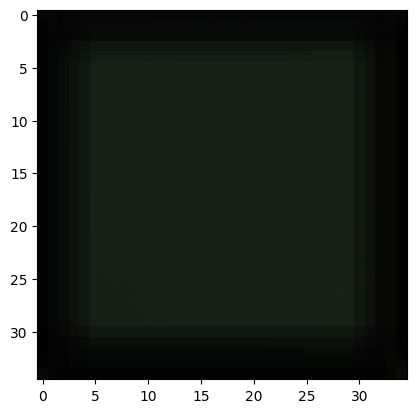

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.103334426879883, epoch:166/1000


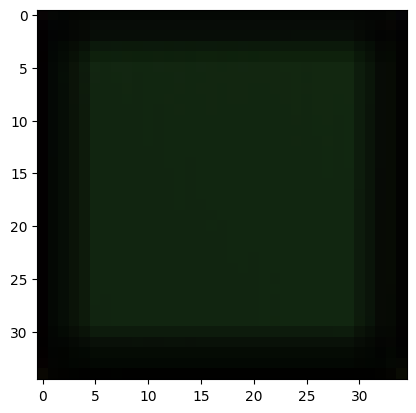

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.101344108581543, epoch:167/1000


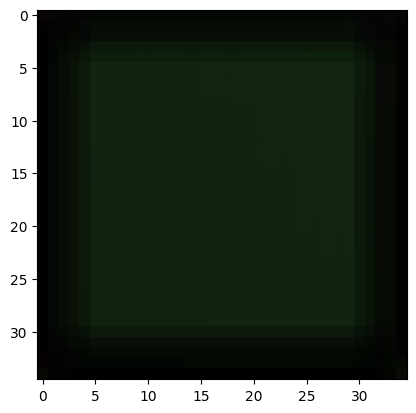

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.099405288696289, epoch:168/1000


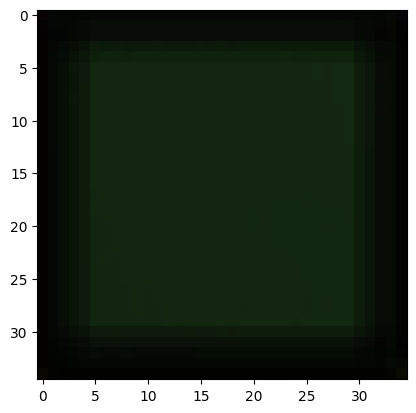

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.097272872924805, epoch:169/1000


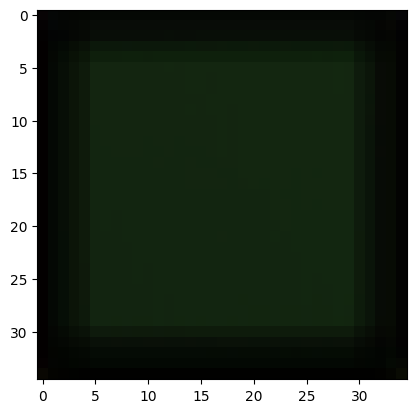

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.096029281616211, epoch:170/1000


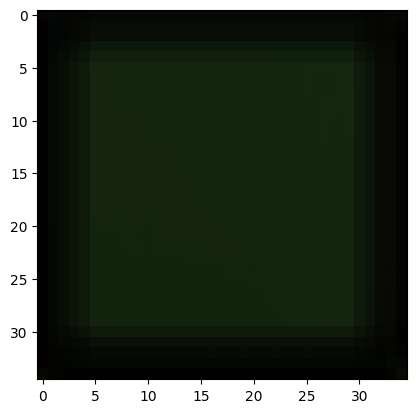

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.094038963317871, epoch:171/1000


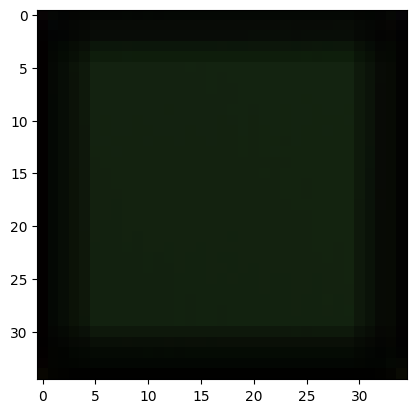

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.092642784118652, epoch:172/1000


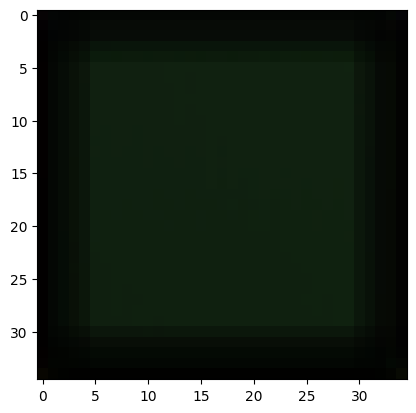

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.091054916381836, epoch:173/1000


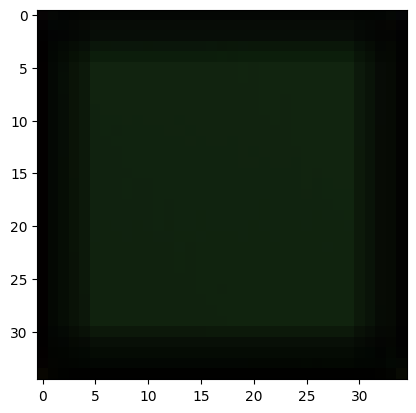

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.089850425720215, epoch:174/1000


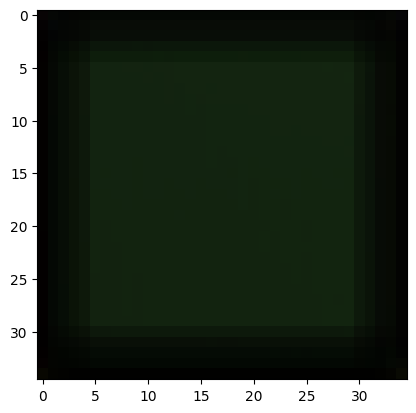

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.088443756103516, epoch:175/1000


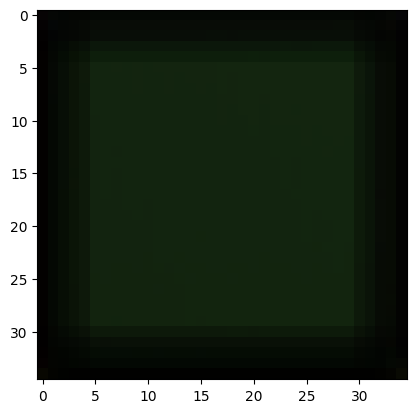

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.087532043457031, epoch:176/1000


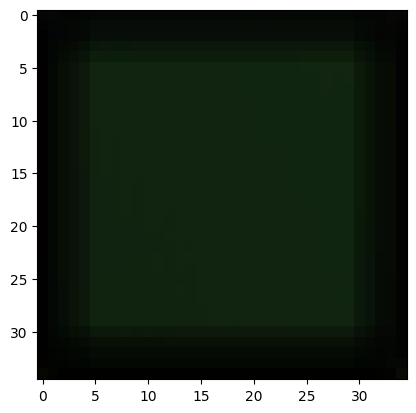

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.085990905761719, epoch:177/1000


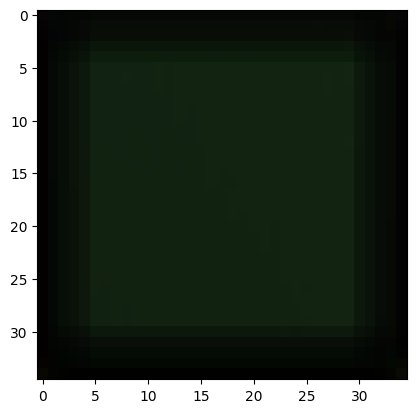

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.084908485412598, epoch:178/1000


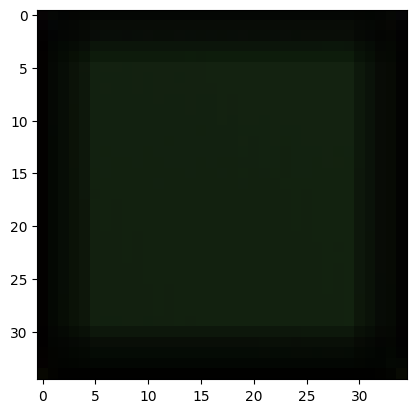

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.084202766418457, epoch:179/1000


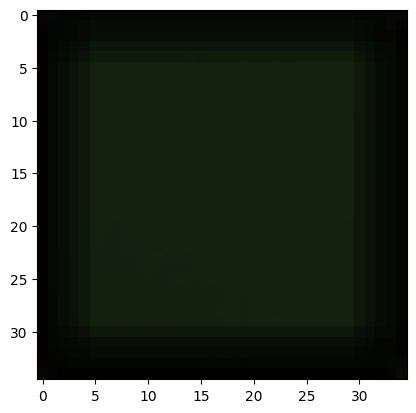

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.082999229431152, epoch:180/1000


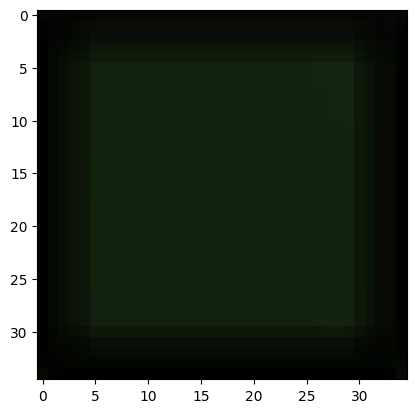

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 13.081981658935547, epoch:181/1000


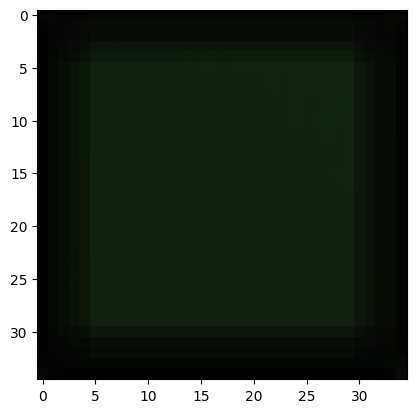

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.081660270690918, epoch:182/1000


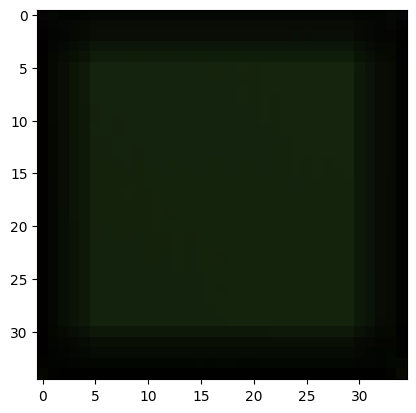

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.08047866821289, epoch:183/1000


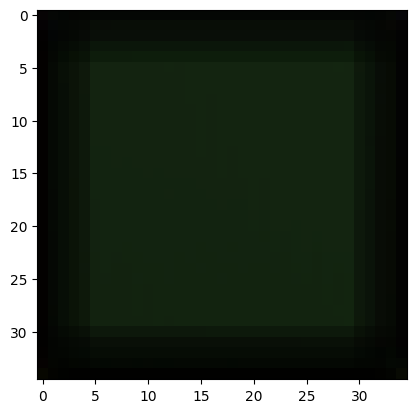

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.079586029052734, epoch:184/1000


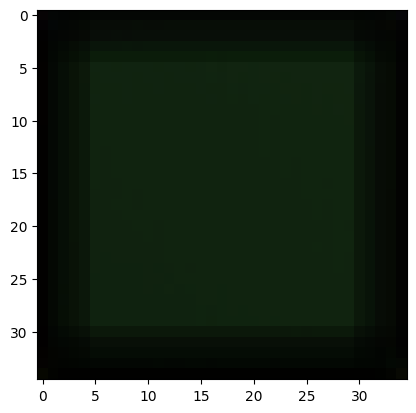

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.078829765319824, epoch:185/1000


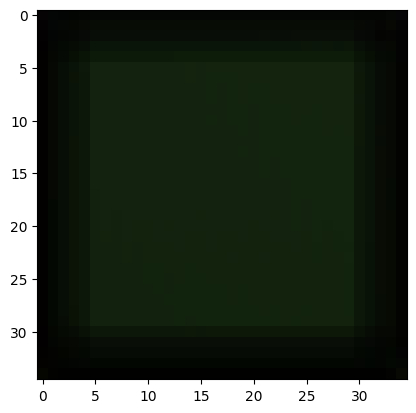

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.078283309936523, epoch:186/1000


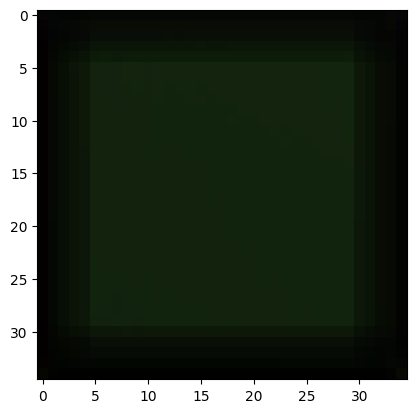

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.077644348144531, epoch:187/1000


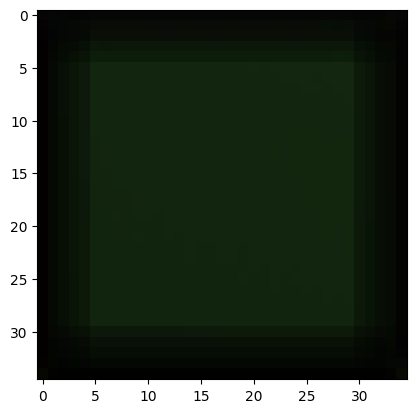

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.077016830444336, epoch:188/1000


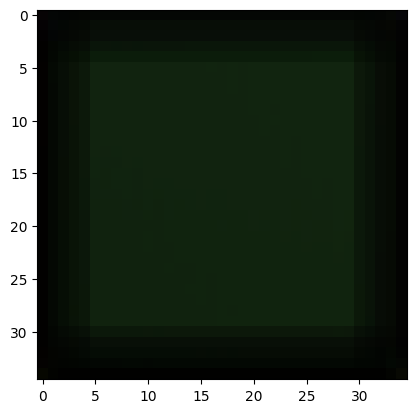

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.07628345489502, epoch:189/1000


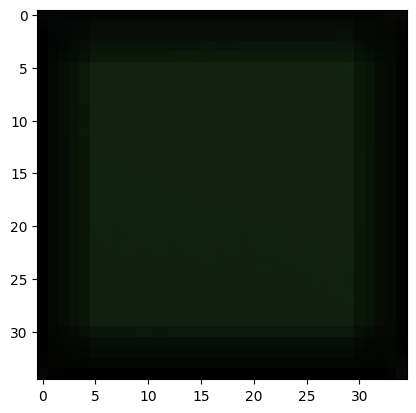

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.075730323791504, epoch:190/1000


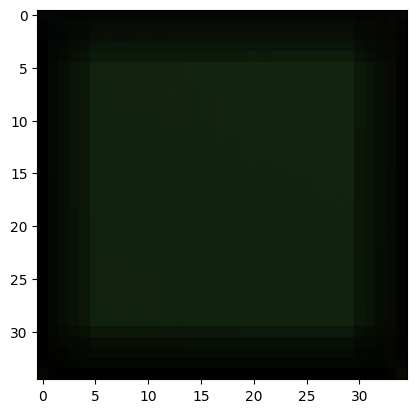

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.074984550476074, epoch:191/1000


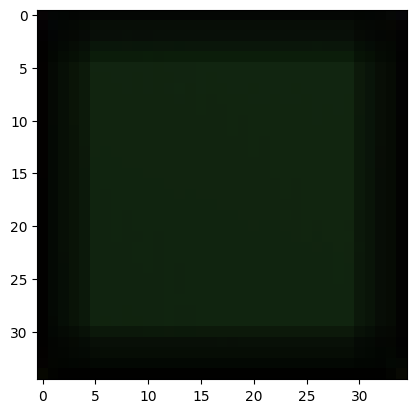

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.074797630310059, epoch:192/1000


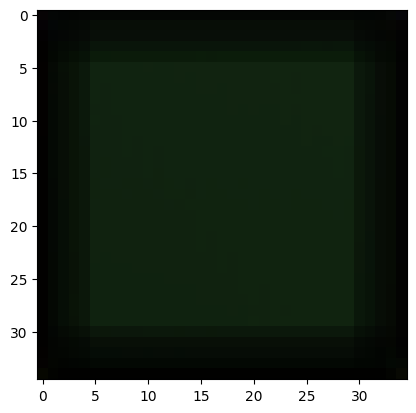

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.074065208435059, epoch:193/1000


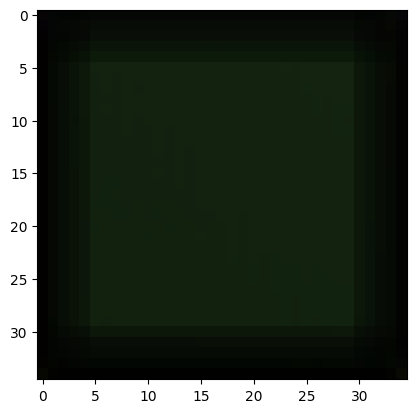

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.073579788208008, epoch:194/1000


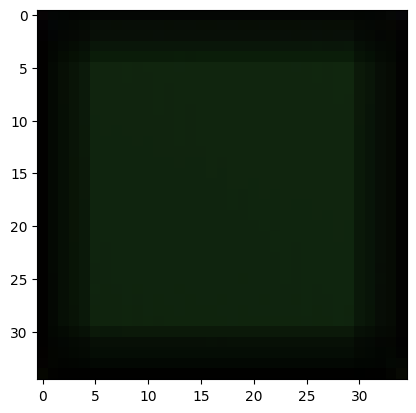

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 13.073241233825684, epoch:195/1000


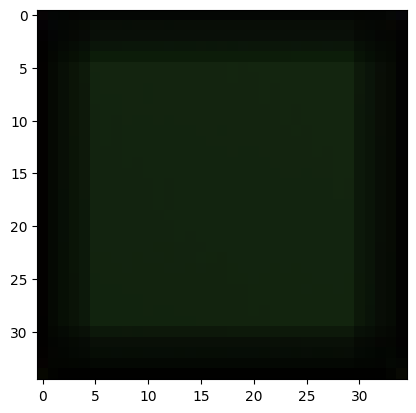

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.072663307189941, epoch:196/1000


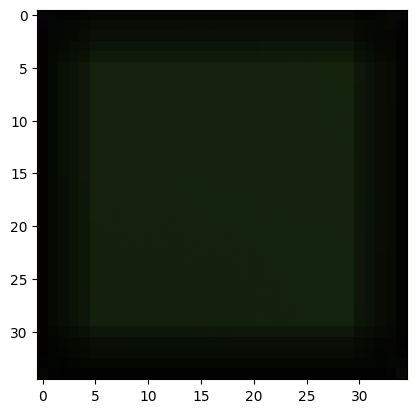

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.07224178314209, epoch:197/1000


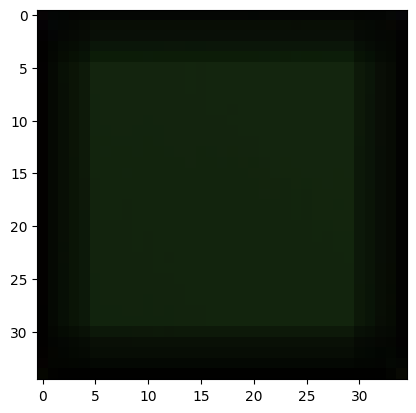

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.0717134475708, epoch:198/1000


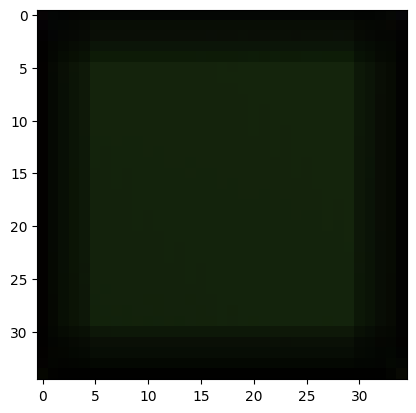

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.071283340454102, epoch:199/1000


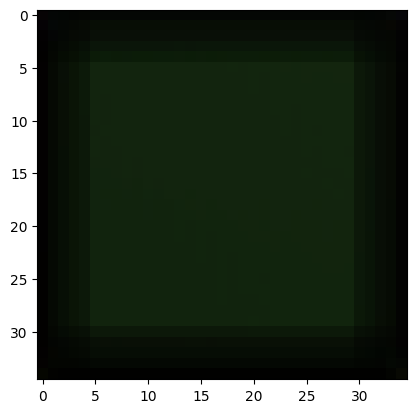

100%|██████████| 300/300 [00:54<00:00,  5.46it/s]


loss: 13.07087230682373, epoch:200/1000


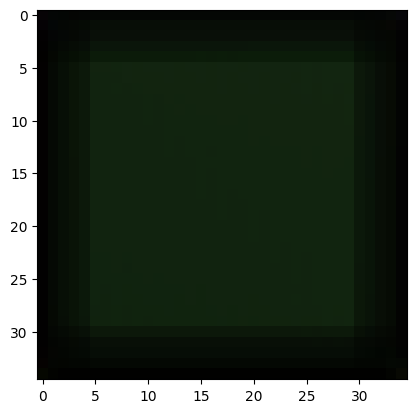

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.070420265197754, epoch:201/1000


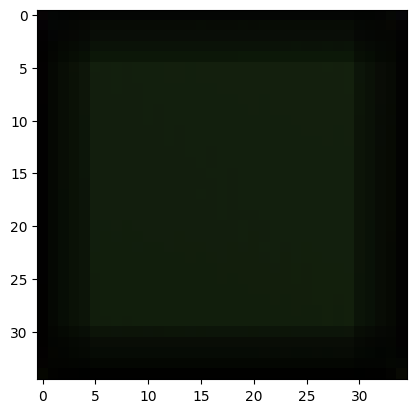

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.070146560668945, epoch:202/1000


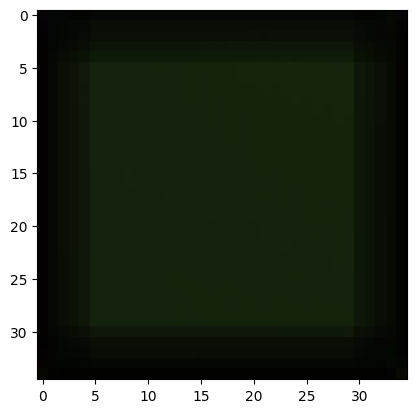

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.069576263427734, epoch:203/1000


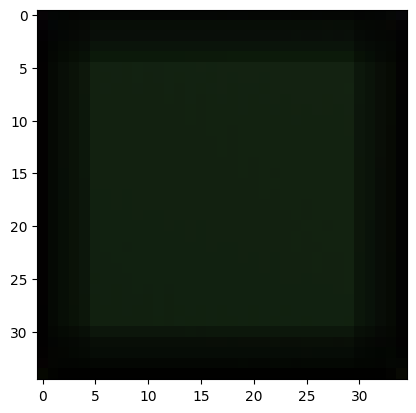

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 13.069347381591797, epoch:204/1000


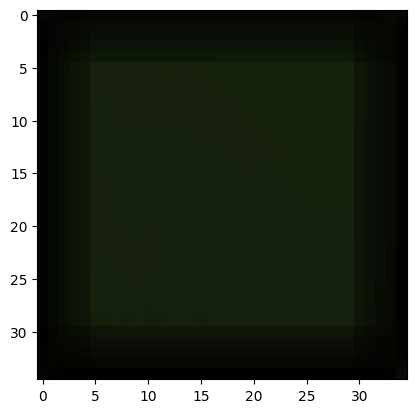

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.068829536437988, epoch:205/1000


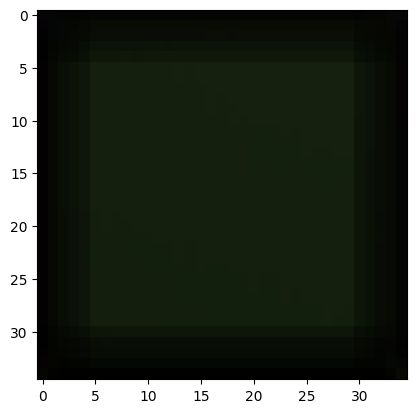

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.068781852722168, epoch:206/1000


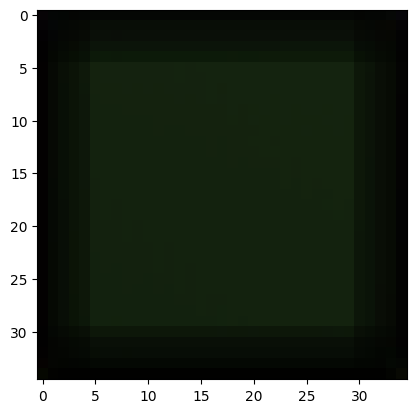

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.068229675292969, epoch:207/1000


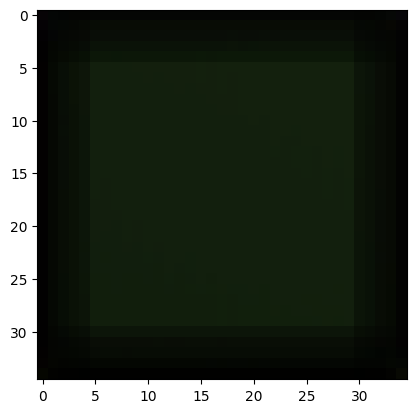

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.067877769470215, epoch:208/1000


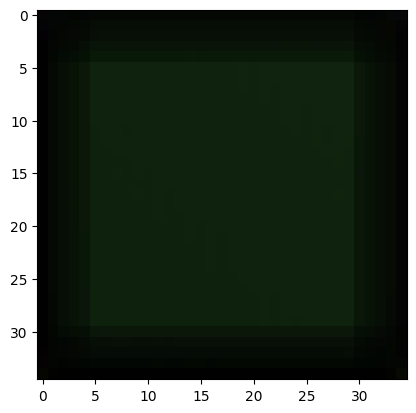

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.067657470703125, epoch:209/1000


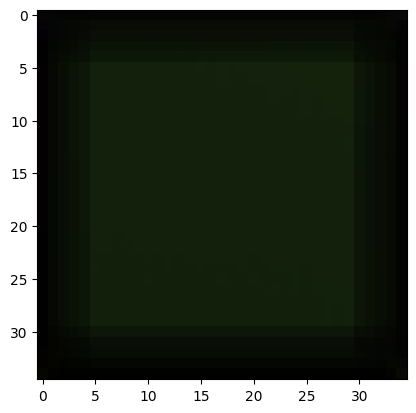

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.06725025177002, epoch:210/1000


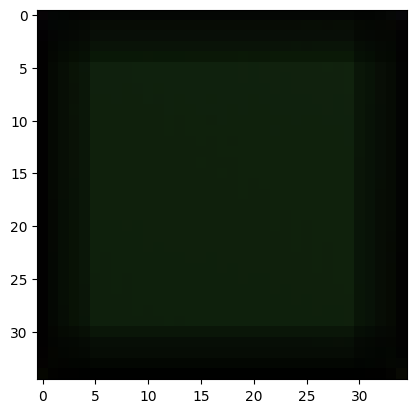

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.066910743713379, epoch:211/1000


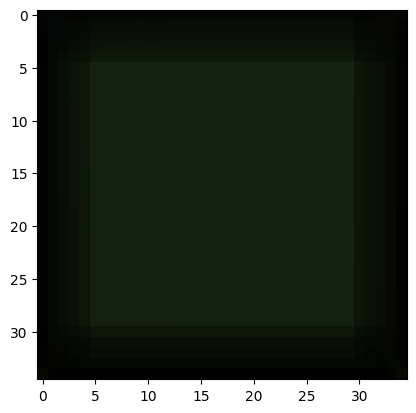

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.066676139831543, epoch:212/1000


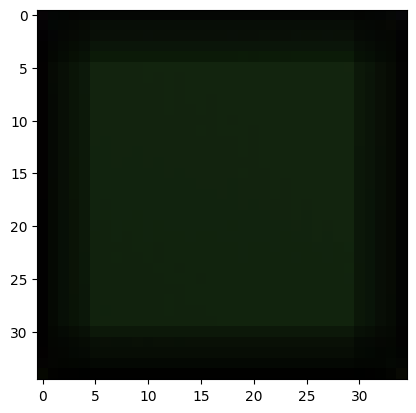

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.066206932067871, epoch:213/1000


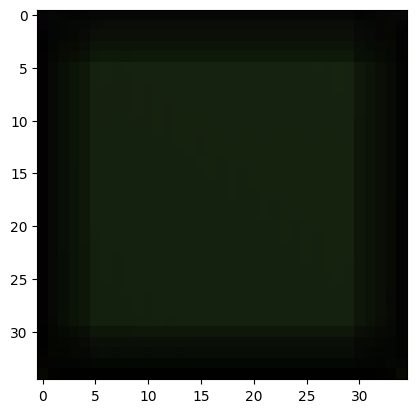

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.065814018249512, epoch:214/1000


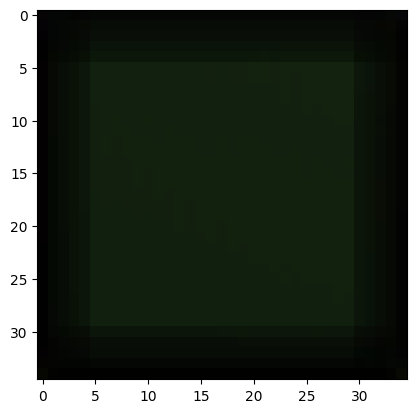

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.065540313720703, epoch:215/1000


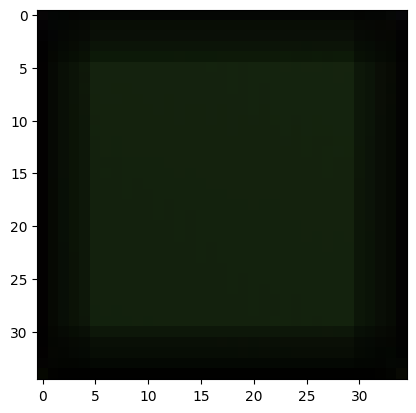

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.06545639038086, epoch:216/1000


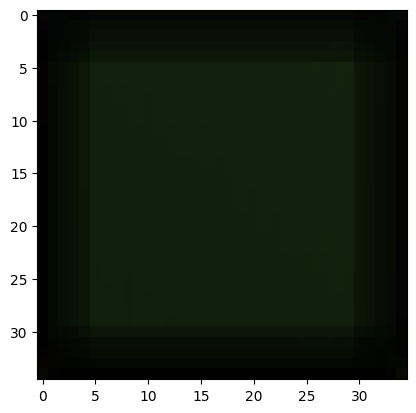

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.06491470336914, epoch:217/1000


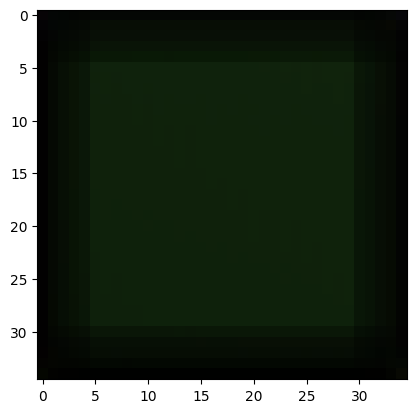

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.064375877380371, epoch:218/1000


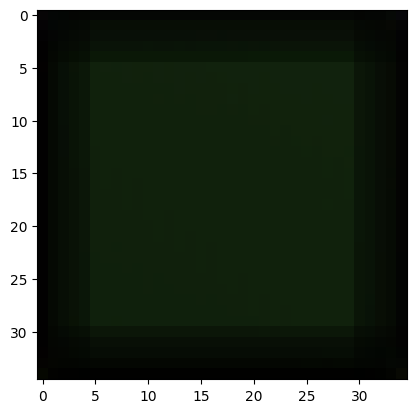

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.064208030700684, epoch:219/1000


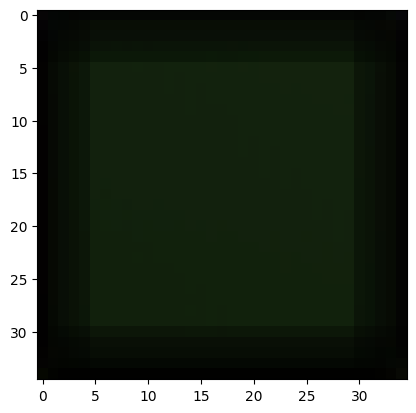

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.063794136047363, epoch:220/1000


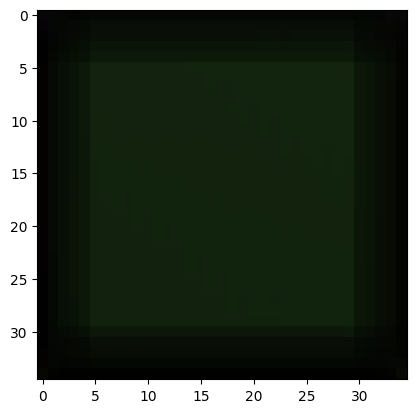

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.063302040100098, epoch:221/1000


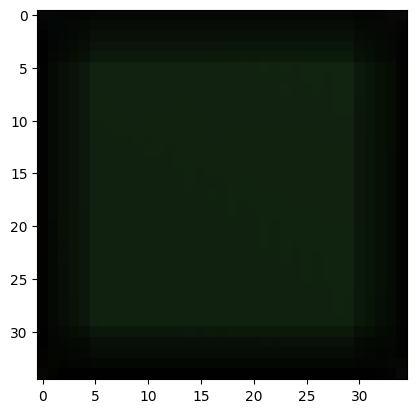

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.062808990478516, epoch:222/1000


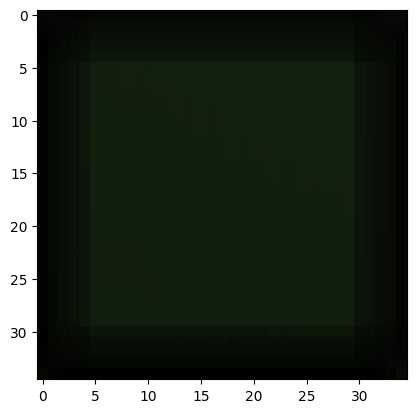

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.062407493591309, epoch:223/1000


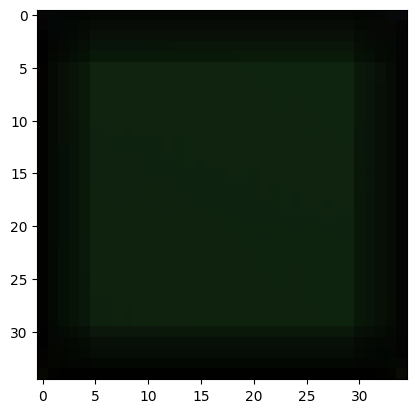

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.06187629699707, epoch:224/1000


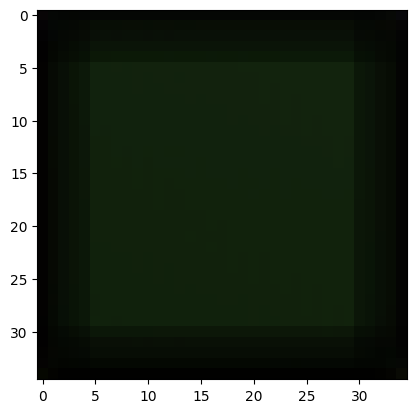

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.061284065246582, epoch:225/1000


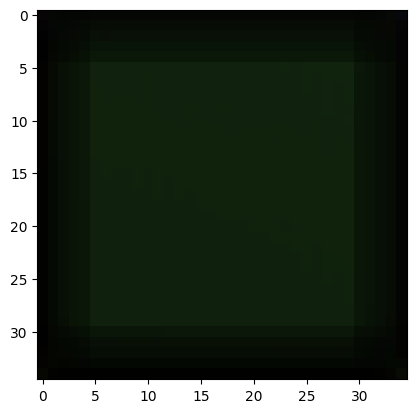

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.060798645019531, epoch:226/1000


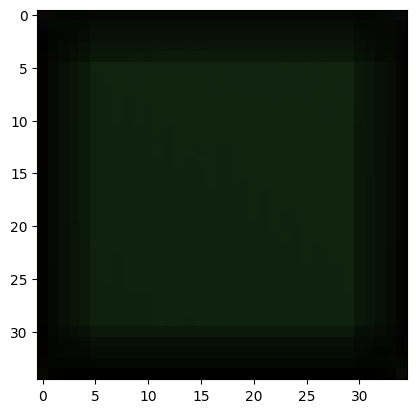

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.060062408447266, epoch:227/1000


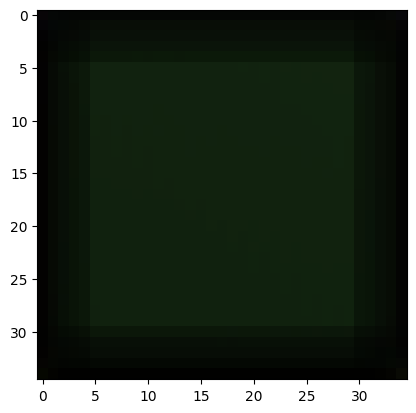

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.05921745300293, epoch:228/1000


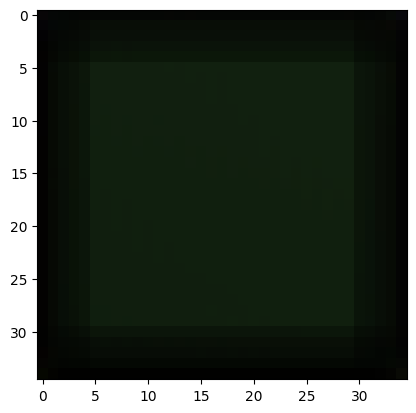

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.0582914352417, epoch:229/1000


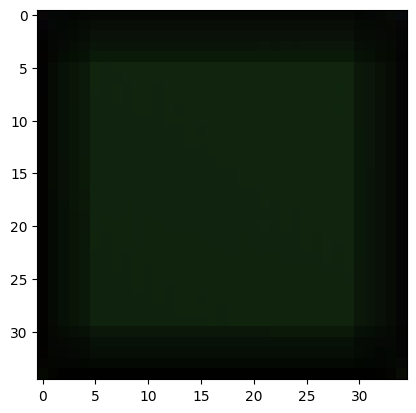

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 13.057313919067383, epoch:230/1000


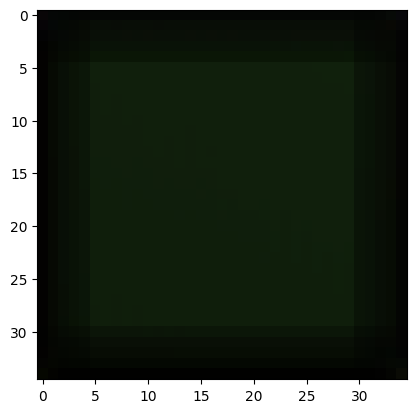

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 13.055896759033203, epoch:231/1000


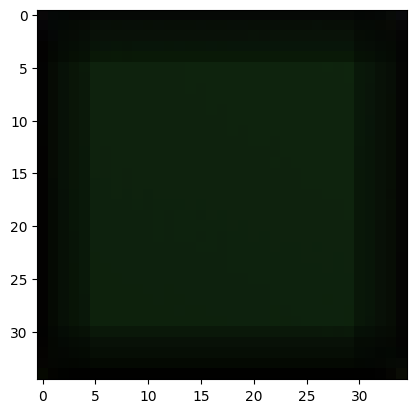

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.056292533874512, epoch:232/1000


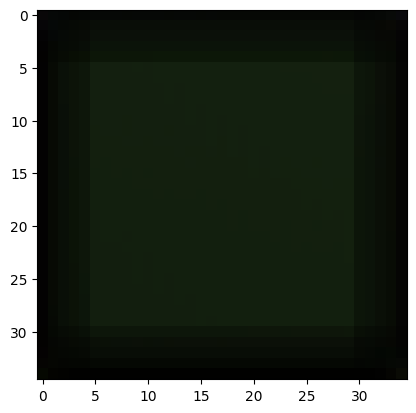

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.052189826965332, epoch:233/1000


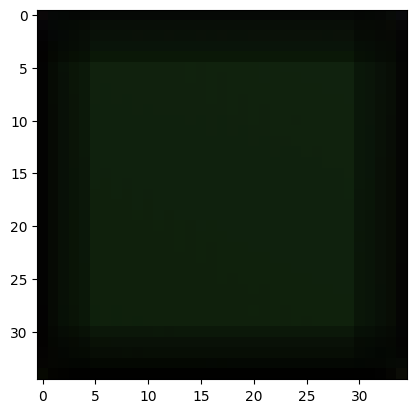

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 13.048873901367188, epoch:234/1000


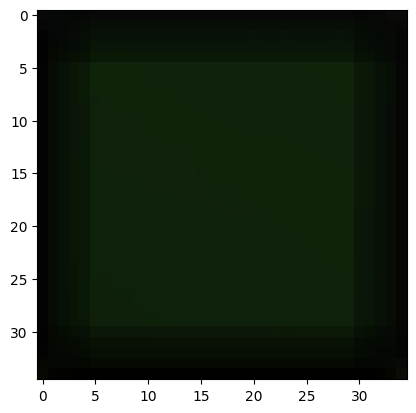

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.046711921691895, epoch:235/1000


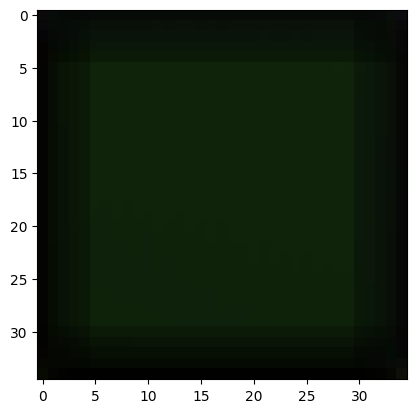

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.043034553527832, epoch:236/1000


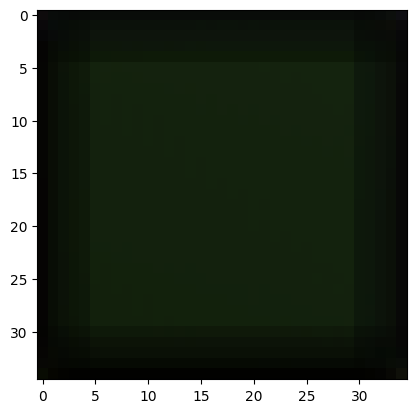

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 13.039246559143066, epoch:237/1000


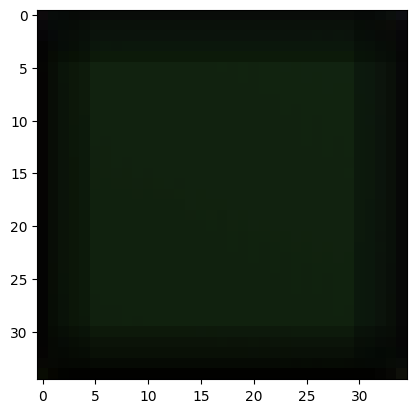

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.035404205322266, epoch:238/1000


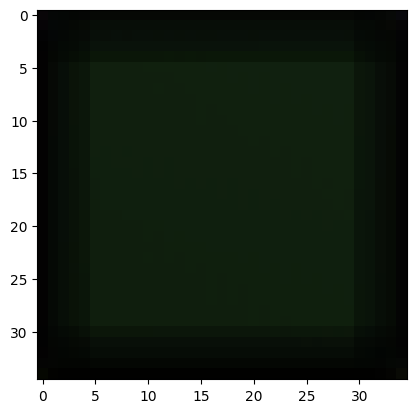

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.030865669250488, epoch:239/1000


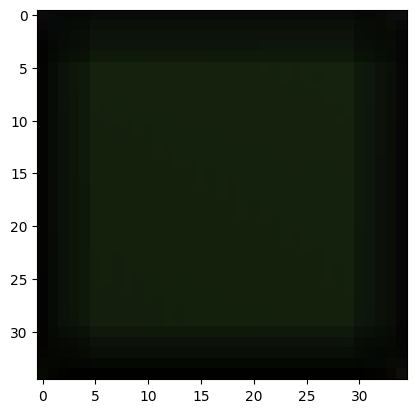

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 13.029621124267578, epoch:240/1000


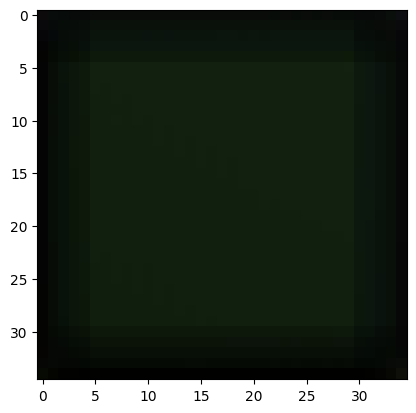

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 13.02319622039795, epoch:241/1000


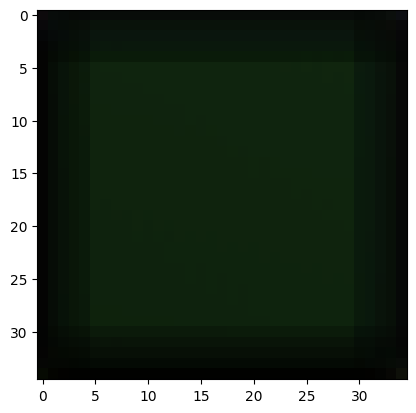

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 13.019383430480957, epoch:242/1000


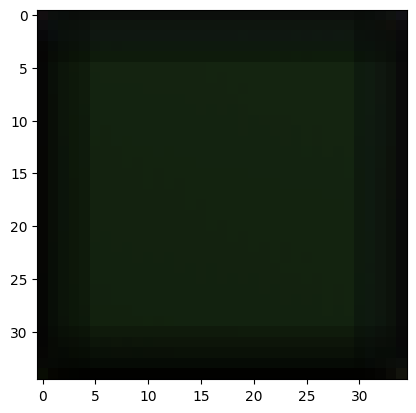

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 13.016254425048828, epoch:243/1000


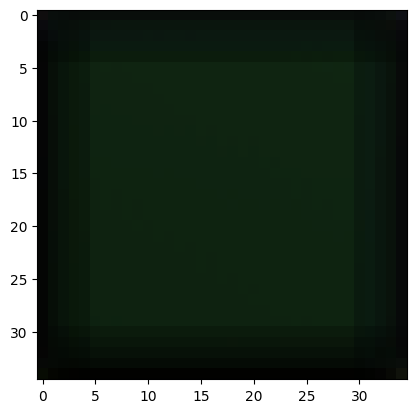

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.01404857635498, epoch:244/1000


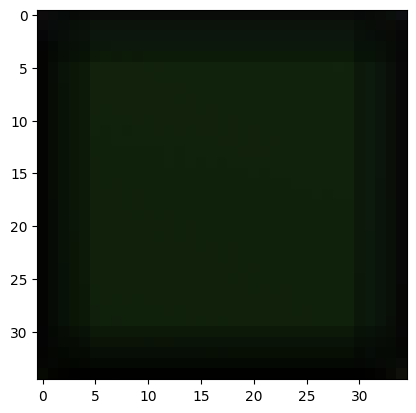

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 13.011383056640625, epoch:245/1000


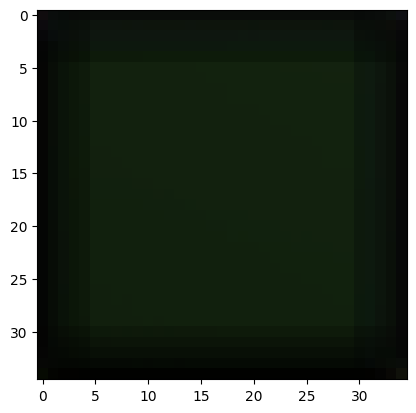

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.007351875305176, epoch:246/1000


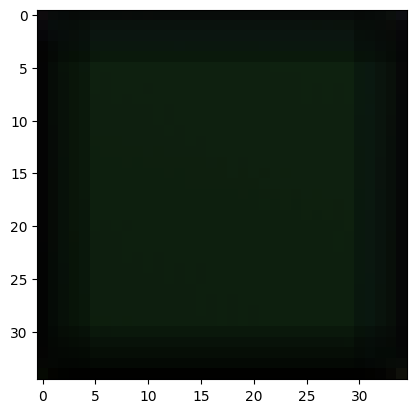

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.007421493530273, epoch:247/1000


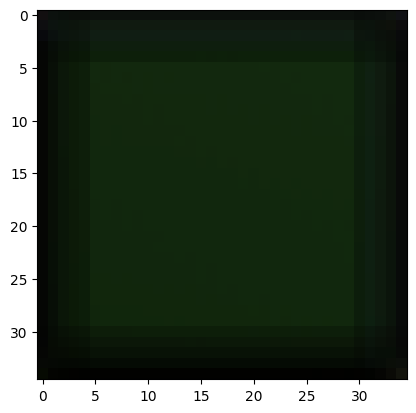

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 13.003924369812012, epoch:248/1000


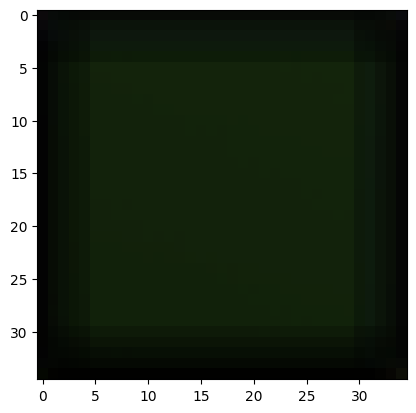

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.99850845336914, epoch:249/1000


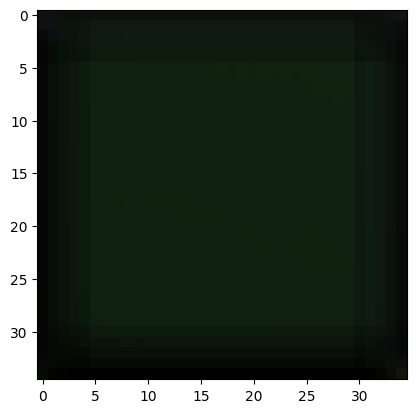

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.996318817138672, epoch:250/1000


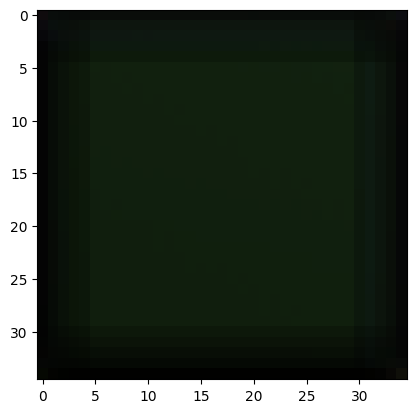

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.993013381958008, epoch:251/1000


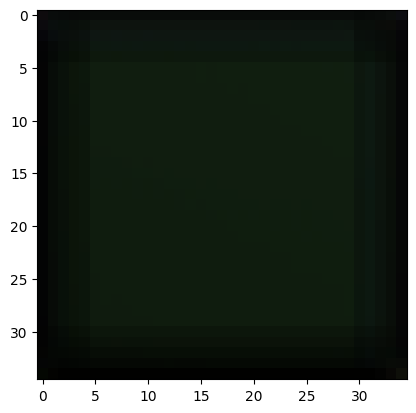

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.990025520324707, epoch:252/1000


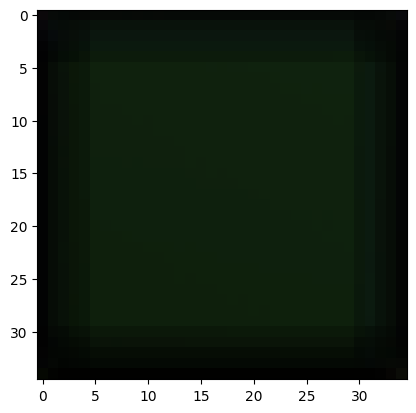

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.987319946289062, epoch:253/1000


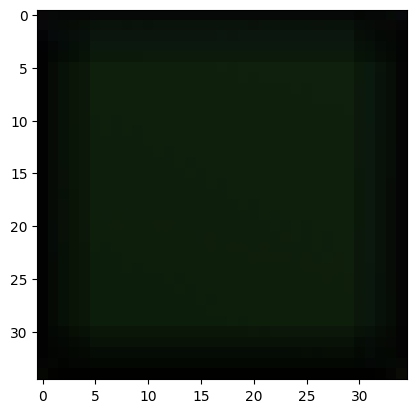

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.98311710357666, epoch:254/1000


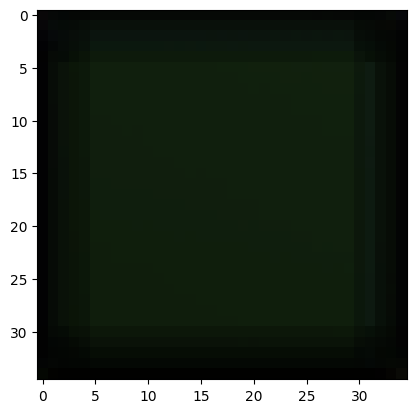

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.98026180267334, epoch:255/1000


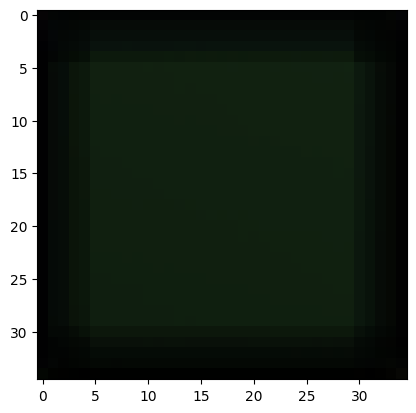

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.975992202758789, epoch:256/1000


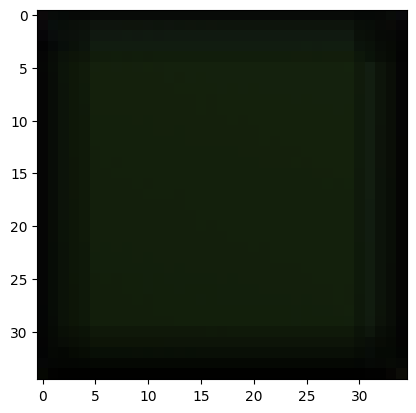

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]

loss: 12.972786903381348, epoch:257/1000


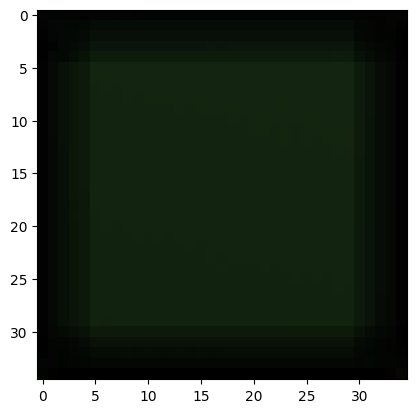

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]

loss: 12.973657608032227, epoch:258/1000


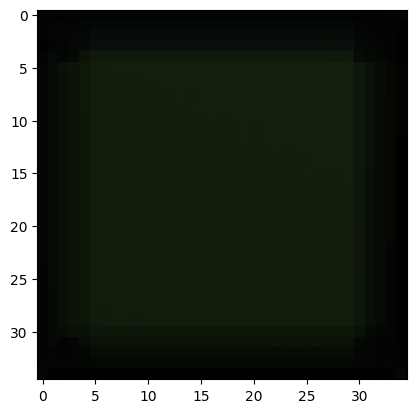

100%|██████████| 300/300 [00:55<00:00,  5.37it/s]


loss: 12.967787742614746, epoch:259/1000


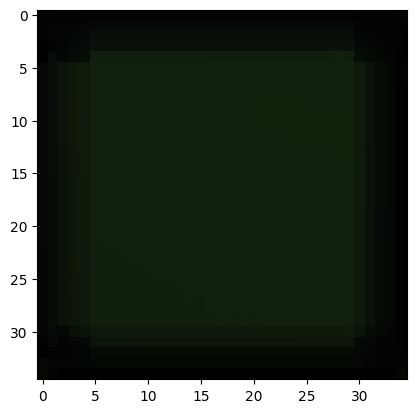

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.961199760437012, epoch:260/1000


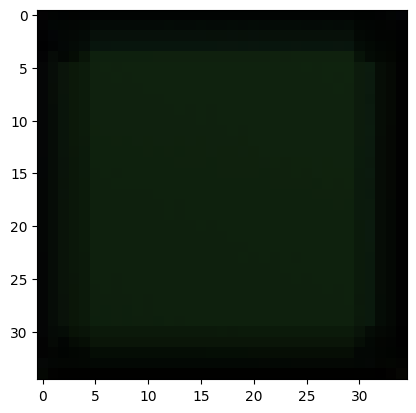

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.957437515258789, epoch:261/1000


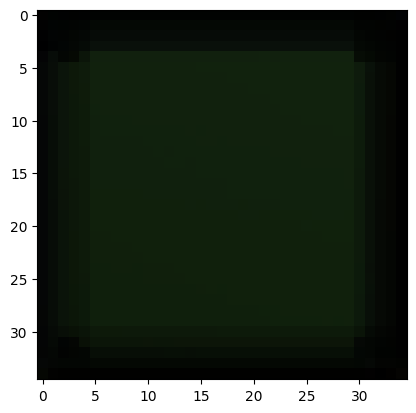

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.953241348266602, epoch:262/1000


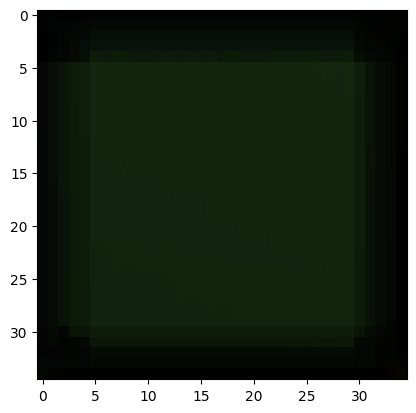

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.94885540008545, epoch:263/1000


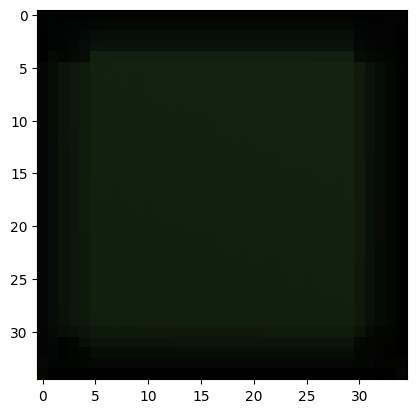

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.946537971496582, epoch:264/1000


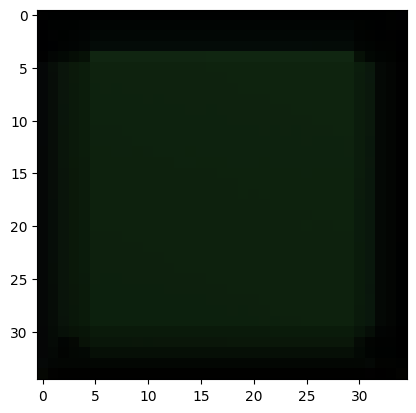

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.94167423248291, epoch:265/1000


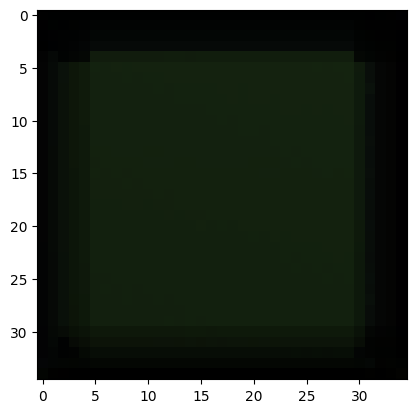

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.938679695129395, epoch:266/1000


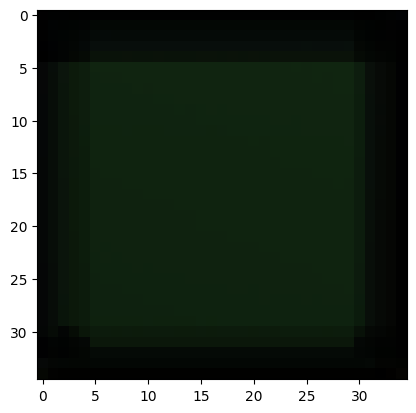

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.935441970825195, epoch:267/1000


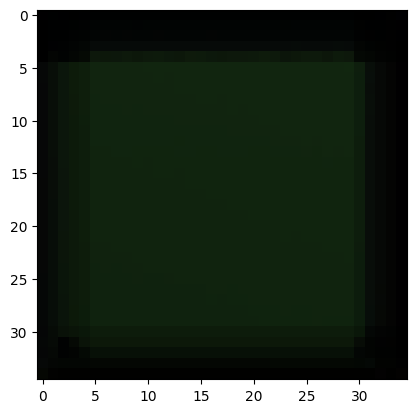

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.932047843933105, epoch:268/1000


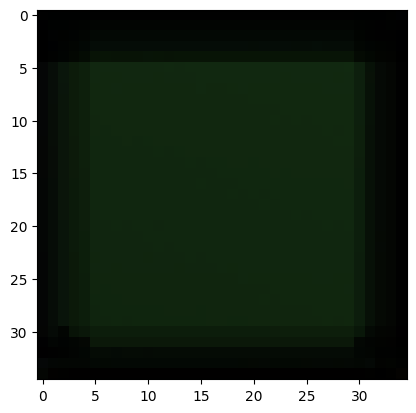

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.926922798156738, epoch:269/1000


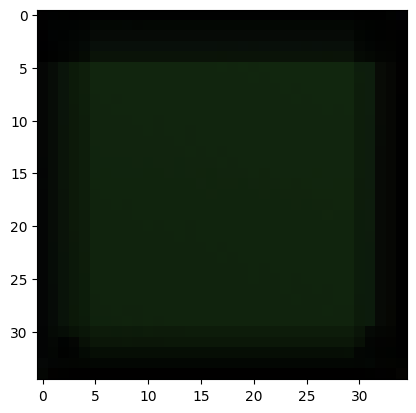

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.92264175415039, epoch:270/1000


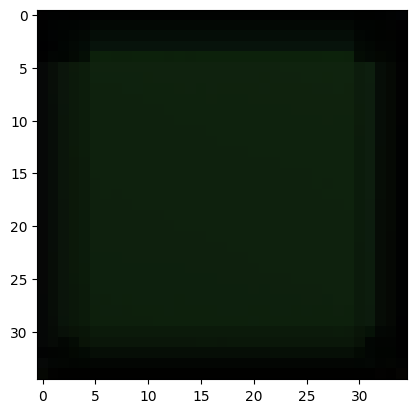

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.919997215270996, epoch:271/1000


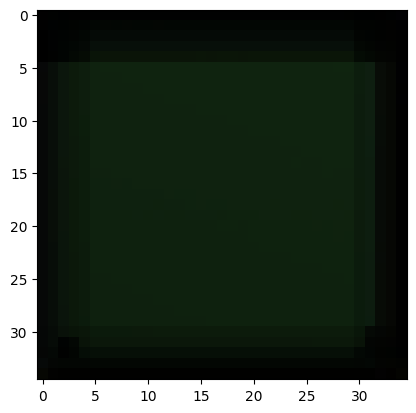

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.915156364440918, epoch:272/1000


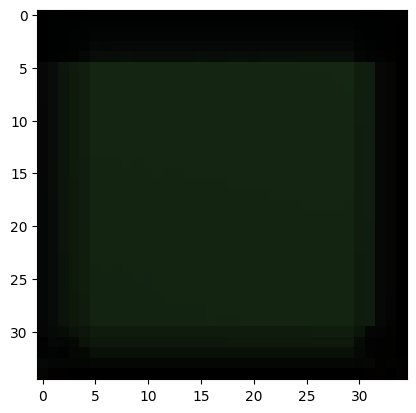

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.9170503616333, epoch:273/1000


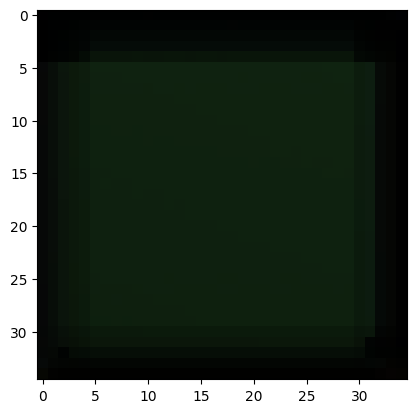

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.906206130981445, epoch:274/1000


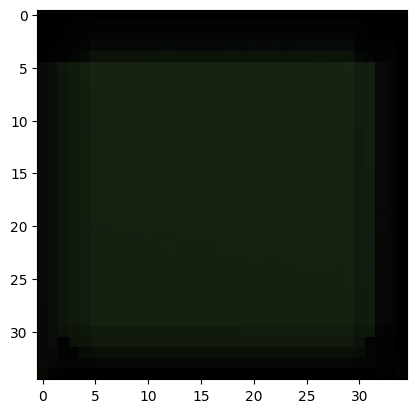

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.90517807006836, epoch:275/1000


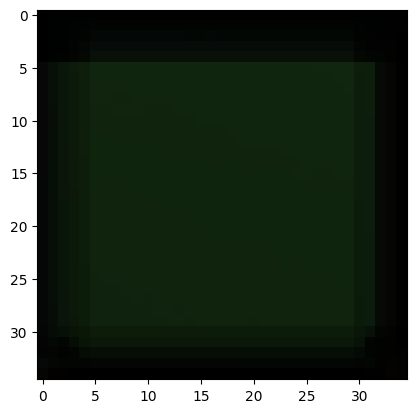

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.901108741760254, epoch:276/1000


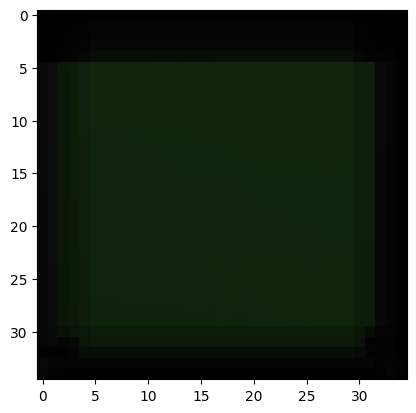

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.896793365478516, epoch:277/1000


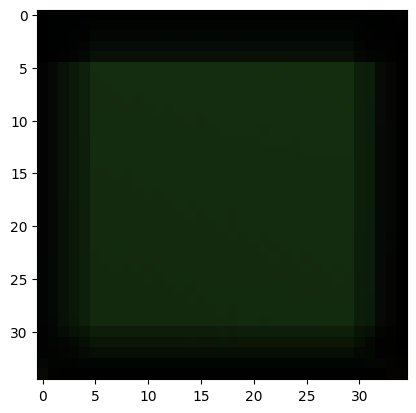

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.895401954650879, epoch:278/1000


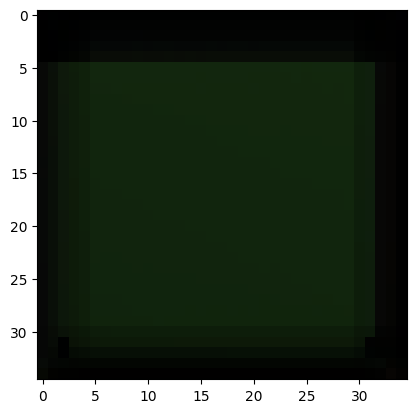

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.893631935119629, epoch:279/1000


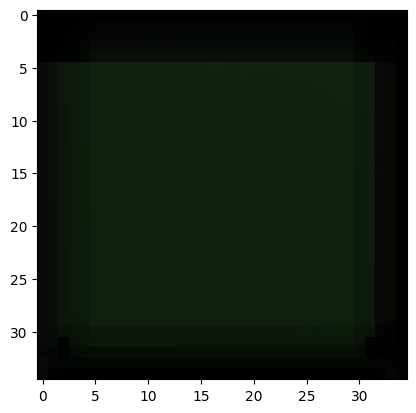

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.883378982543945, epoch:280/1000


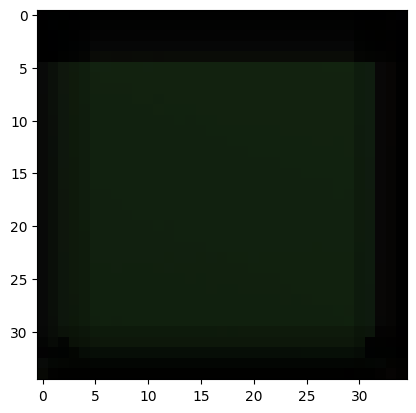

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.883685111999512, epoch:281/1000


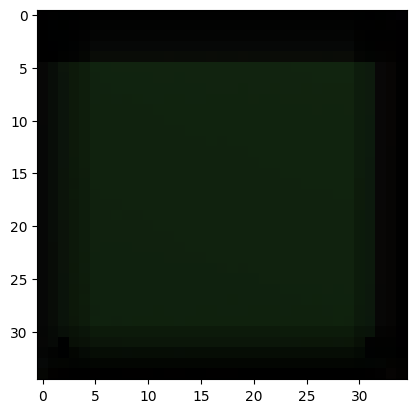

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.876513481140137, epoch:282/1000


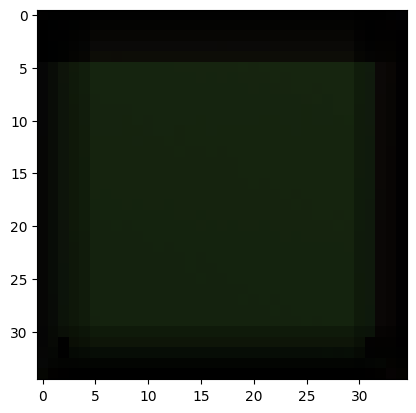

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.86992073059082, epoch:283/1000


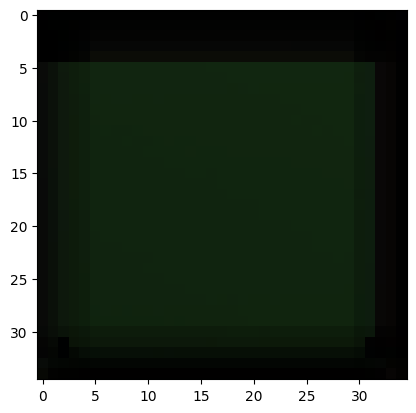

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.870347023010254, epoch:284/1000


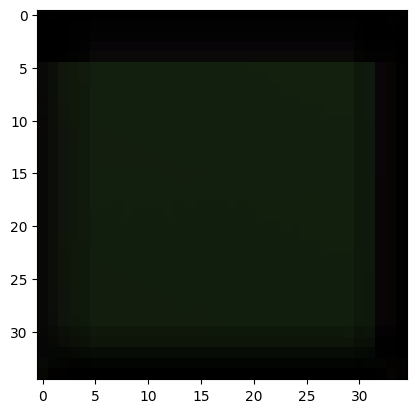

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.862722396850586, epoch:285/1000


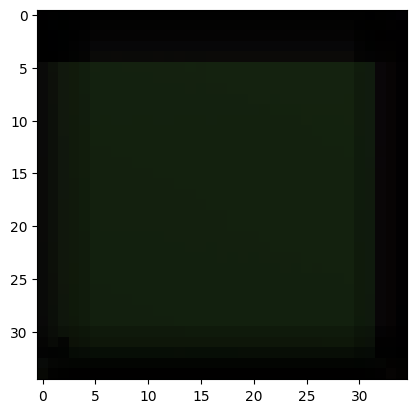

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.855377197265625, epoch:286/1000


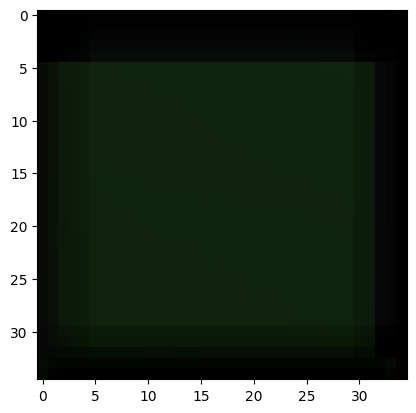

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.854192733764648, epoch:287/1000


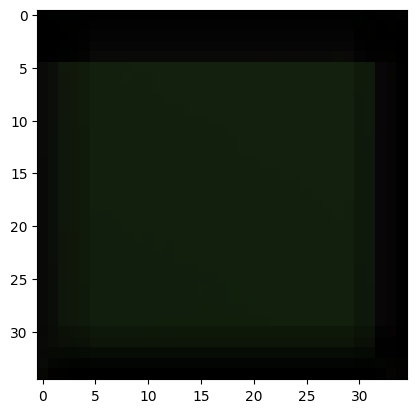

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.848119735717773, epoch:288/1000


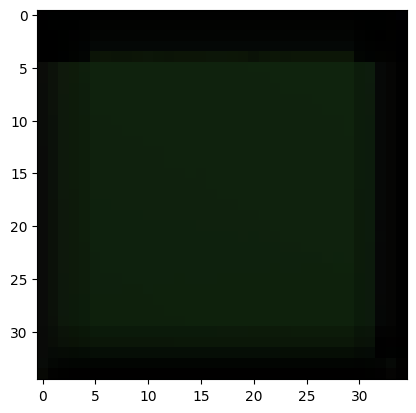

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.84235668182373, epoch:289/1000


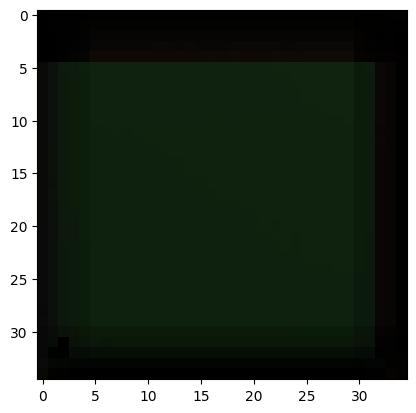

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.837000846862793, epoch:290/1000


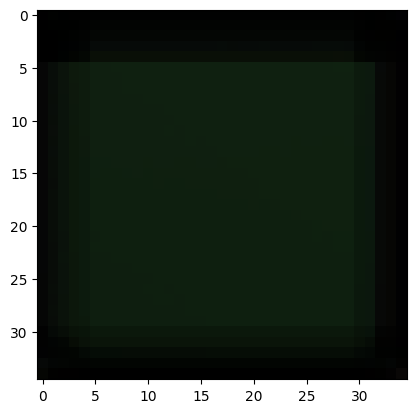

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.828815460205078, epoch:291/1000


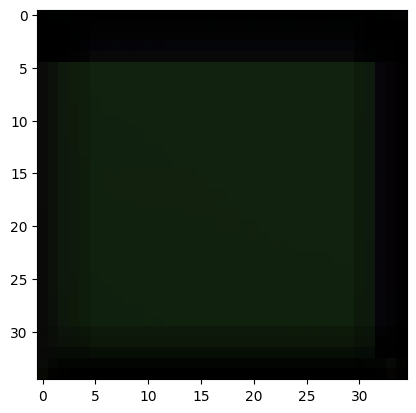

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.824129104614258, epoch:292/1000


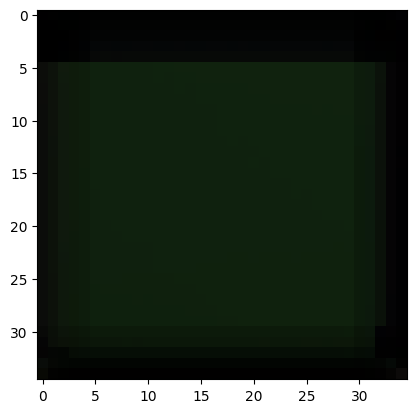

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.817517280578613, epoch:293/1000


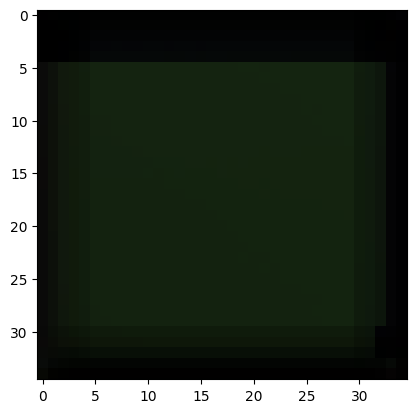

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.813501358032227, epoch:294/1000


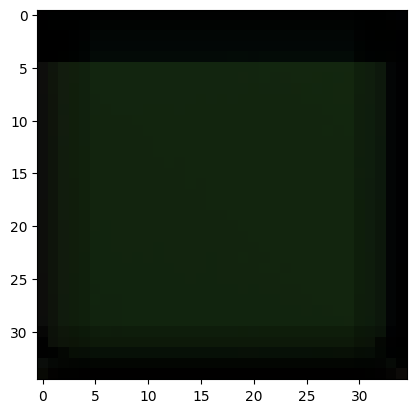

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.820136070251465, epoch:295/1000


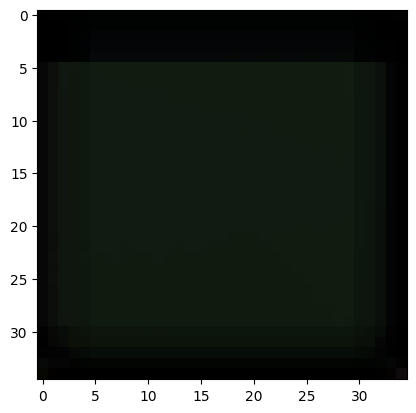

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.806575775146484, epoch:296/1000


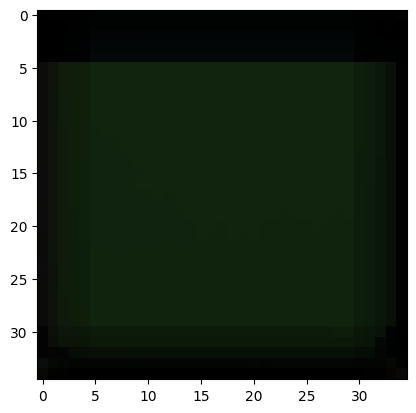

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.838647842407227, epoch:297/1000


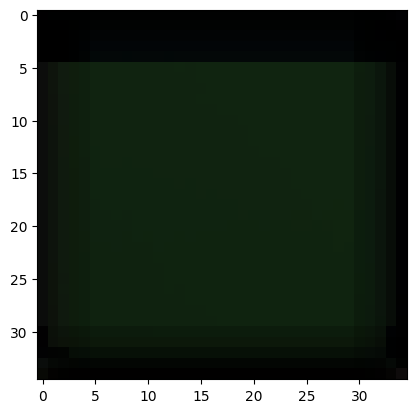

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.798361778259277, epoch:298/1000


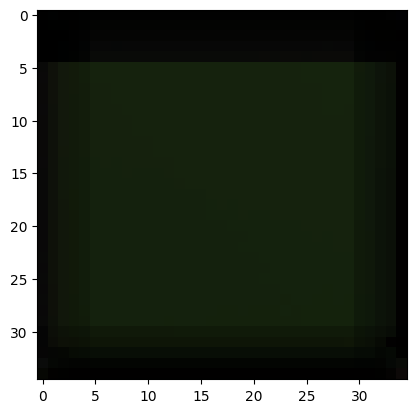

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.795848846435547, epoch:299/1000


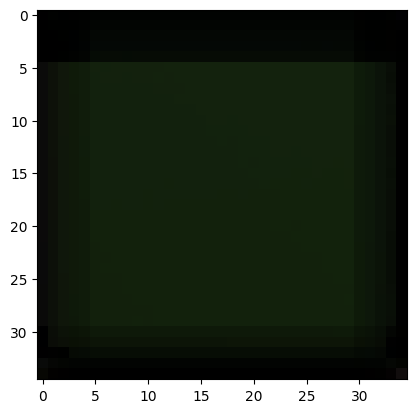

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]

loss: 12.787471771240234, epoch:300/1000


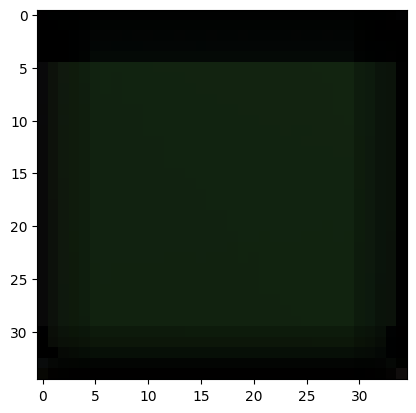

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.786090850830078, epoch:301/1000


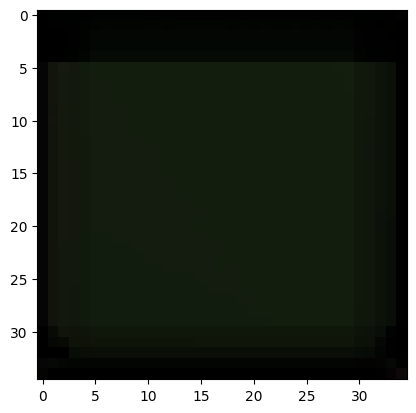

100%|██████████| 300/300 [00:55<00:00,  5.41it/s]


loss: 12.785512924194336, epoch:302/1000


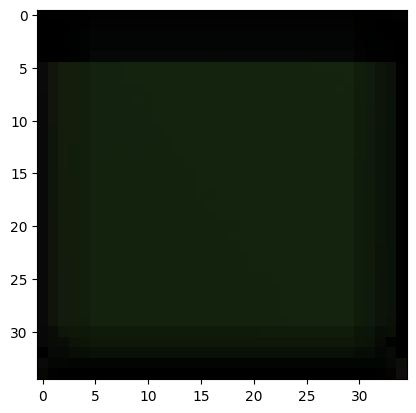

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.781270980834961, epoch:303/1000


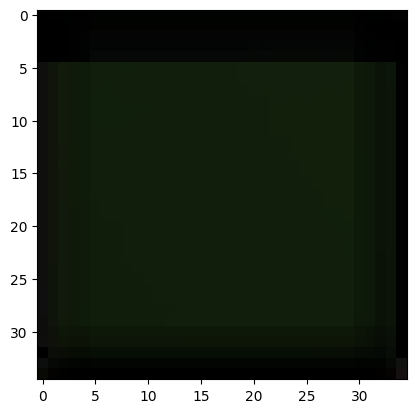

100%|██████████| 300/300 [00:54<00:00,  5.47it/s]


loss: 12.7809419631958, epoch:304/1000


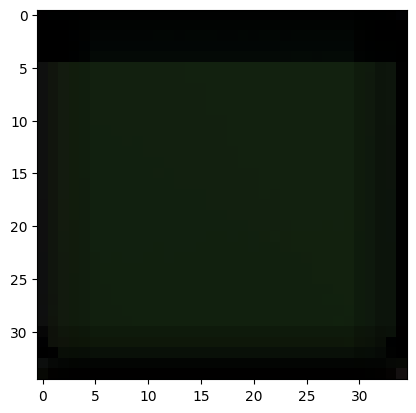

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.782323837280273, epoch:305/1000


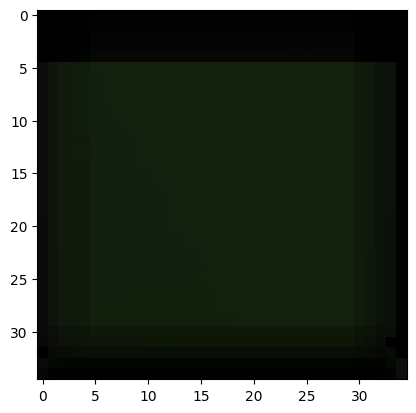

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.771916389465332, epoch:306/1000


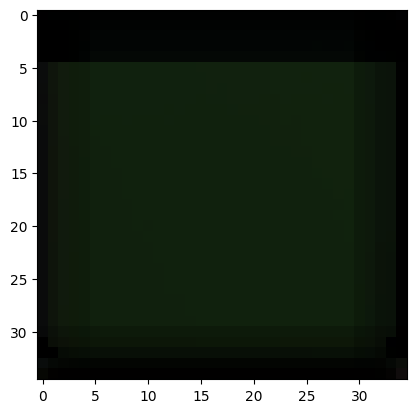

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.767824172973633, epoch:307/1000


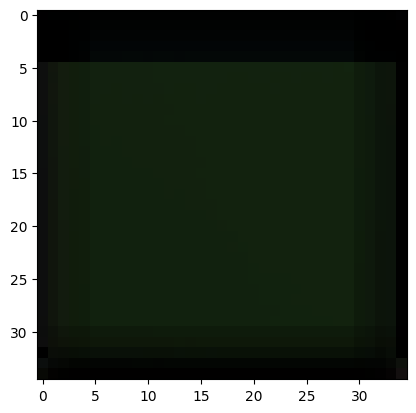

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.764638900756836, epoch:308/1000


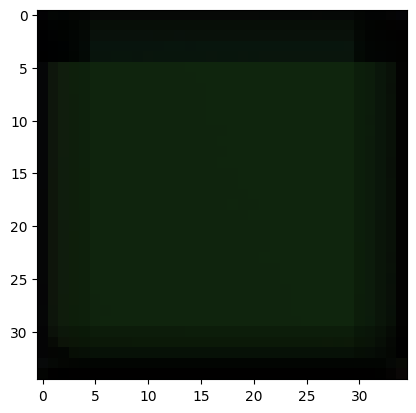

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.762130737304688, epoch:309/1000


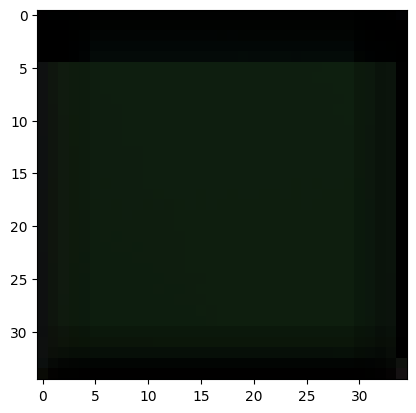

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.762506484985352, epoch:310/1000


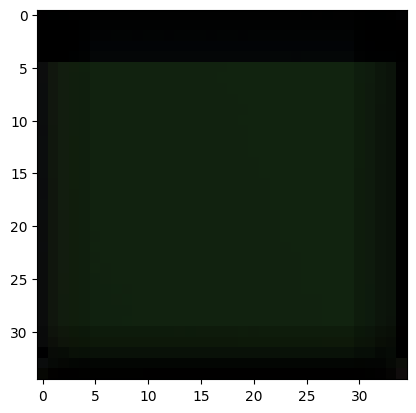

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.76012134552002, epoch:311/1000


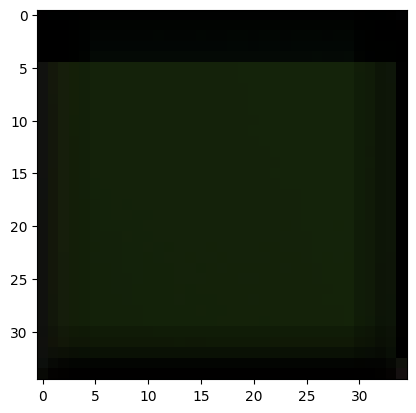

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.753460884094238, epoch:312/1000


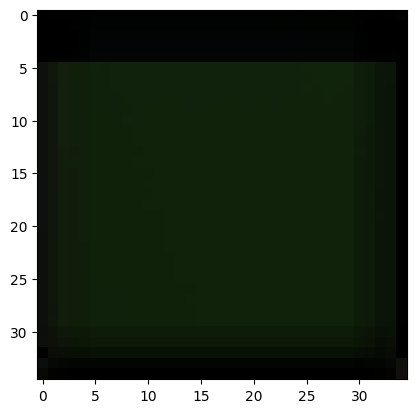

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.755162239074707, epoch:313/1000


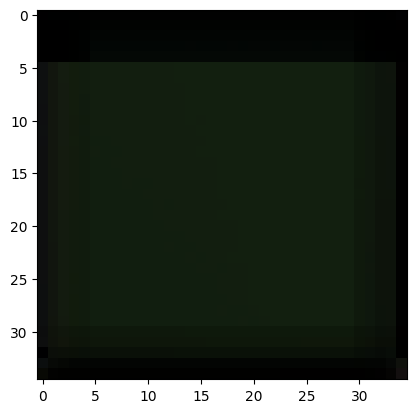

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.749476432800293, epoch:314/1000


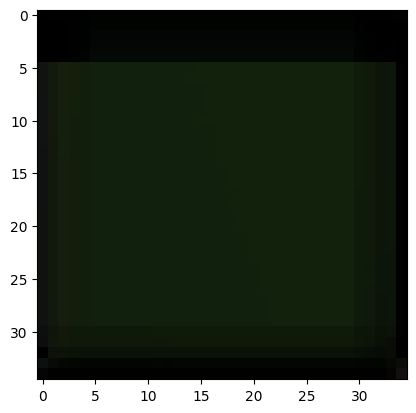

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.749635696411133, epoch:315/1000


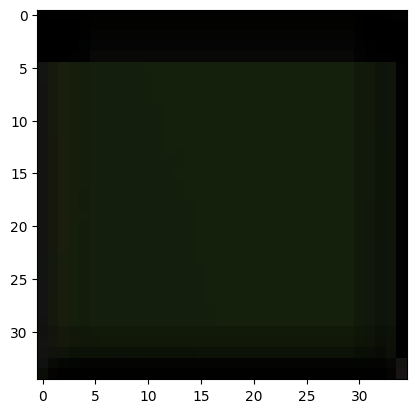

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.743988037109375, epoch:316/1000


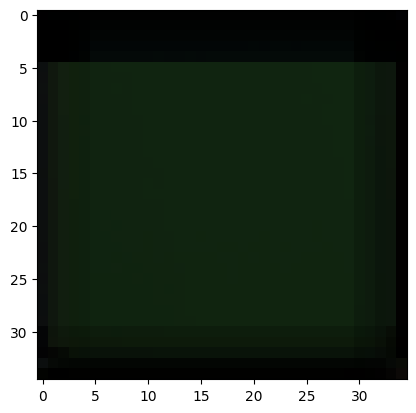

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.744382858276367, epoch:317/1000


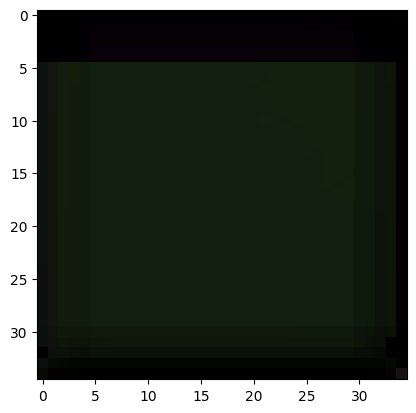

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 12.74195671081543, epoch:318/1000


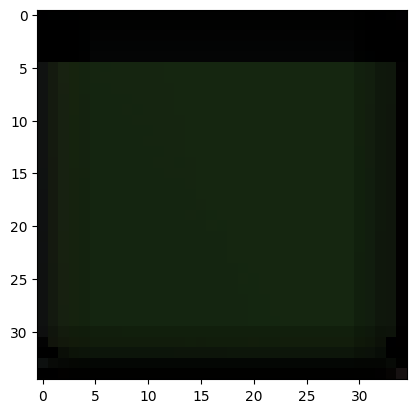

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.73960018157959, epoch:319/1000


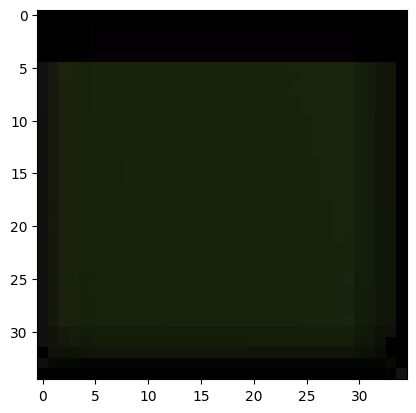

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.735445022583008, epoch:320/1000


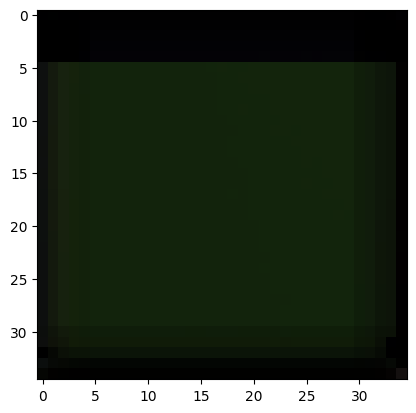

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.740241050720215, epoch:321/1000


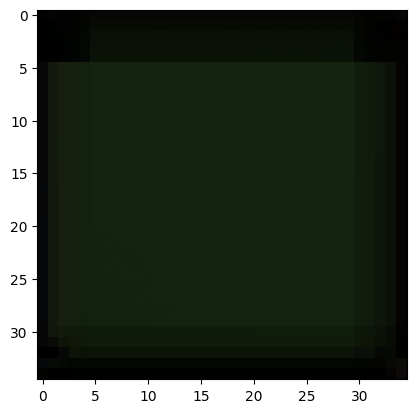

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.741700172424316, epoch:322/1000


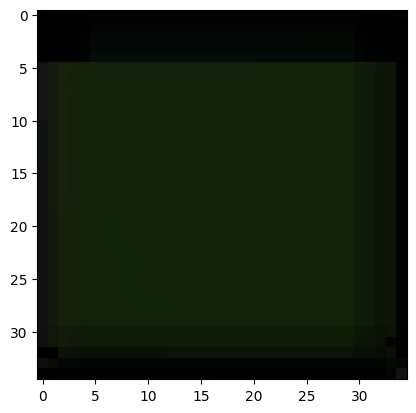

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.741386413574219, epoch:323/1000


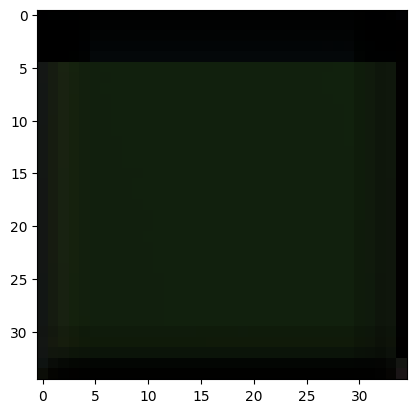

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.747419357299805, epoch:324/1000


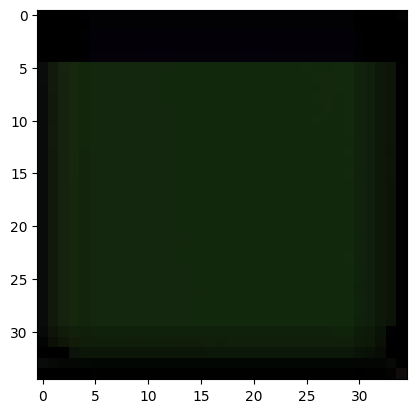

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.732547760009766, epoch:325/1000


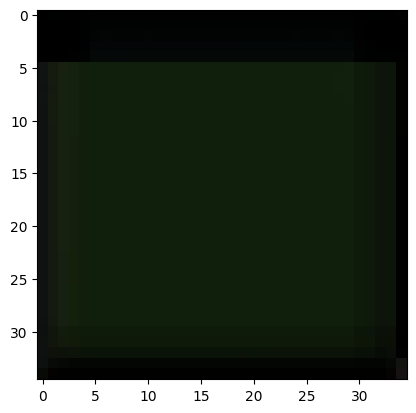

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.72490406036377, epoch:326/1000


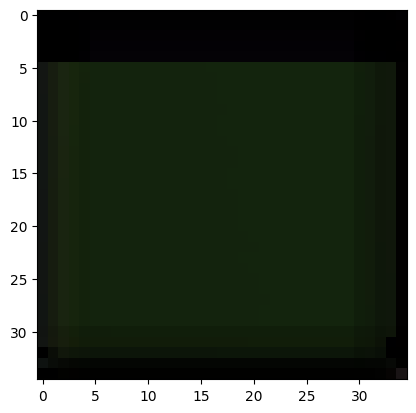

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.719698905944824, epoch:327/1000


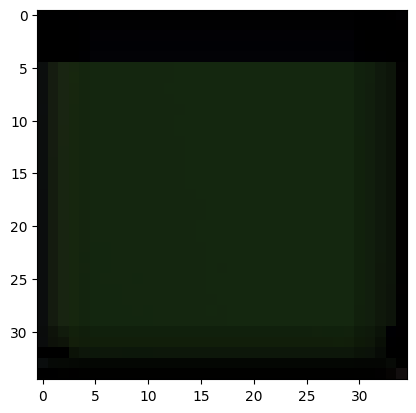

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.719432830810547, epoch:328/1000


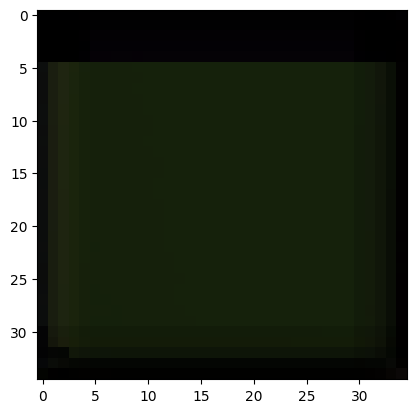

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.72081470489502, epoch:329/1000


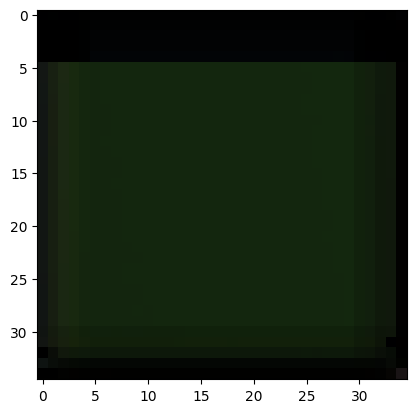

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.721114158630371, epoch:330/1000


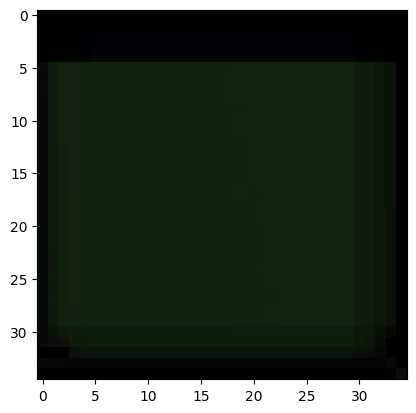

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.714099884033203, epoch:331/1000


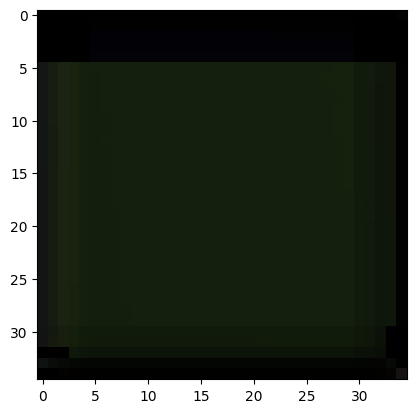

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.709647178649902, epoch:332/1000


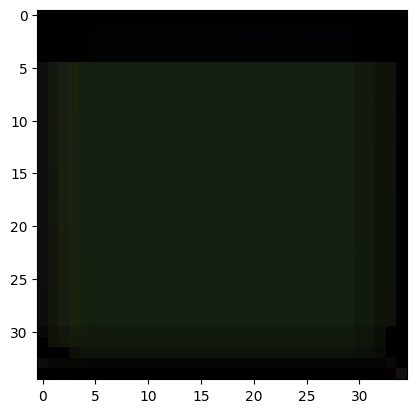

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.771071434020996, epoch:333/1000


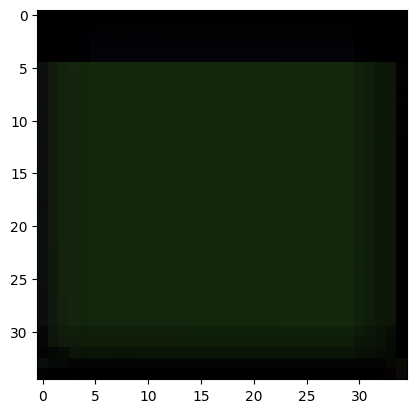

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.722870826721191, epoch:334/1000


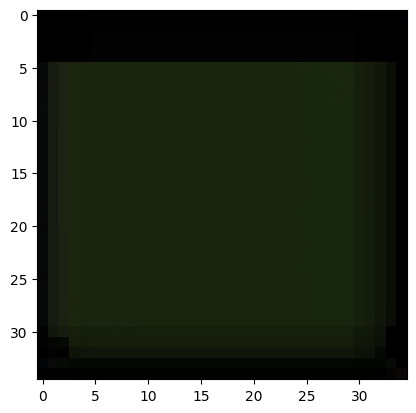

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.71335506439209, epoch:335/1000


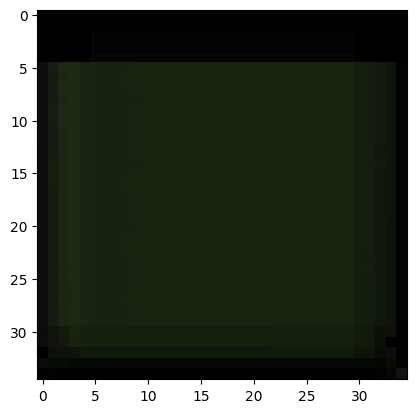

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.715622901916504, epoch:336/1000


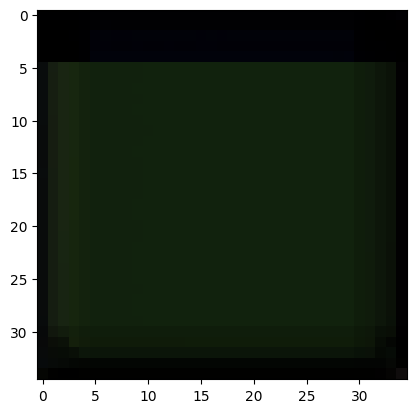

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.712623596191406, epoch:337/1000


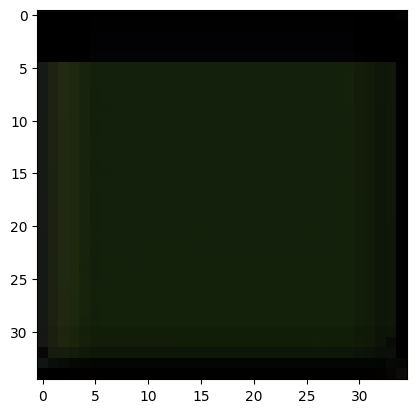

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.70312213897705, epoch:338/1000


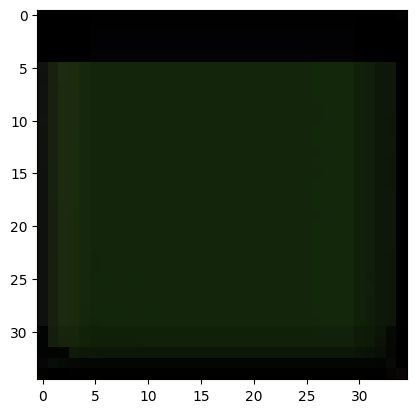

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.699867248535156, epoch:339/1000


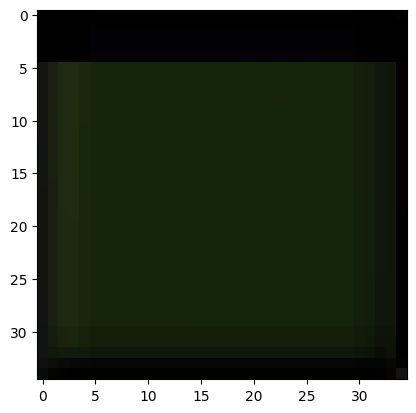

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.698051452636719, epoch:340/1000


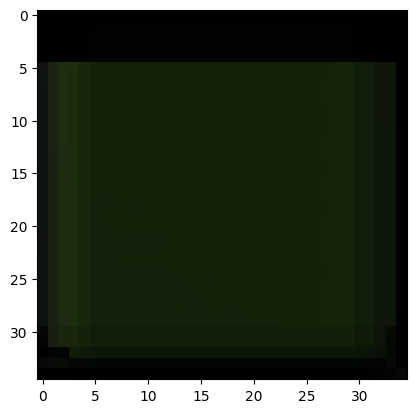

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.698149681091309, epoch:341/1000


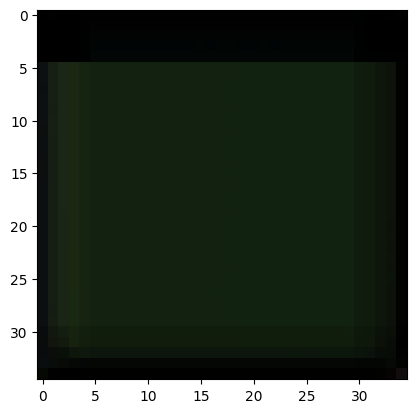

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.696269035339355, epoch:342/1000


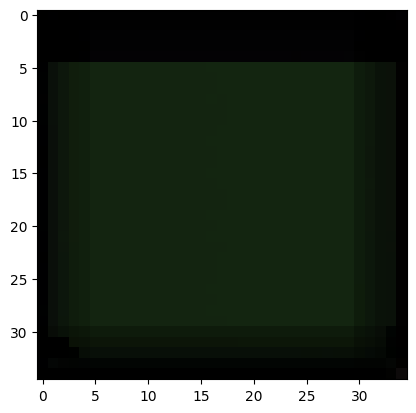

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.692718505859375, epoch:343/1000


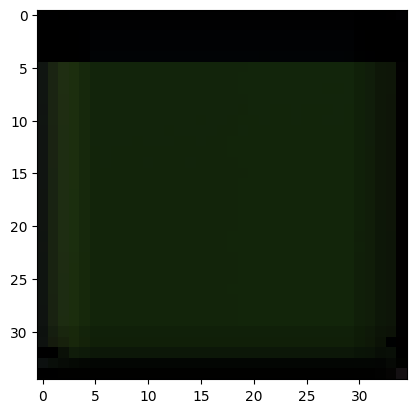

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.701228141784668, epoch:344/1000


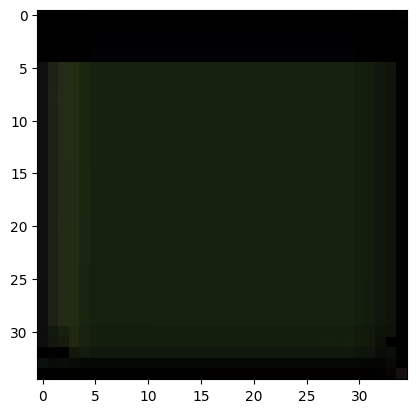

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.691425323486328, epoch:345/1000


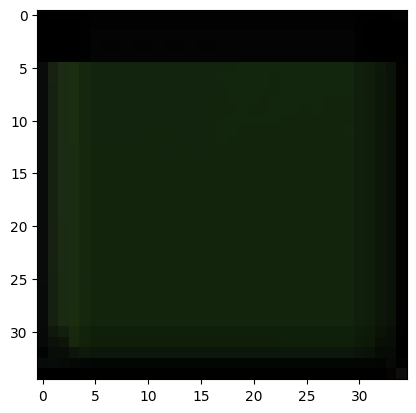

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.685429573059082, epoch:346/1000


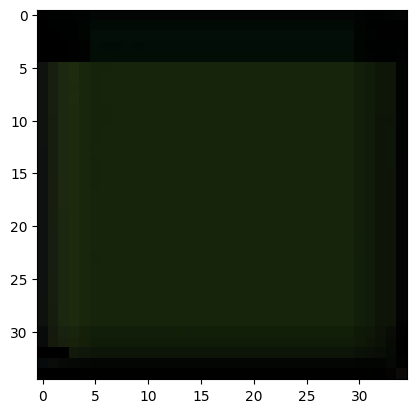

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.685090065002441, epoch:347/1000


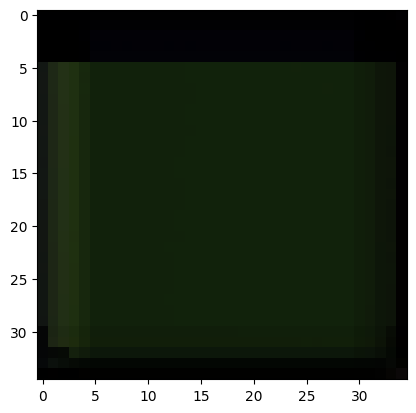

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.691232681274414, epoch:348/1000


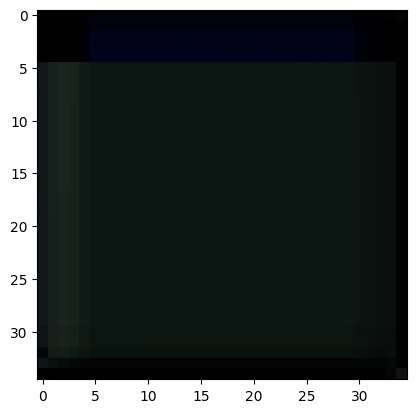

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.72717571258545, epoch:349/1000


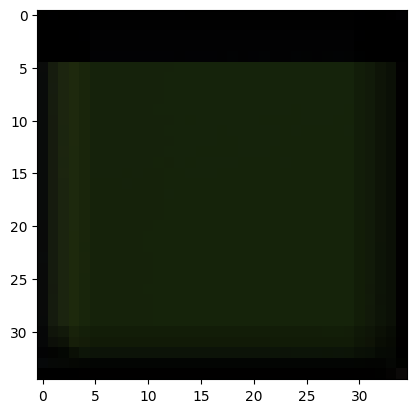

100%|██████████| 300/300 [00:56<00:00,  5.35it/s]

loss: 12.683655738830566, epoch:350/1000


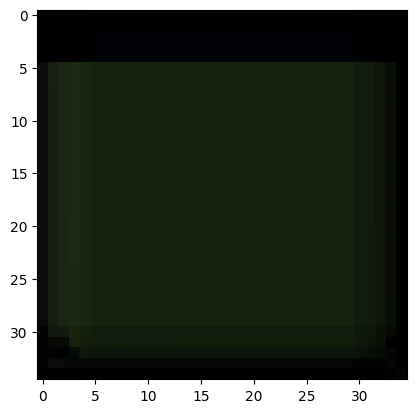

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.681401252746582, epoch:351/1000


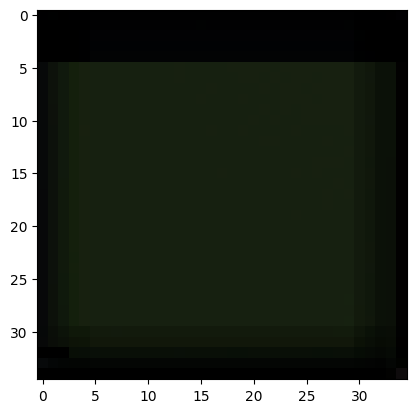

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.67519760131836, epoch:352/1000


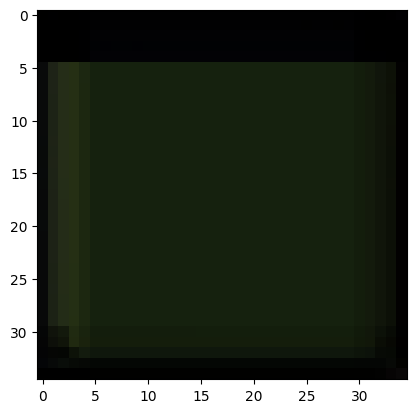

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.674481391906738, epoch:353/1000


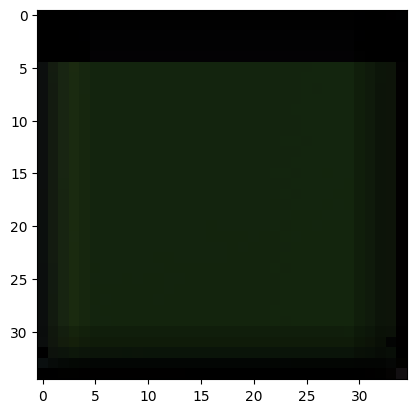

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.672035217285156, epoch:354/1000


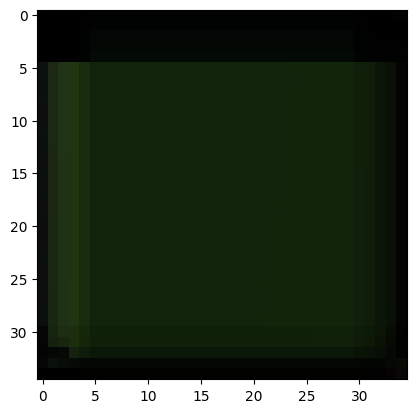

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.673990249633789, epoch:355/1000


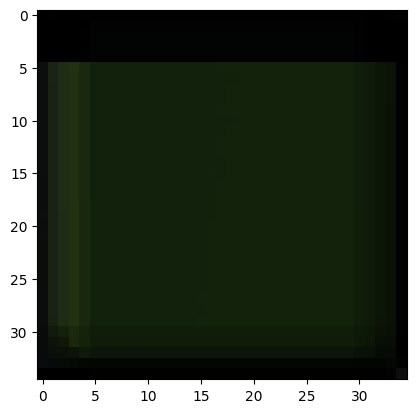

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.679445266723633, epoch:356/1000


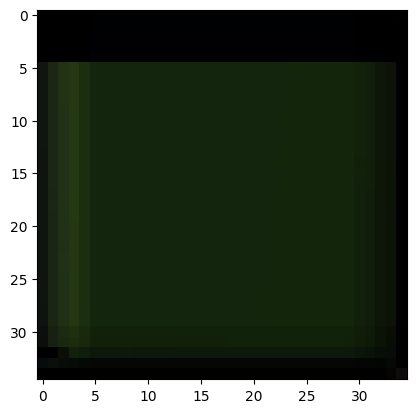

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.669906616210938, epoch:357/1000


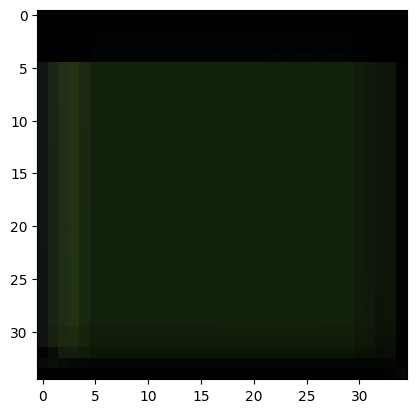

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.675333023071289, epoch:358/1000


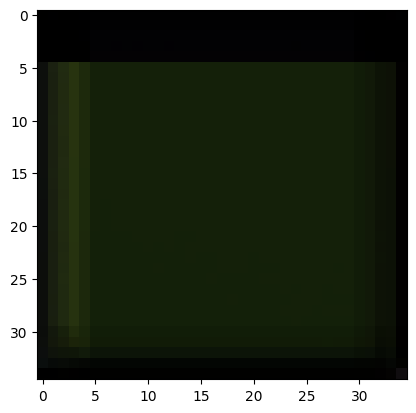

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.667192459106445, epoch:359/1000


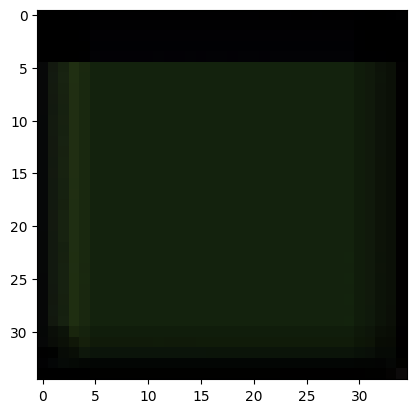

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.665698051452637, epoch:360/1000


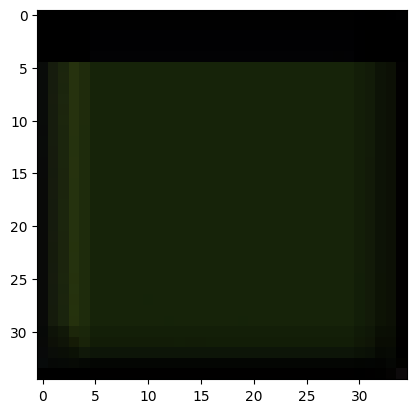

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.66039752960205, epoch:361/1000


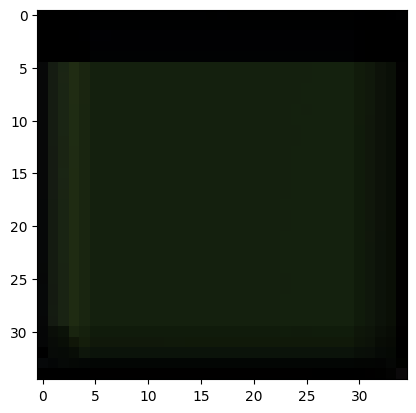

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.659607887268066, epoch:362/1000


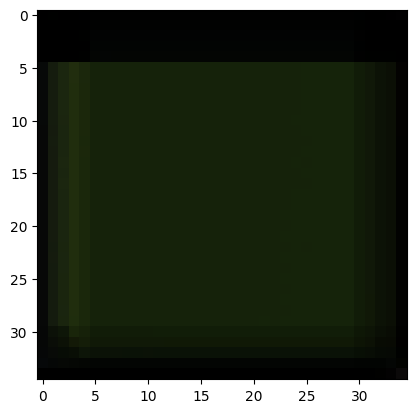

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.65727710723877, epoch:363/1000


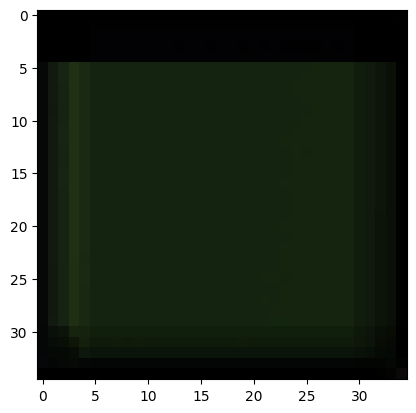

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.657904624938965, epoch:364/1000


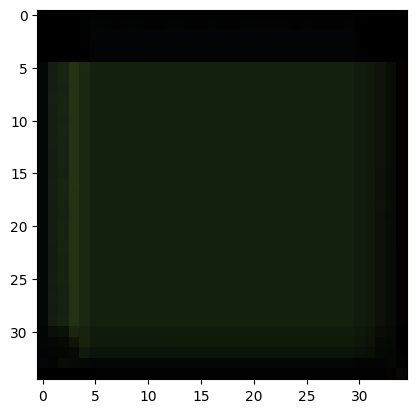

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.658061027526855, epoch:365/1000


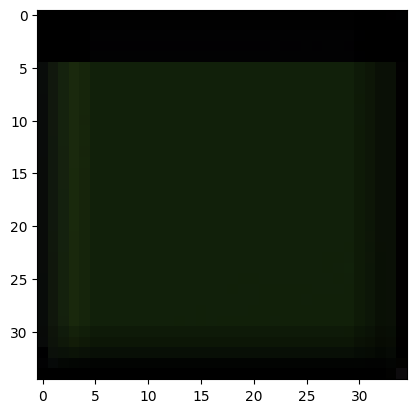

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.652417182922363, epoch:366/1000


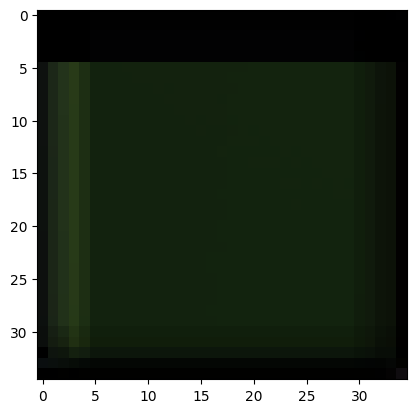

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.650053024291992, epoch:367/1000


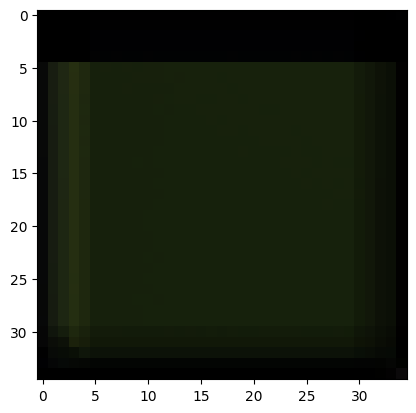

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.65006160736084, epoch:368/1000


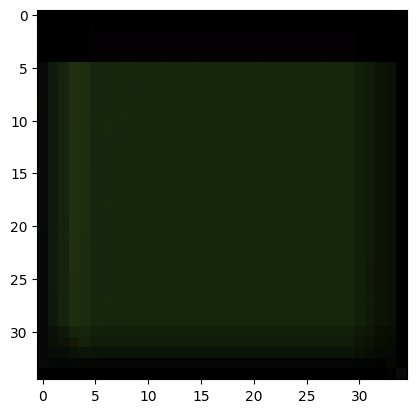

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.655649185180664, epoch:369/1000


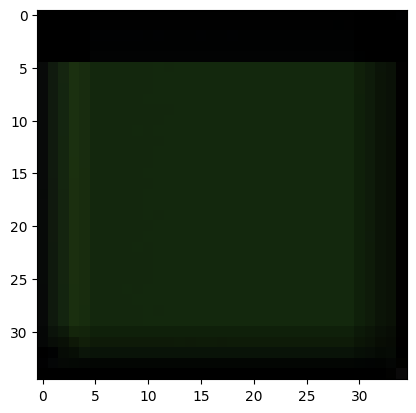

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.649532318115234, epoch:370/1000


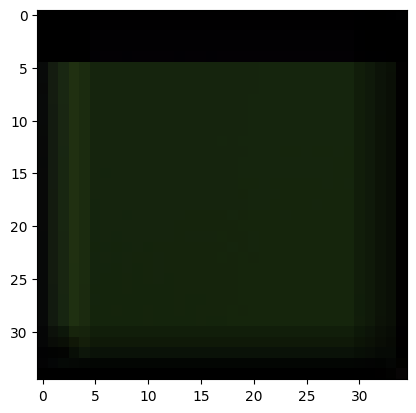

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.649762153625488, epoch:371/1000


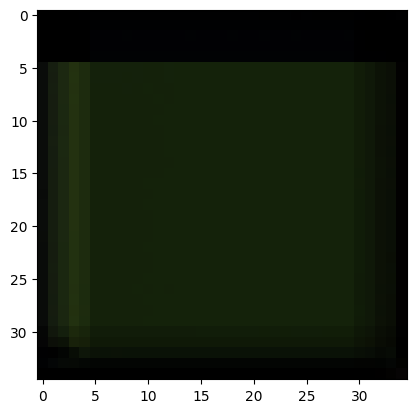

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.645038604736328, epoch:372/1000


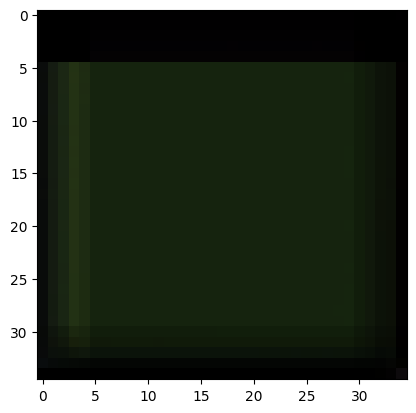

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.646103858947754, epoch:373/1000


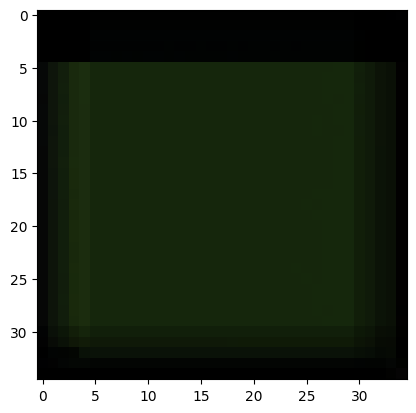

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.638768196105957, epoch:374/1000


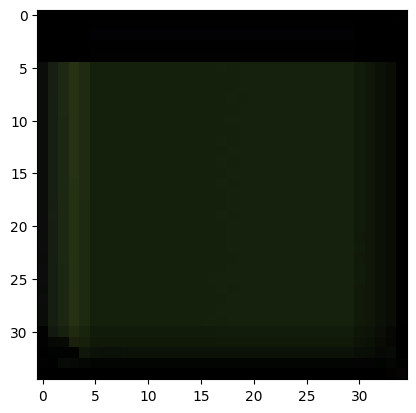

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.638415336608887, epoch:375/1000


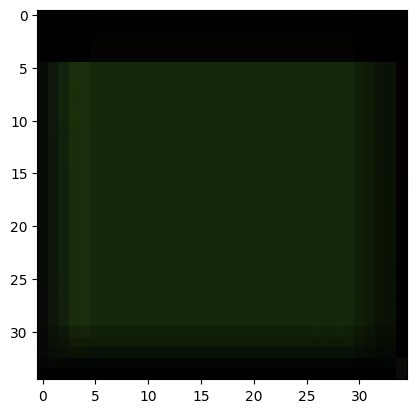

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.639934539794922, epoch:376/1000


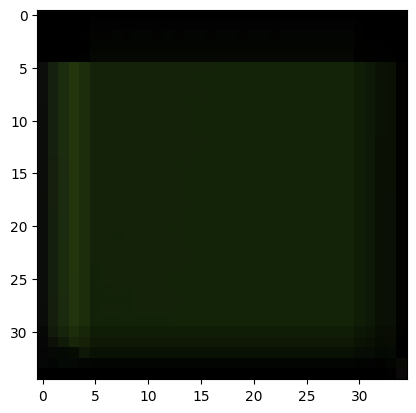

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.645421028137207, epoch:377/1000


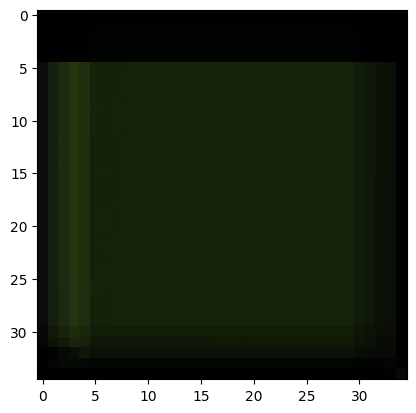

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.64183521270752, epoch:378/1000


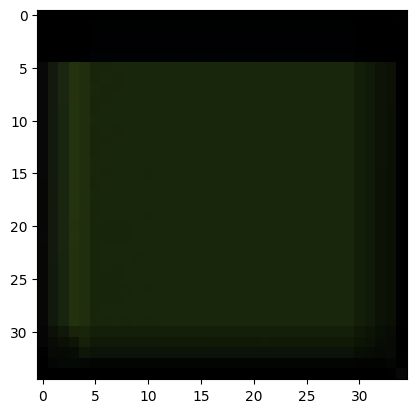

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.636120796203613, epoch:379/1000


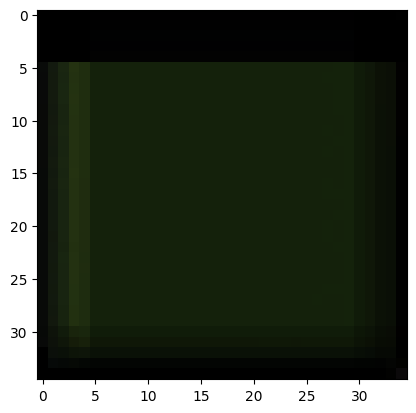

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.63374137878418, epoch:380/1000


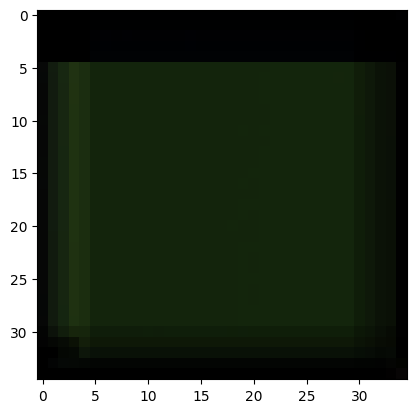

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.632926940917969, epoch:381/1000


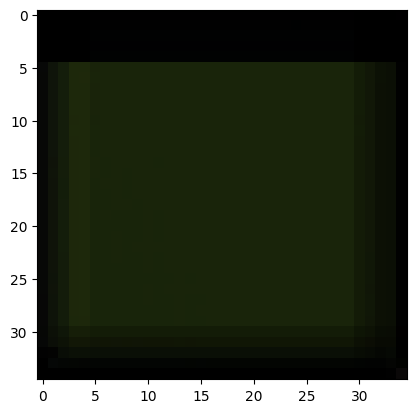

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.632143020629883, epoch:382/1000


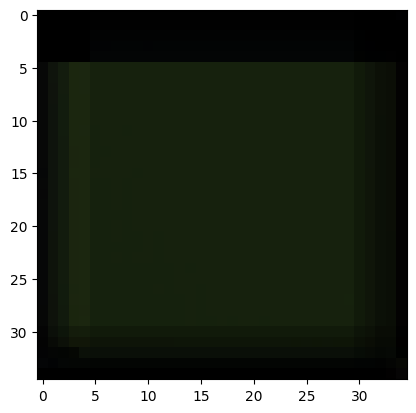

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.629780769348145, epoch:383/1000


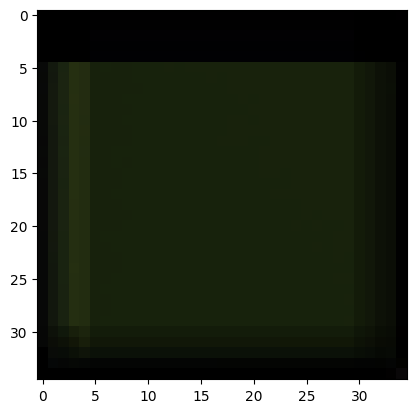

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.628750801086426, epoch:384/1000


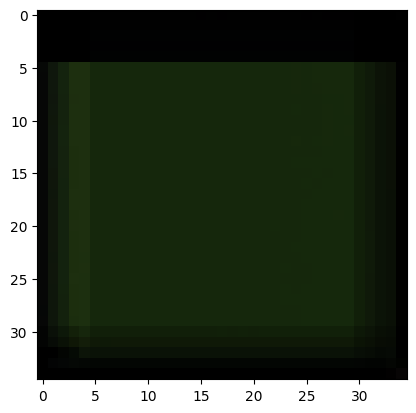

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 12.625868797302246, epoch:385/1000


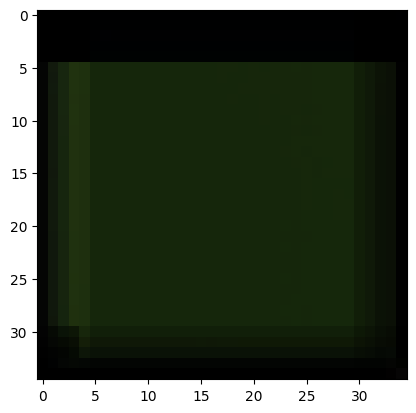

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.625696182250977, epoch:386/1000


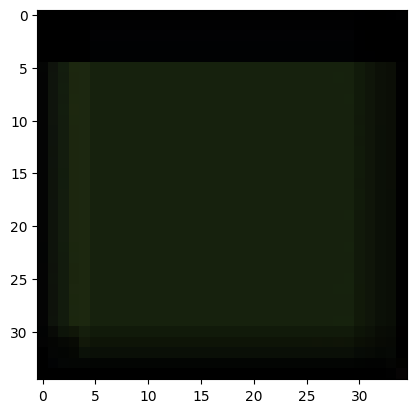

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 12.626737594604492, epoch:387/1000


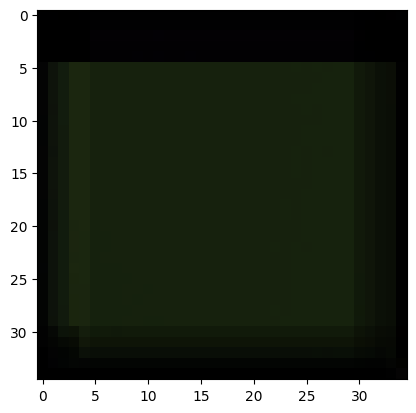

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.65539264678955, epoch:388/1000


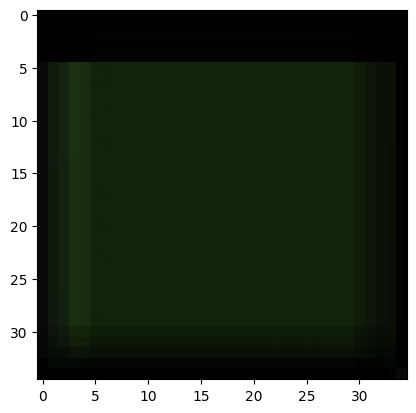

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.625007629394531, epoch:389/1000


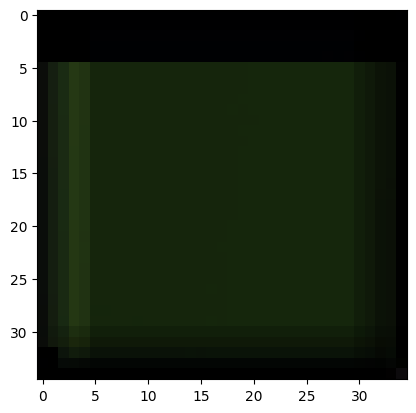

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.623286247253418, epoch:390/1000


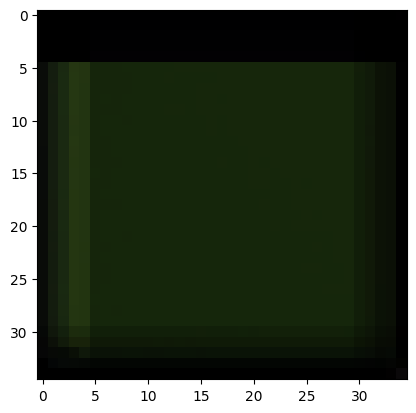

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.623238563537598, epoch:391/1000


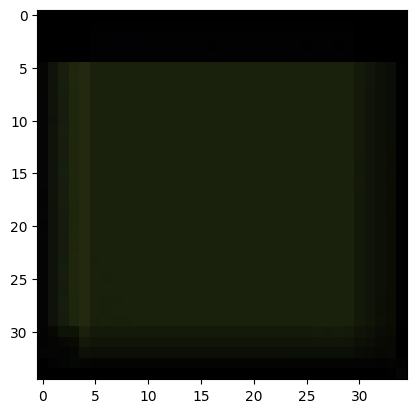

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.624261856079102, epoch:392/1000


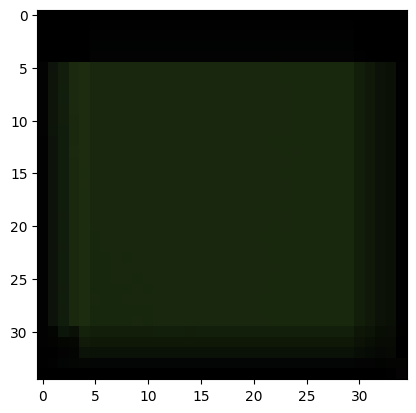

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.620807647705078, epoch:393/1000


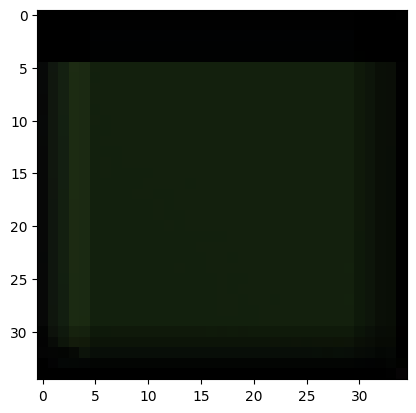

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.617903709411621, epoch:394/1000


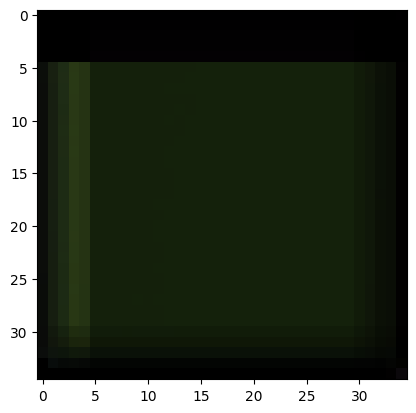

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.62069034576416, epoch:395/1000


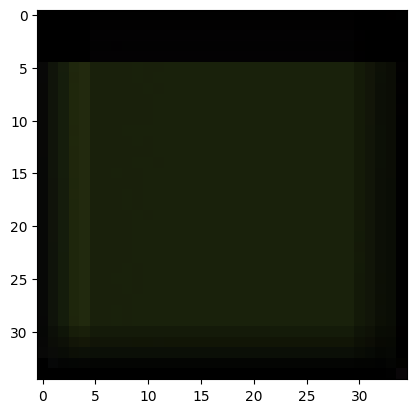

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.613572120666504, epoch:396/1000


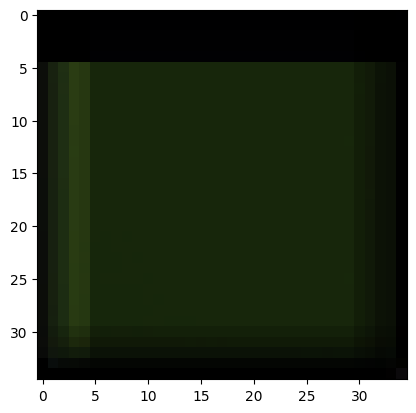

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.62470531463623, epoch:397/1000


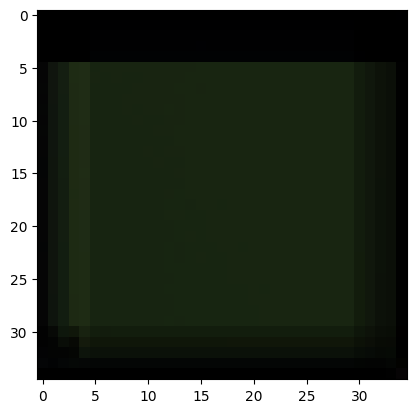

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.617640495300293, epoch:398/1000


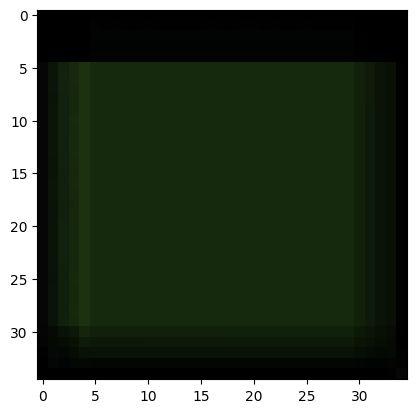

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.619699478149414, epoch:399/1000


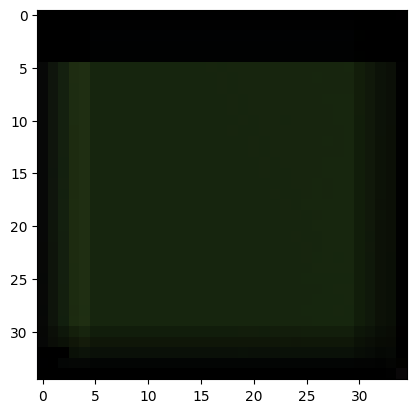

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.613341331481934, epoch:400/1000


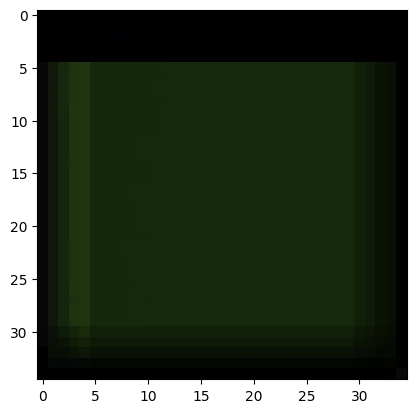

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.613953590393066, epoch:401/1000


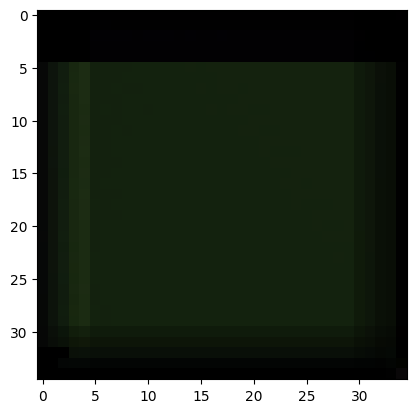

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.610628128051758, epoch:402/1000


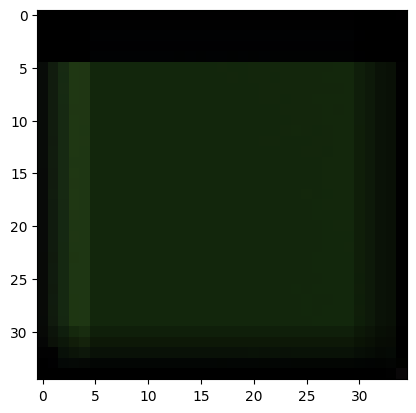

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.60844898223877, epoch:403/1000


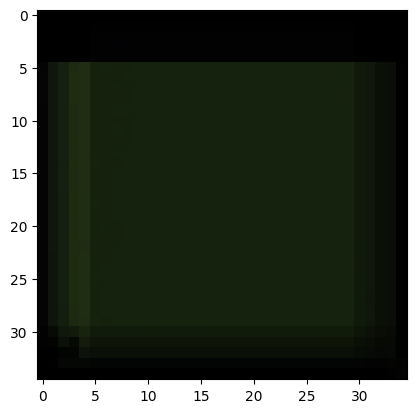

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]

loss: 12.619667053222656, epoch:404/1000


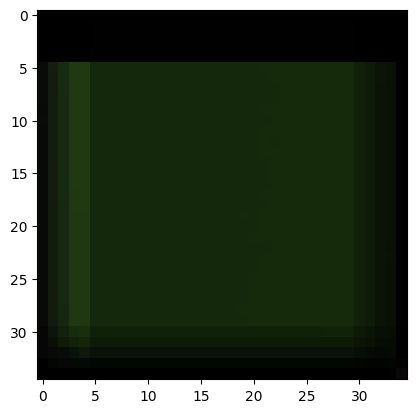

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.622225761413574, epoch:405/1000


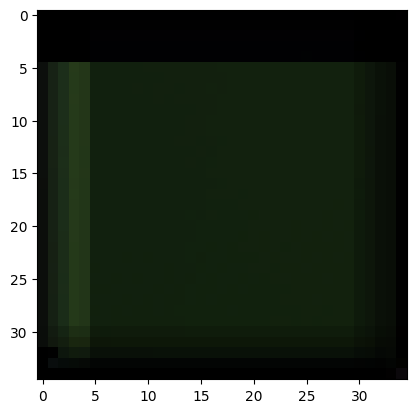

100%|██████████| 300/300 [00:55<00:00,  5.44it/s]


loss: 12.608661651611328, epoch:406/1000


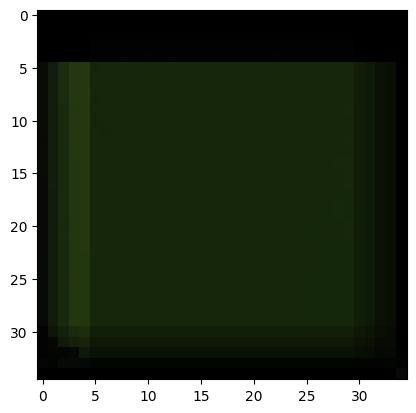

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.610031127929688, epoch:407/1000


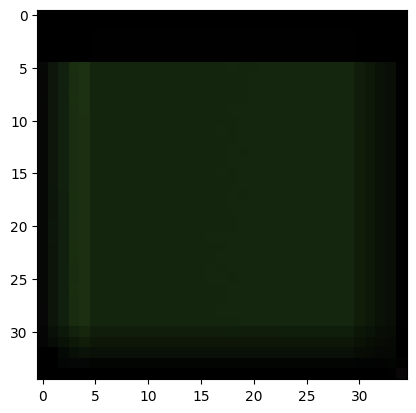

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.608592987060547, epoch:408/1000


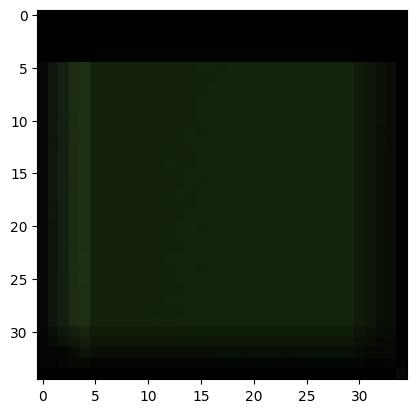

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.604016304016113, epoch:409/1000


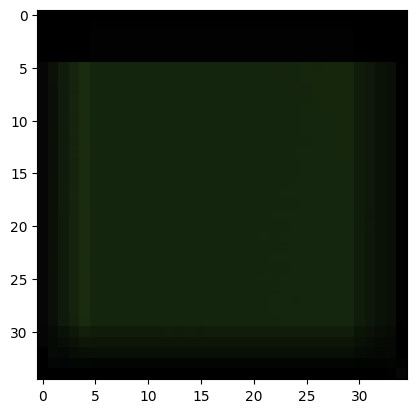

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.602357864379883, epoch:410/1000


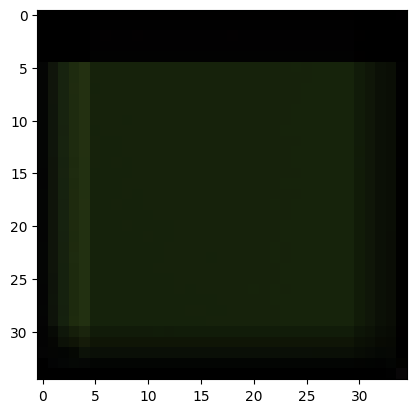

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.604141235351562, epoch:411/1000


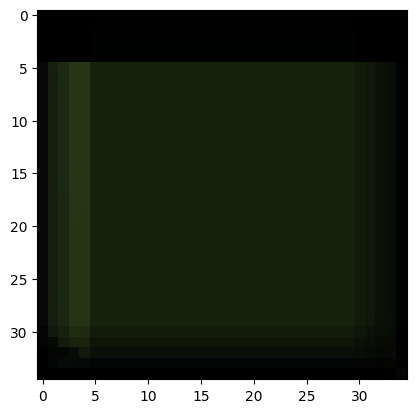

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.648771286010742, epoch:412/1000


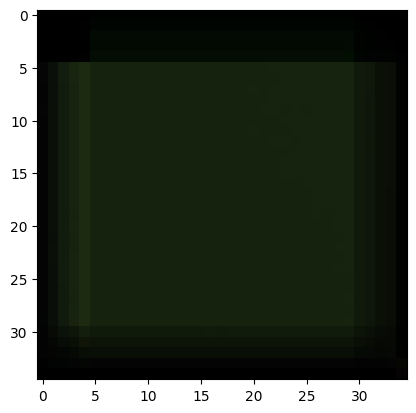

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.625617980957031, epoch:413/1000


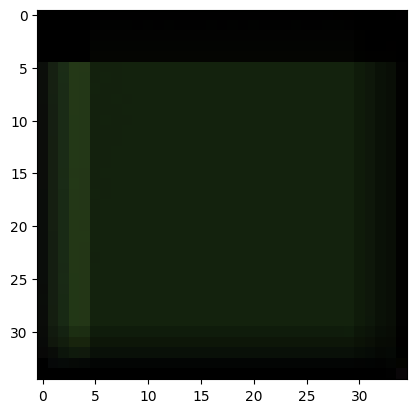

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.6128568649292, epoch:414/1000


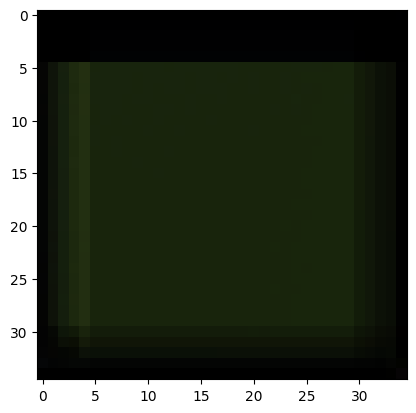

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.613153457641602, epoch:415/1000


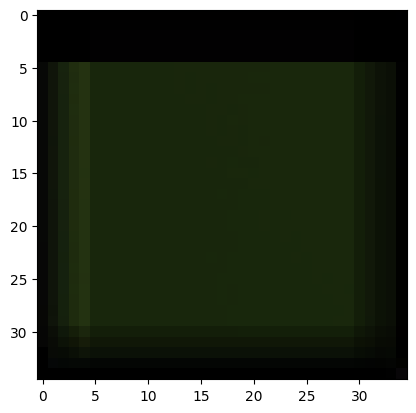

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.602717399597168, epoch:416/1000


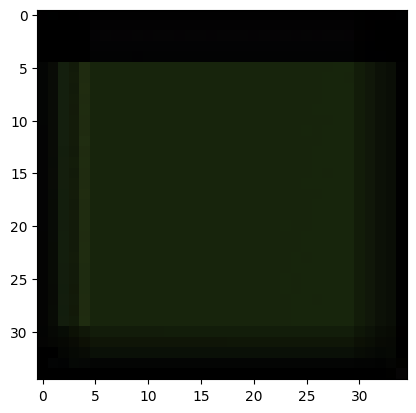

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.600141525268555, epoch:417/1000


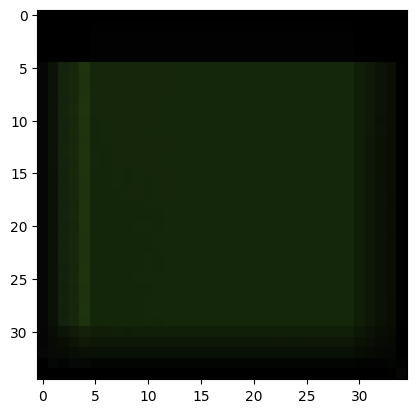

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.601824760437012, epoch:418/1000


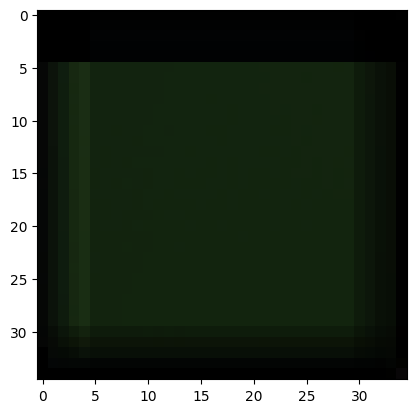

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.599132537841797, epoch:419/1000


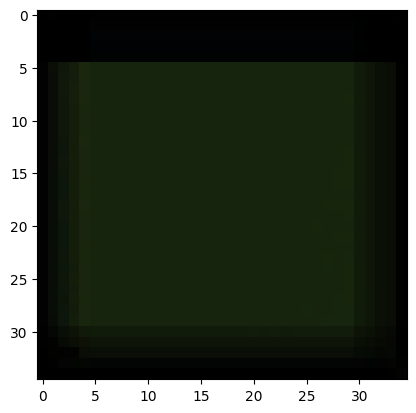

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.602766036987305, epoch:420/1000


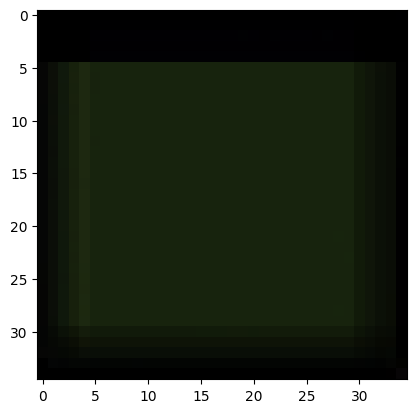

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.60476303100586, epoch:421/1000


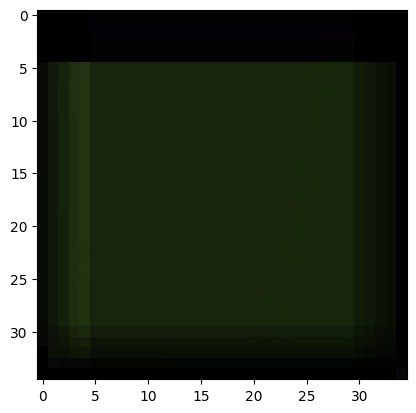

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.607502937316895, epoch:422/1000


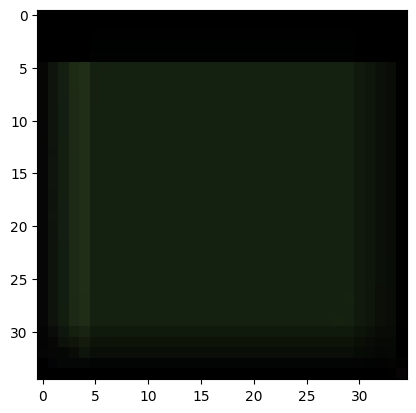

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.61148738861084, epoch:423/1000


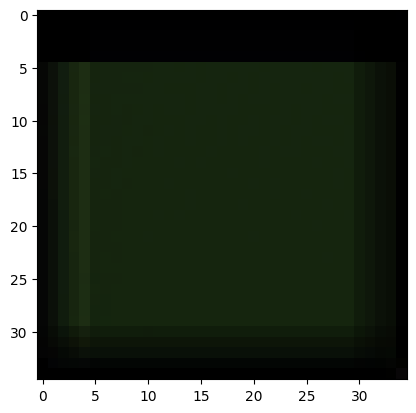

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.601472854614258, epoch:424/1000


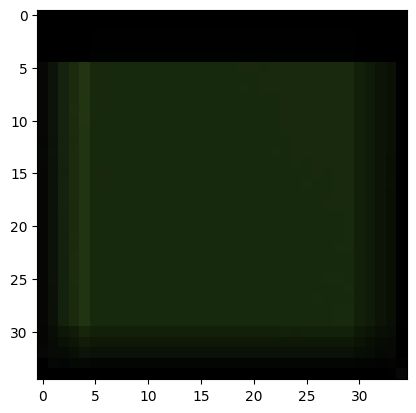

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.59731674194336, epoch:425/1000


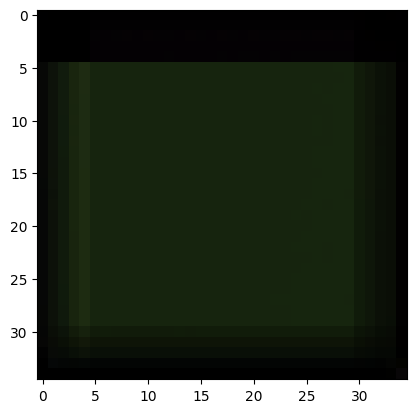

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.599189758300781, epoch:426/1000


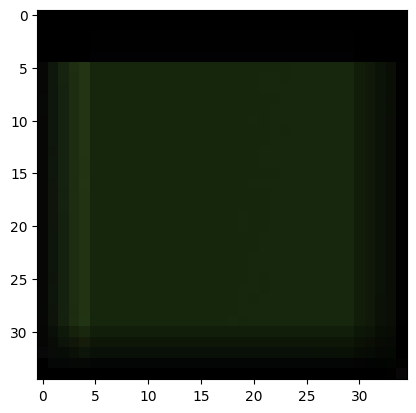

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 12.596073150634766, epoch:427/1000


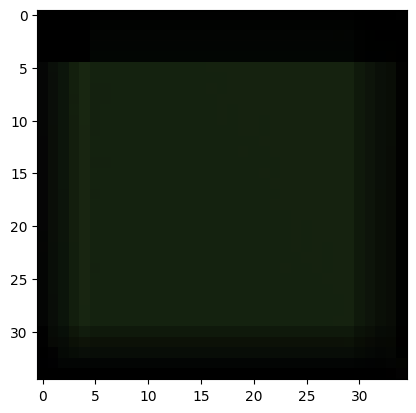

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.59387493133545, epoch:428/1000


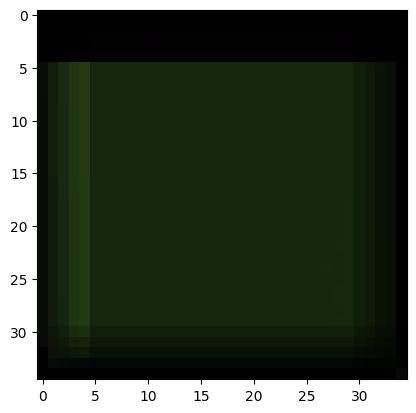

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.595093727111816, epoch:429/1000


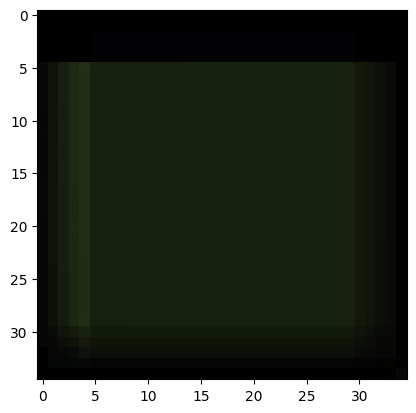

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.596623420715332, epoch:430/1000


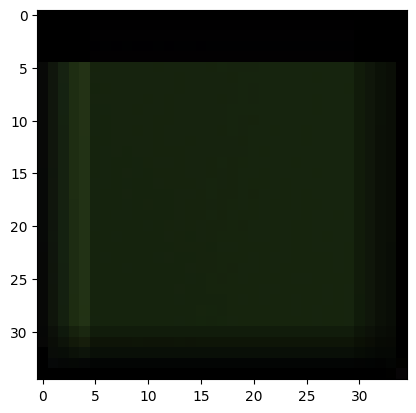

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 12.592966079711914, epoch:431/1000


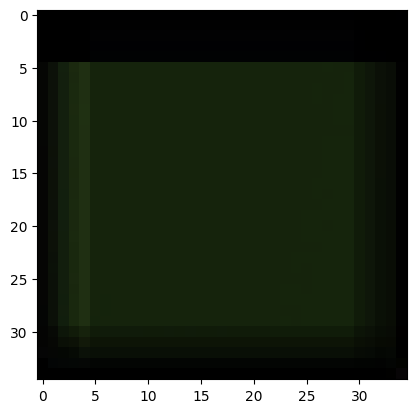

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.593147277832031, epoch:432/1000


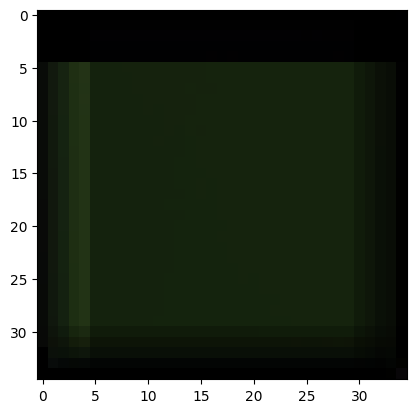

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.598048210144043, epoch:433/1000


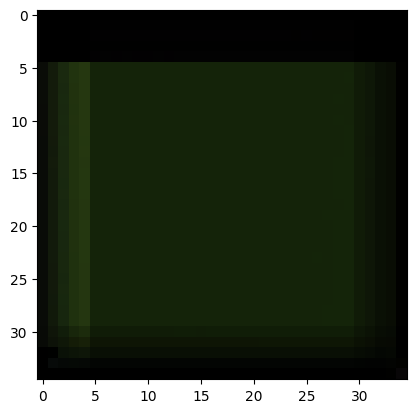

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.593313217163086, epoch:434/1000


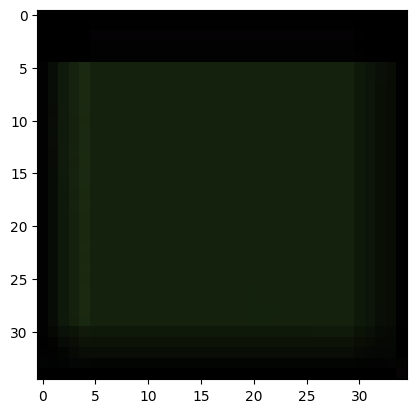

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.592358589172363, epoch:435/1000


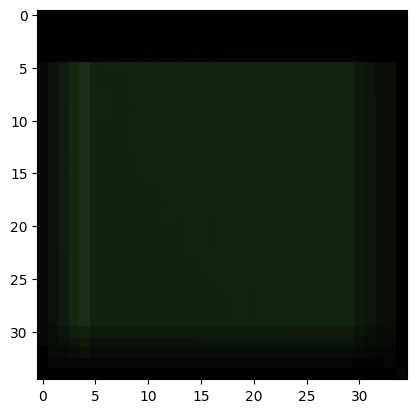

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.595969200134277, epoch:436/1000


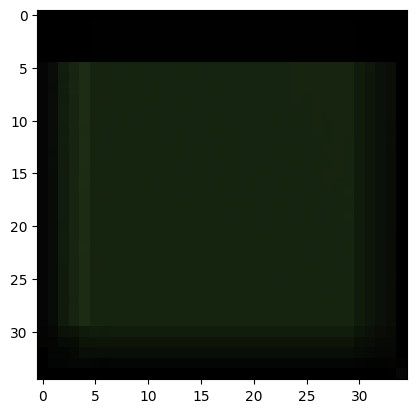

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.588129043579102, epoch:437/1000


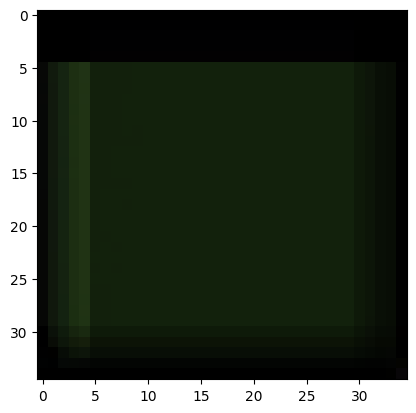

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.600253105163574, epoch:438/1000


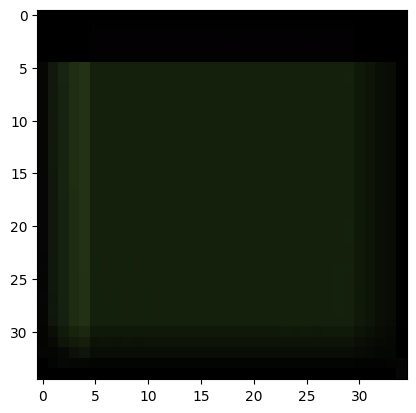

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.587647438049316, epoch:439/1000


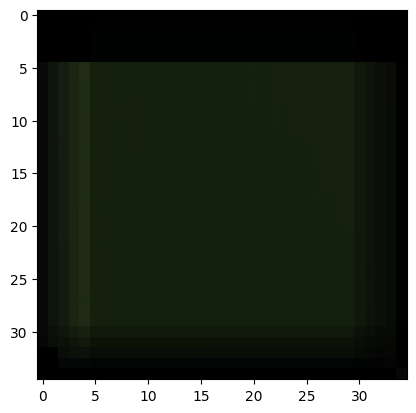

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.586271286010742, epoch:440/1000


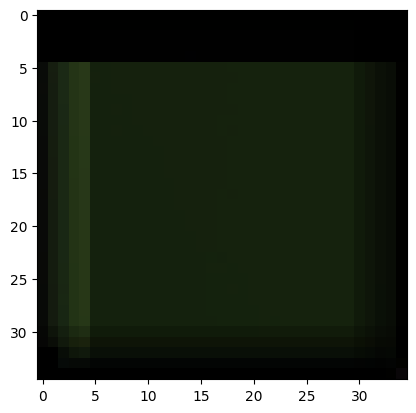

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.586857795715332, epoch:441/1000


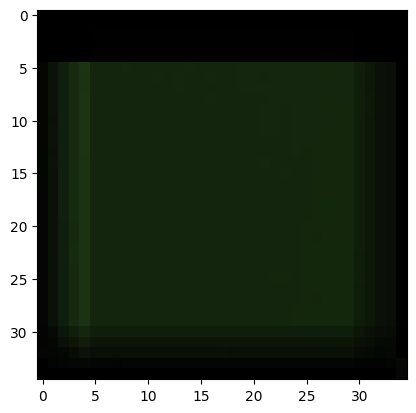

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.586891174316406, epoch:442/1000


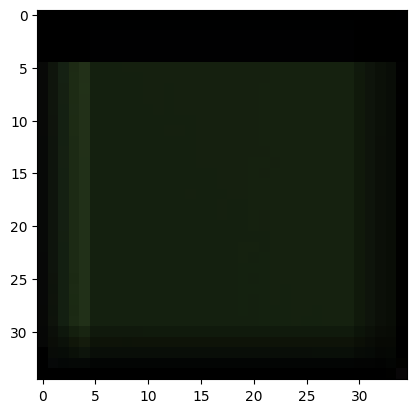

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.583611488342285, epoch:443/1000


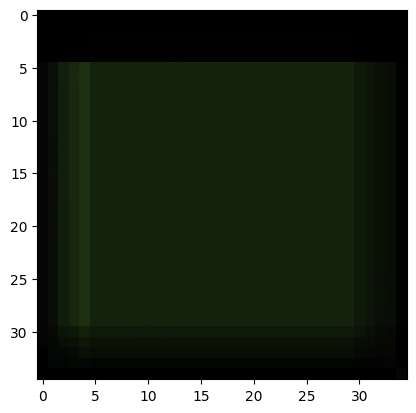

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.58638858795166, epoch:444/1000


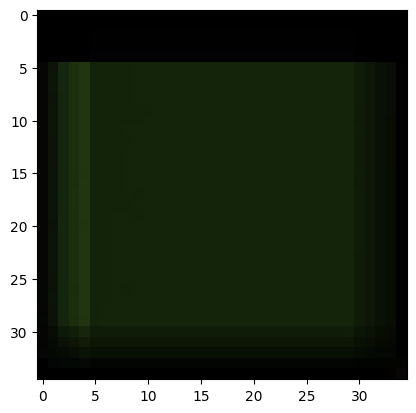

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.585158348083496, epoch:445/1000


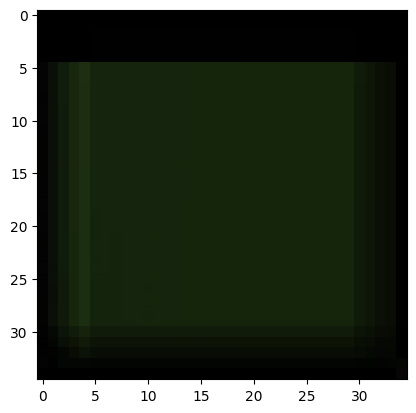

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.587117195129395, epoch:446/1000


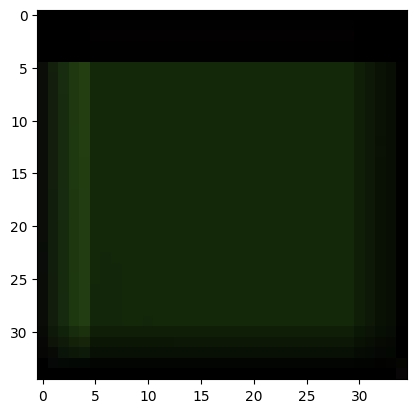

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.585360527038574, epoch:447/1000


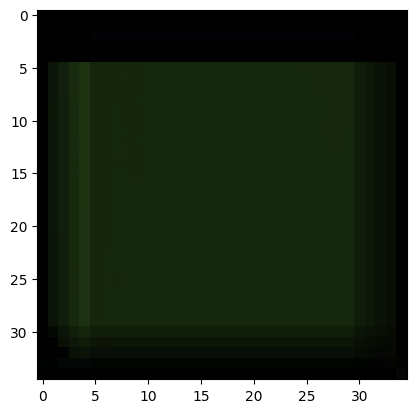

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.584134101867676, epoch:448/1000


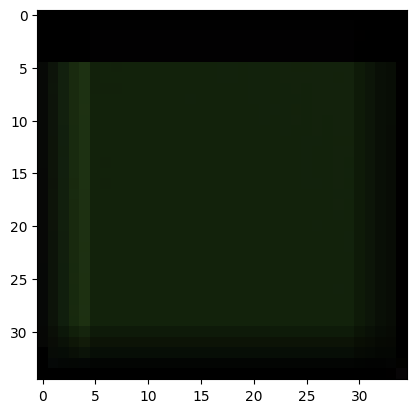

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.586332321166992, epoch:449/1000


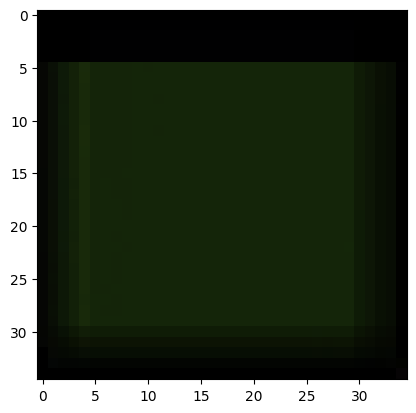

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.5808687210083, epoch:450/1000


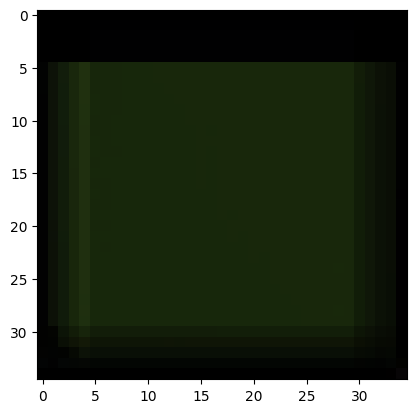

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.581978797912598, epoch:451/1000


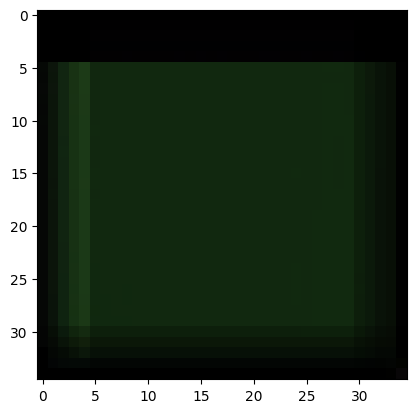

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.579880714416504, epoch:452/1000


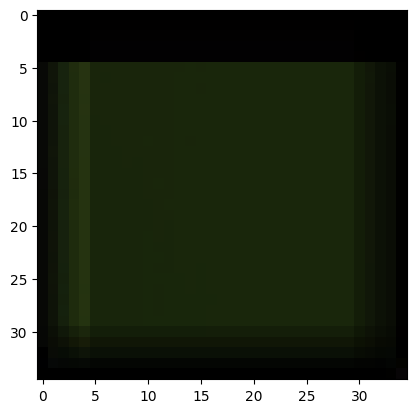

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.578951835632324, epoch:453/1000


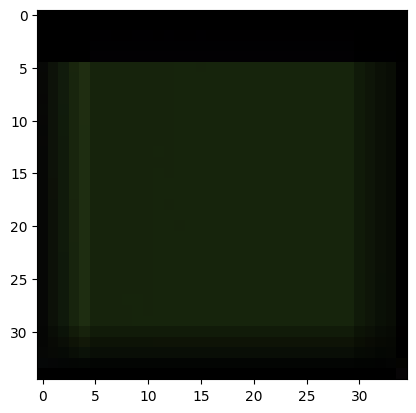

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.58254337310791, epoch:454/1000


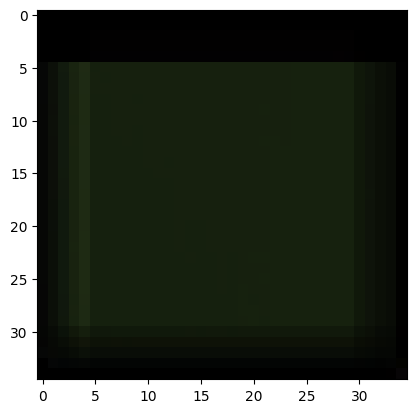

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.586926460266113, epoch:455/1000


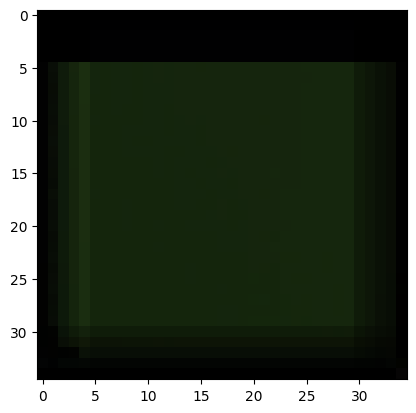

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.579431533813477, epoch:456/1000


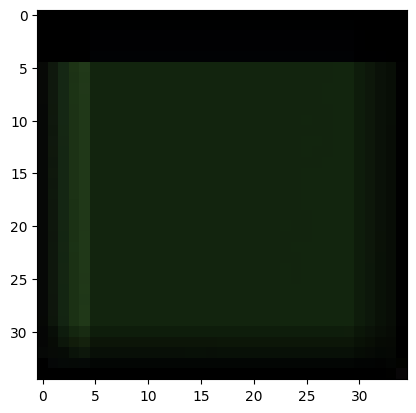

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.576812744140625, epoch:457/1000


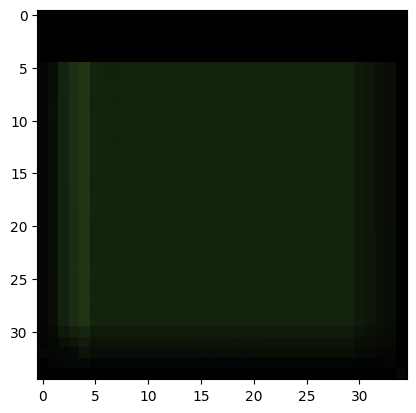

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.582297325134277, epoch:458/1000


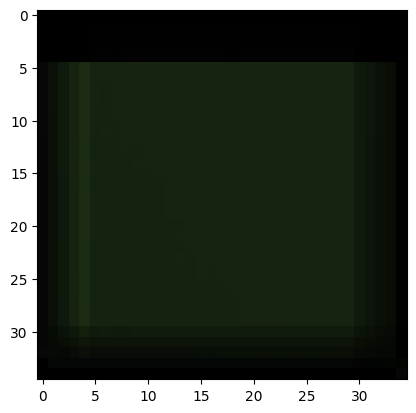

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.58139419555664, epoch:459/1000


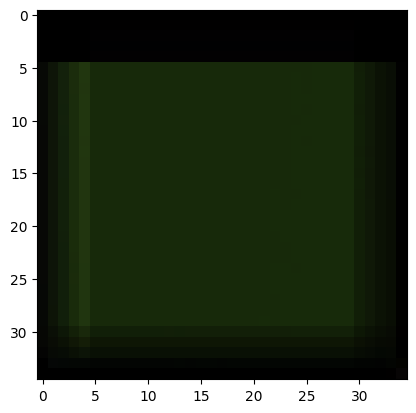

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.579139709472656, epoch:460/1000


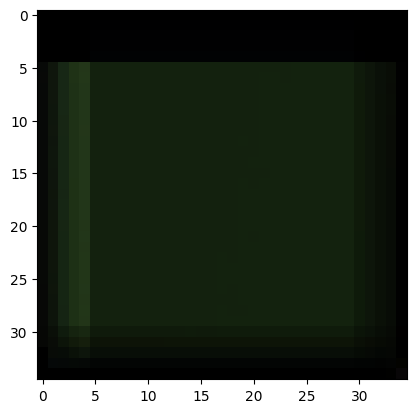

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.577229499816895, epoch:461/1000


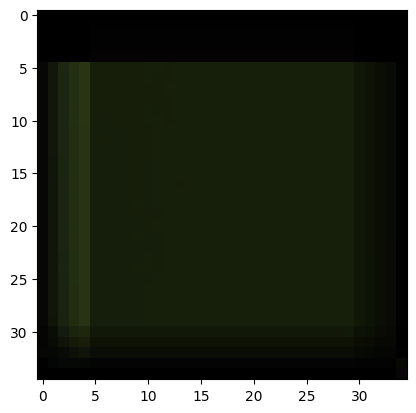

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.57547378540039, epoch:462/1000


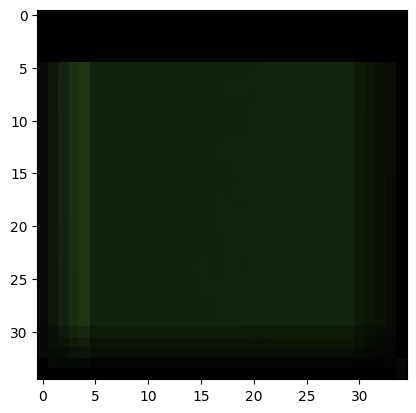

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.664632797241211, epoch:463/1000


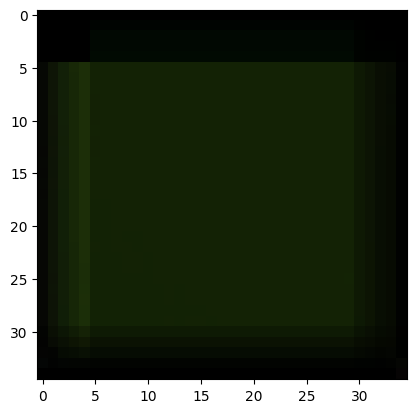

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.599769592285156, epoch:464/1000


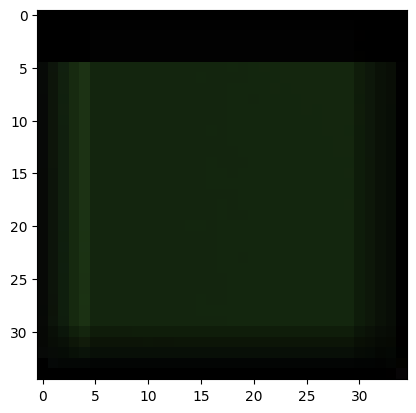

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.580306053161621, epoch:465/1000


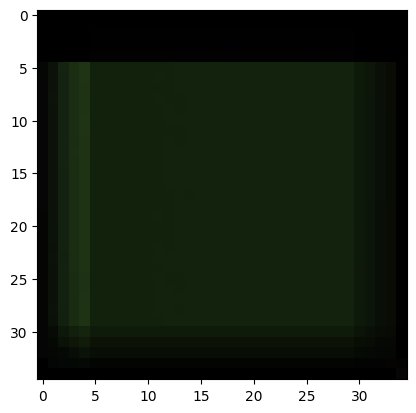

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.578618049621582, epoch:466/1000


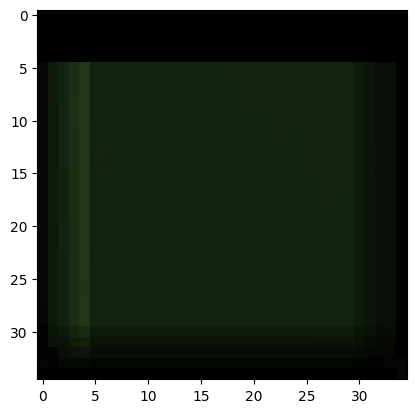

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.574469566345215, epoch:467/1000


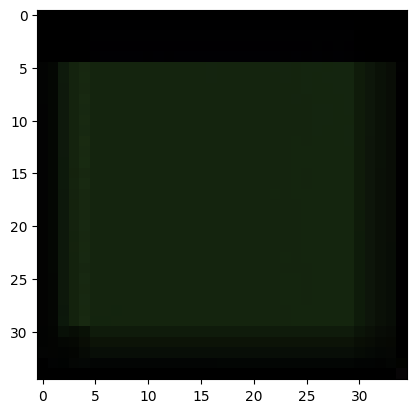

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.57590389251709, epoch:468/1000


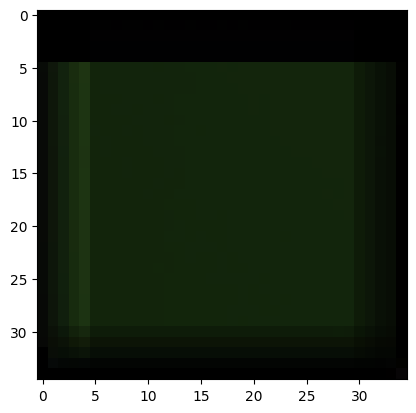

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.57574462890625, epoch:469/1000


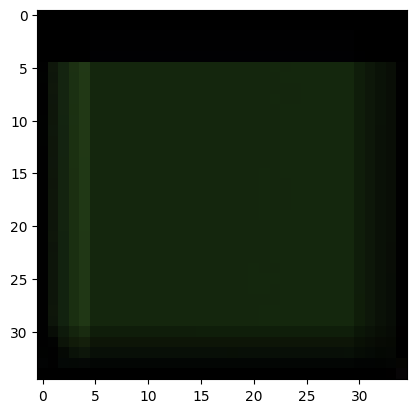

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.576565742492676, epoch:470/1000


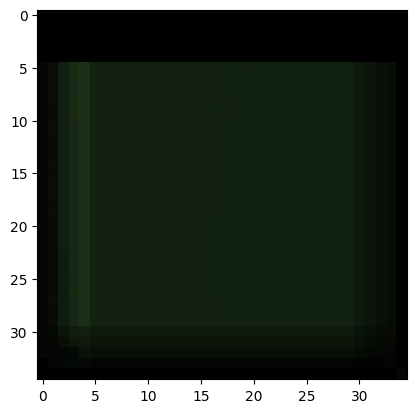

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.576868057250977, epoch:471/1000


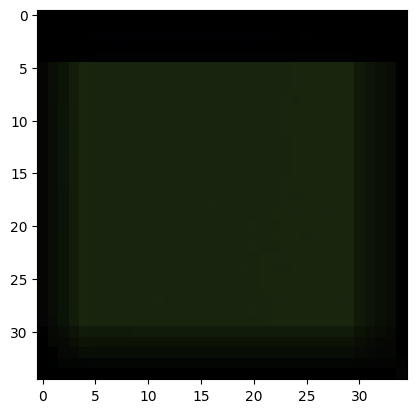

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.570408821105957, epoch:472/1000


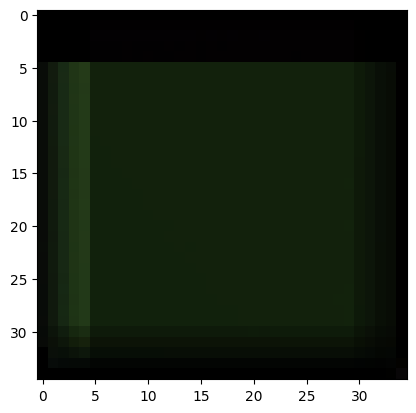

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.573802947998047, epoch:473/1000


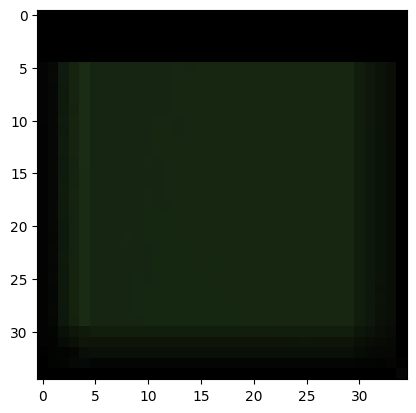

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.57181167602539, epoch:474/1000


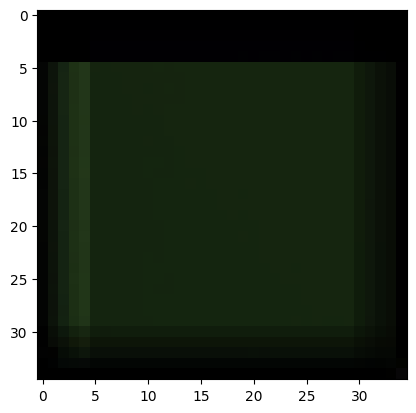

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.587254524230957, epoch:475/1000


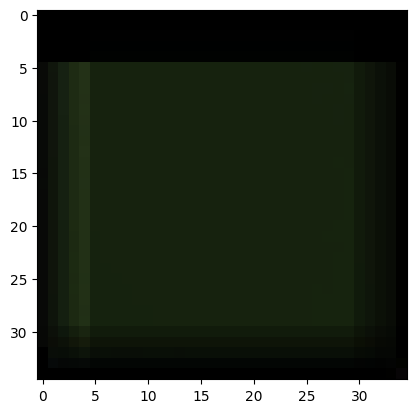

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.572200775146484, epoch:476/1000


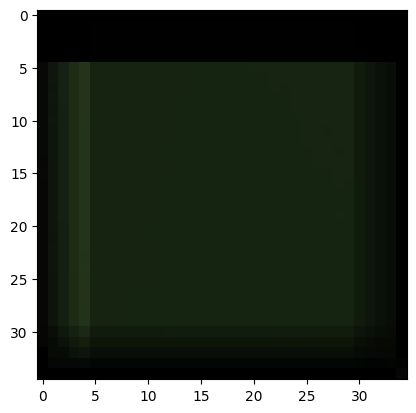

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.570384979248047, epoch:477/1000


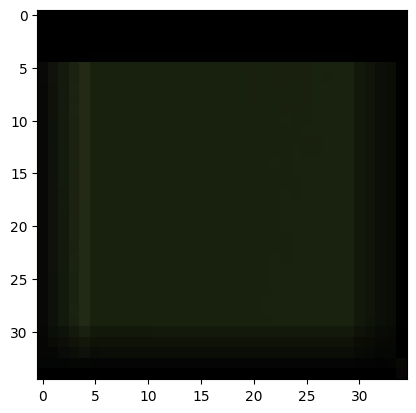

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.569939613342285, epoch:478/1000


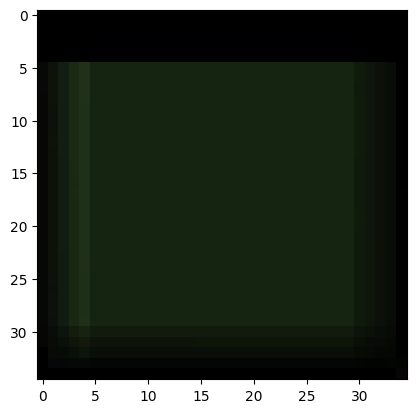

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.568359375, epoch:479/1000


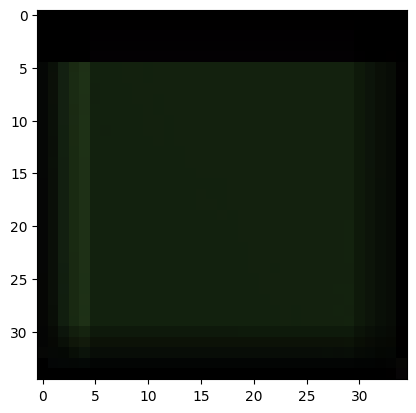

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.572723388671875, epoch:480/1000


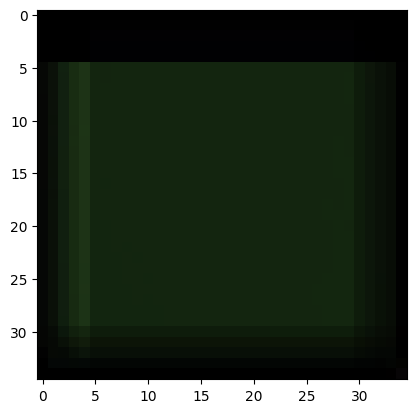

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.56792163848877, epoch:481/1000


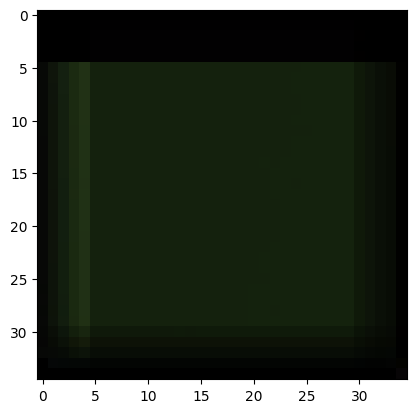

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.57158088684082, epoch:482/1000


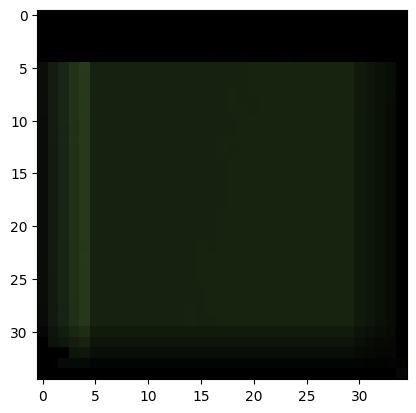

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.567895889282227, epoch:483/1000


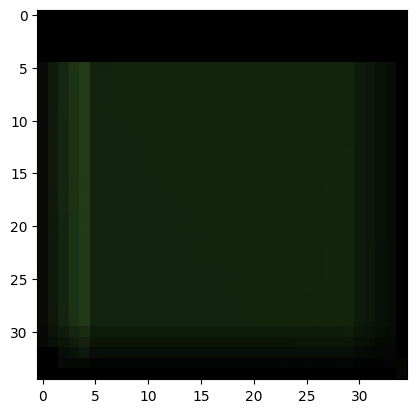

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.570252418518066, epoch:484/1000


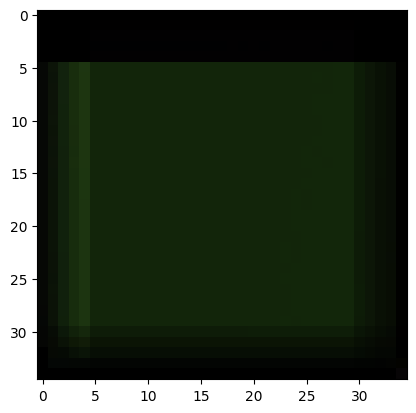

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.573662757873535, epoch:485/1000


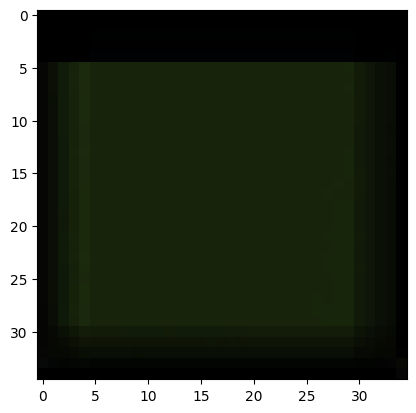

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.580809593200684, epoch:486/1000


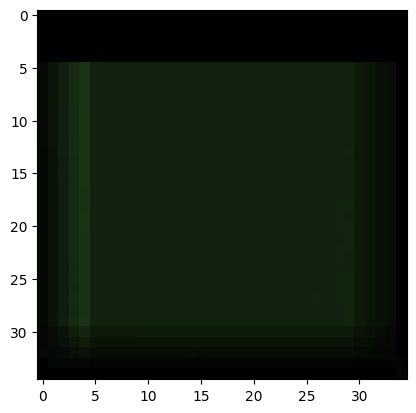

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.568290710449219, epoch:487/1000


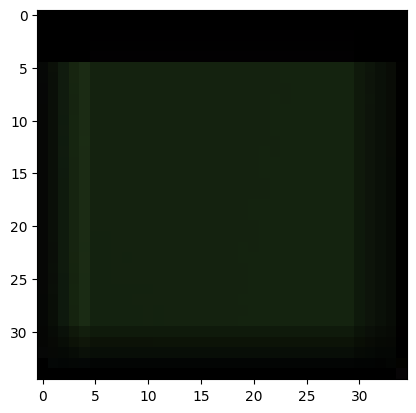

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.565622329711914, epoch:488/1000


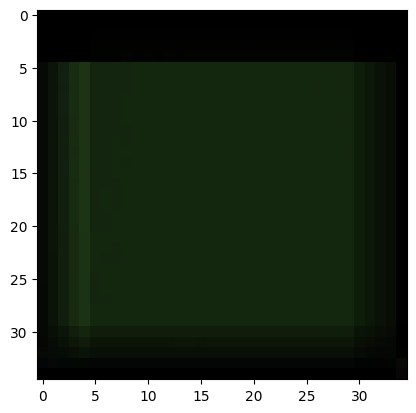

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.565303802490234, epoch:489/1000


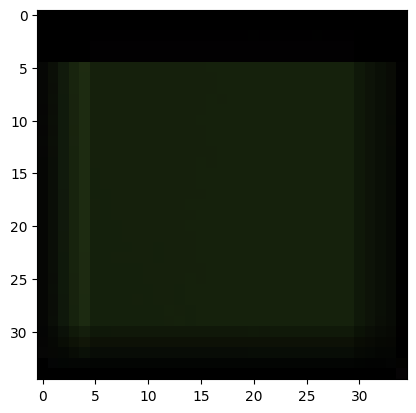

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.567428588867188, epoch:490/1000


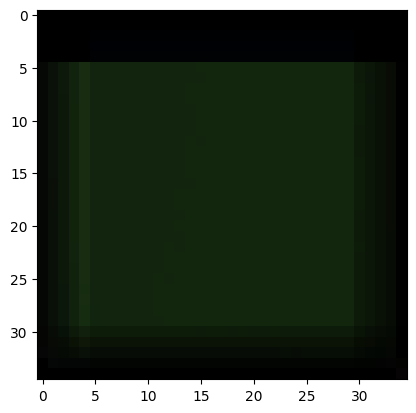

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.56602954864502, epoch:491/1000


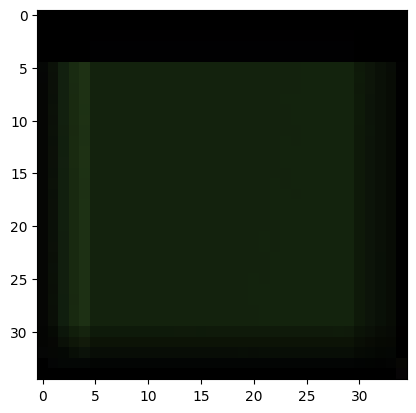

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.564297676086426, epoch:492/1000


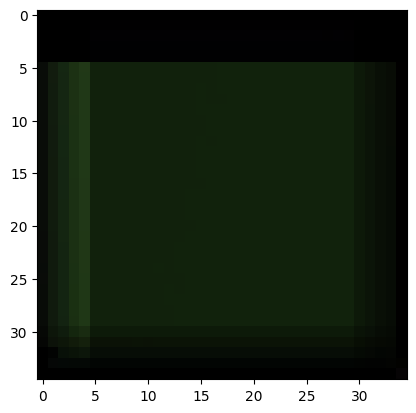

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.5779390335083, epoch:493/1000


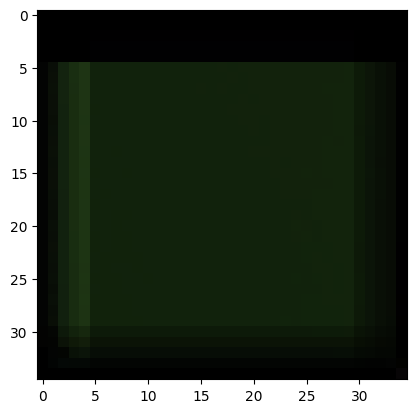

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.585168838500977, epoch:494/1000


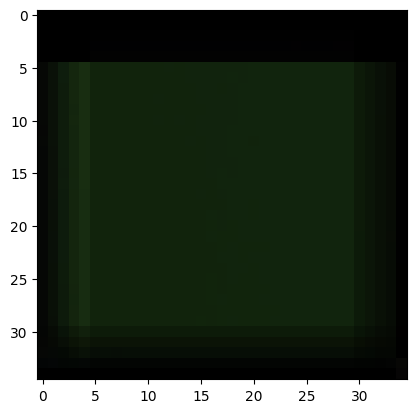

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.56434440612793, epoch:495/1000


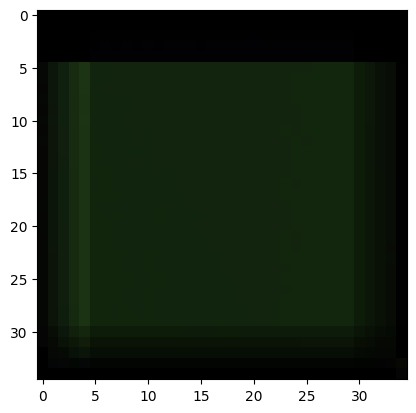

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.563281059265137, epoch:496/1000


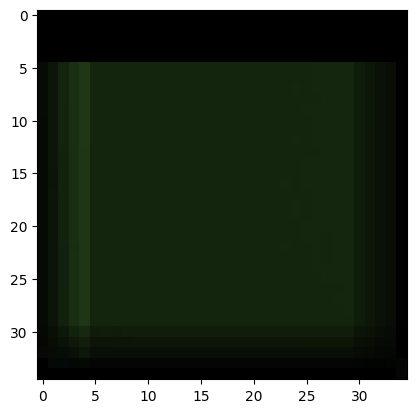

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.565953254699707, epoch:497/1000


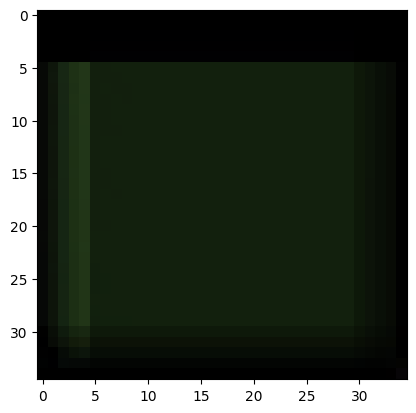

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.563701629638672, epoch:498/1000


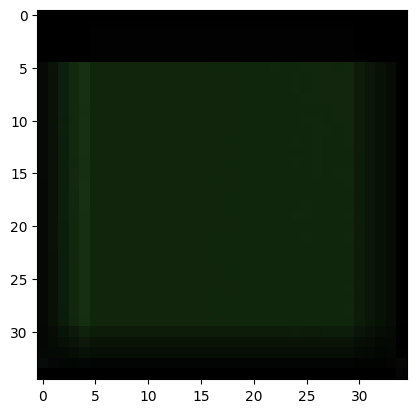

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.566001892089844, epoch:499/1000


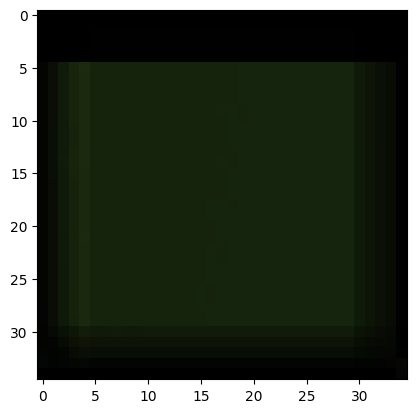

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.562188148498535, epoch:500/1000


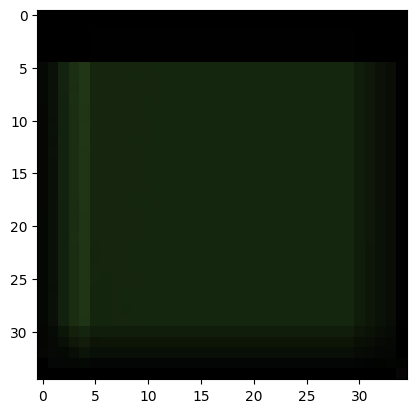

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.566336631774902, epoch:501/1000


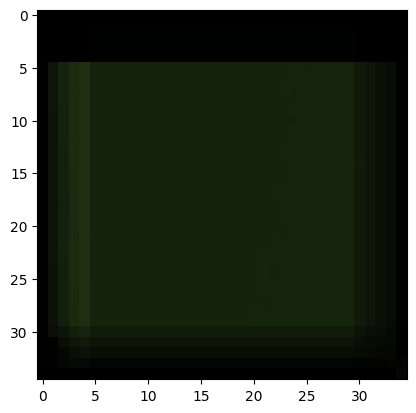

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.563043594360352, epoch:502/1000


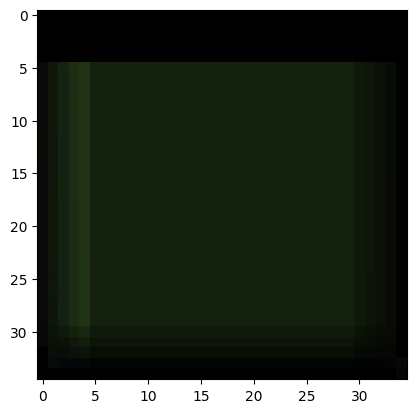

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.561652183532715, epoch:503/1000


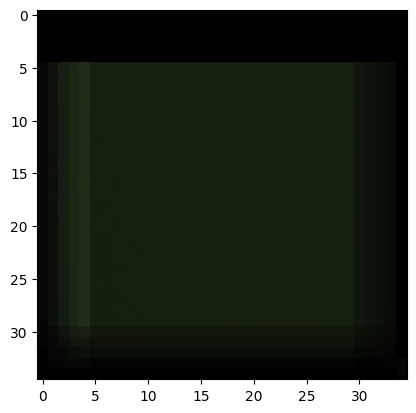

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.565991401672363, epoch:504/1000


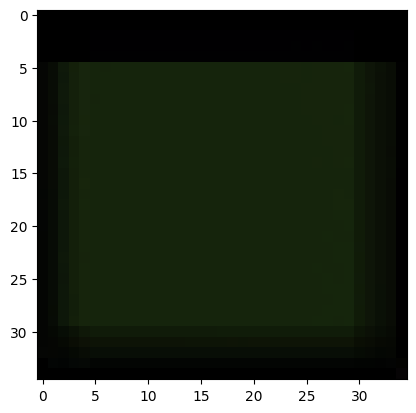

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.560225486755371, epoch:505/1000


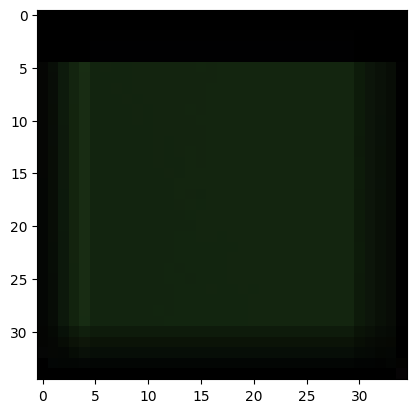

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.561495780944824, epoch:506/1000


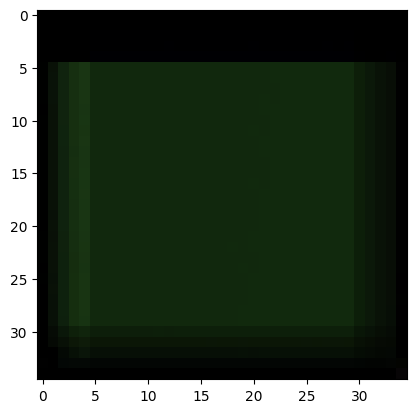

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.571439743041992, epoch:507/1000


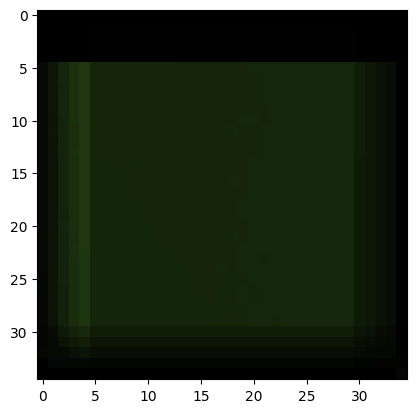

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.562808990478516, epoch:508/1000


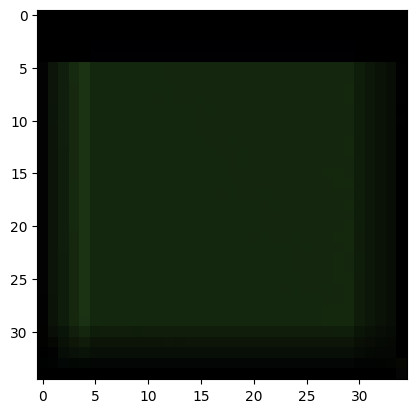

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.56883716583252, epoch:509/1000


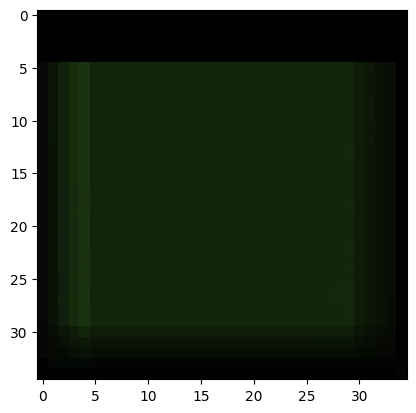

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.55964469909668, epoch:510/1000


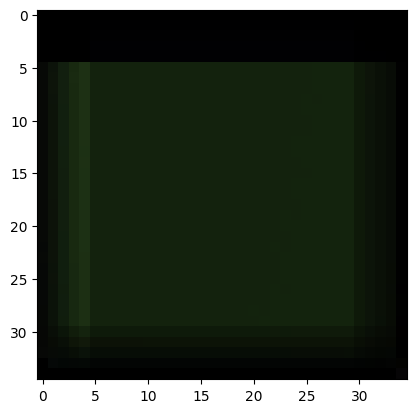

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.558480262756348, epoch:511/1000


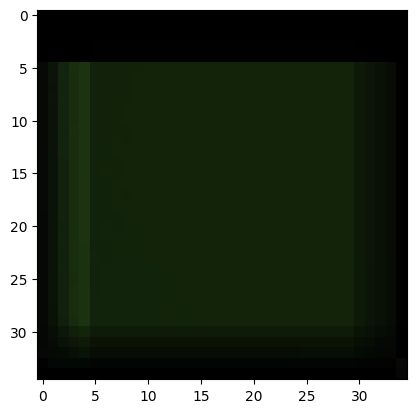

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.564271926879883, epoch:512/1000


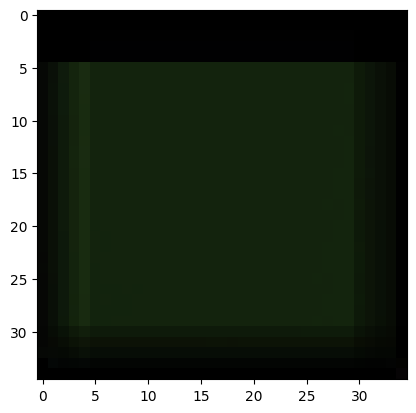

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.556965827941895, epoch:513/1000


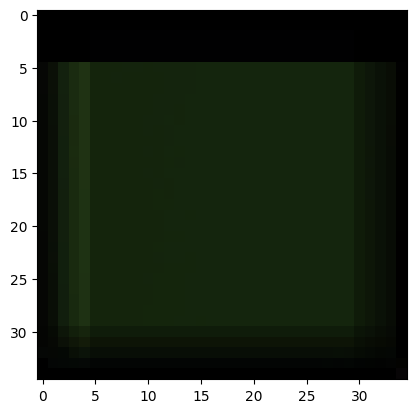

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.5564603805542, epoch:514/1000


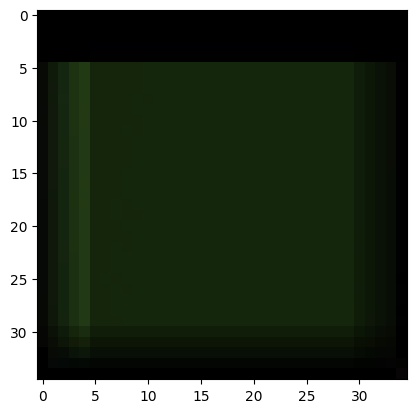

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.555418014526367, epoch:515/1000


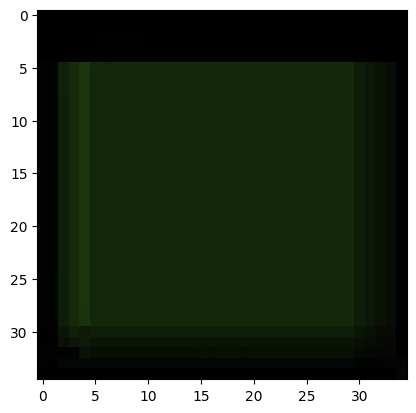

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 12.55567455291748, epoch:516/1000


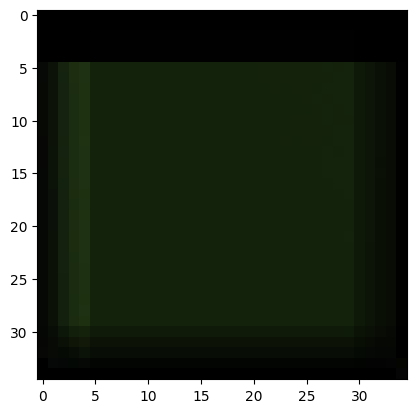

100%|██████████| 300/300 [00:54<00:00,  5.55it/s]


loss: 12.557242393493652, epoch:517/1000


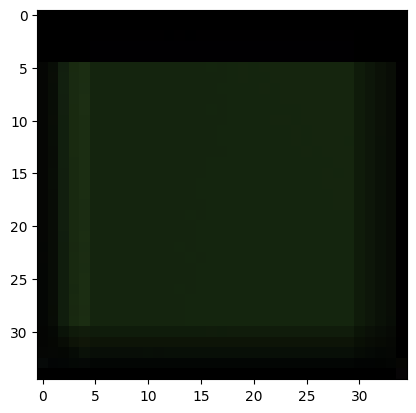

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.557758331298828, epoch:518/1000


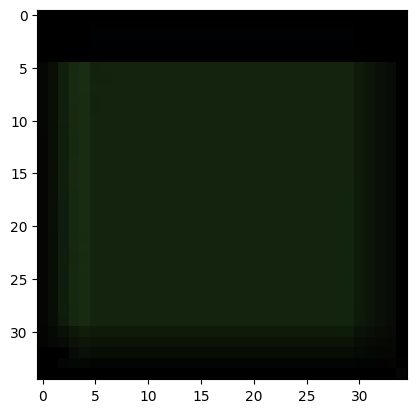

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.556310653686523, epoch:519/1000


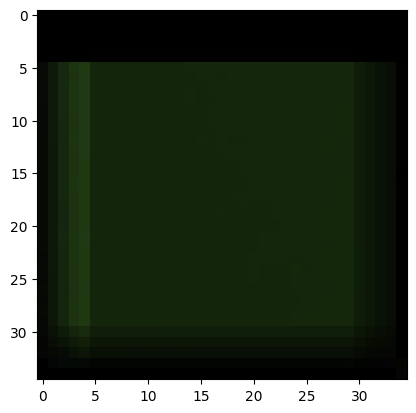

100%|██████████| 300/300 [00:54<00:00,  5.52it/s]


loss: 12.56090259552002, epoch:520/1000


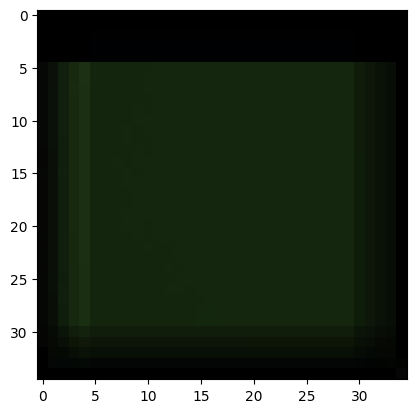

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.555558204650879, epoch:521/1000


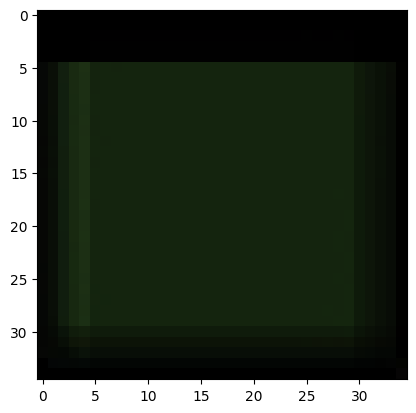

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.558424949645996, epoch:522/1000


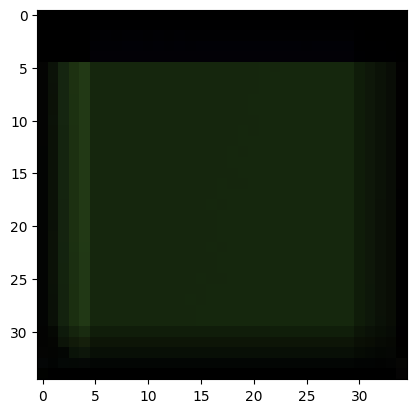

100%|██████████| 300/300 [00:54<00:00,  5.54it/s]


loss: 12.559046745300293, epoch:523/1000


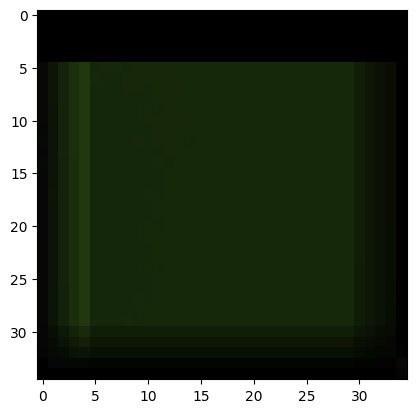

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.554482460021973, epoch:524/1000


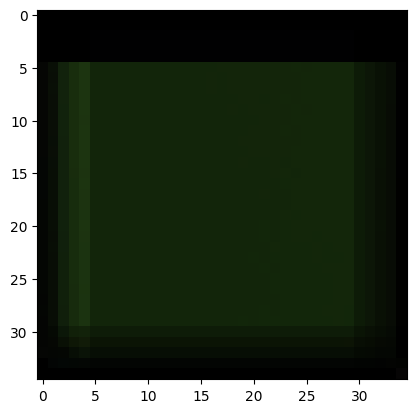

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.559614181518555, epoch:525/1000


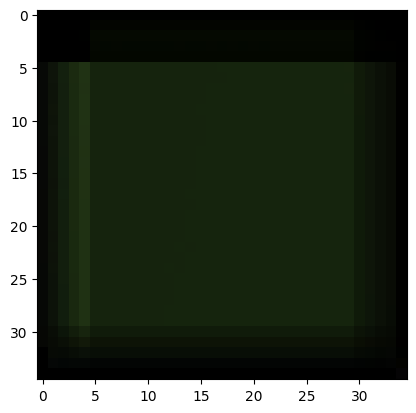

100%|██████████| 300/300 [00:54<00:00,  5.53it/s]


loss: 12.564007759094238, epoch:526/1000


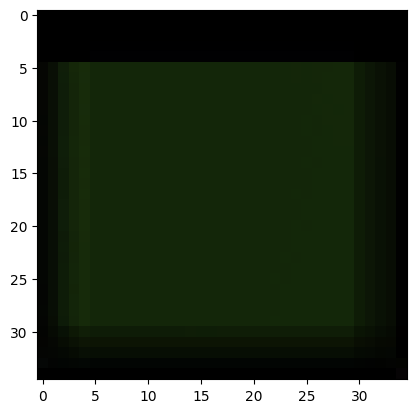

100%|██████████| 300/300 [00:54<00:00,  5.48it/s]


loss: 12.565603256225586, epoch:527/1000


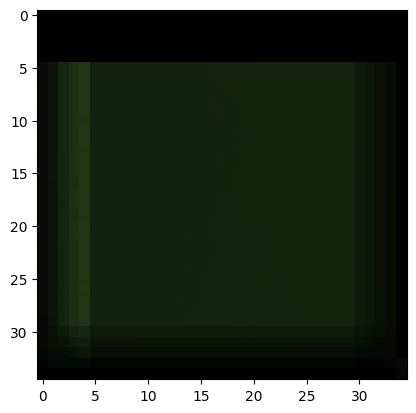

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.55344295501709, epoch:528/1000


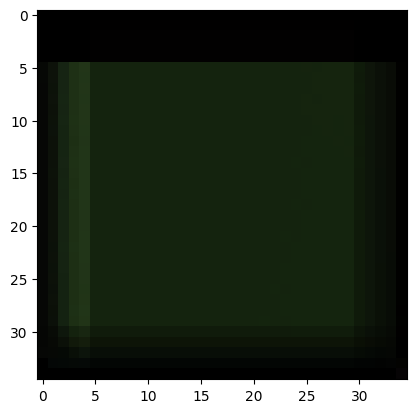

100%|██████████| 300/300 [00:54<00:00,  5.50it/s]


loss: 12.552221298217773, epoch:529/1000


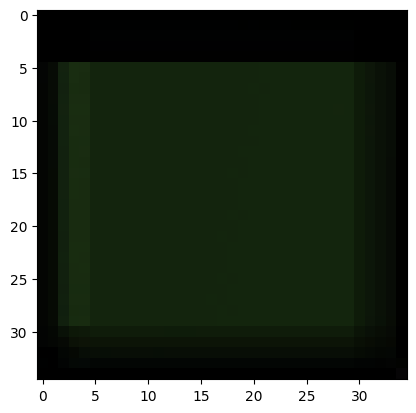

100%|██████████| 300/300 [00:54<00:00,  5.49it/s]


loss: 12.552804946899414, epoch:530/1000


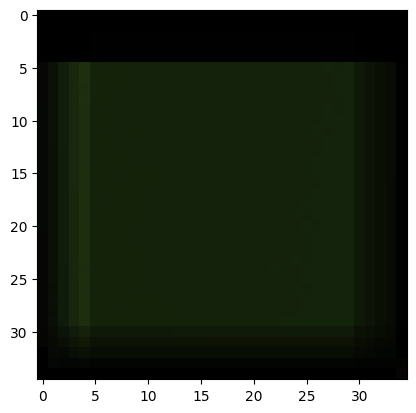

100%|██████████| 300/300 [00:54<00:00,  5.51it/s]


loss: 12.551416397094727, epoch:531/1000


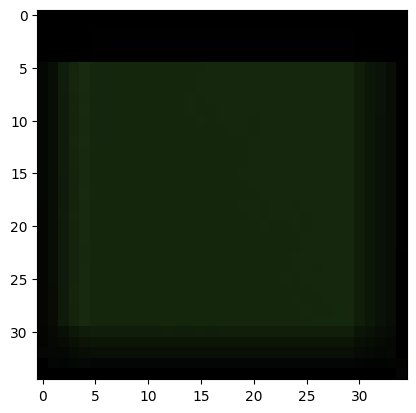

 48%|████▊     | 143/300 [00:27<00:30,  5.15it/s]


KeyboardInterrupt: 

In [9]:
iteration=0

for epohc in range(num_epochs):
    closs=0
    for idx,batch in enumerate(tqdm.tqdm(train_dataloader)):

        images=transform(batch['image']).to(device)

        optimizer.zero_grad()
        recon=model(images)
        loss=crit(recon,images)
        loss.backward()
        optimizer.step()
        
        closs+=loss.detach()
        del loss,recon,images
    loss_evolution+=[closs/len(train_dataloader)]
    sched.step()
    print(f"loss: {closs}, epoch:{epohc}/{num_epochs}")
    ##
    with torch.no_grad():
        plt.imshow(model(visual).detach().to('cpu')[0,:,:,:].permute(1,2,0))
        plt.show()
    ##
    if epohc%10==0:
        torch.save(model.state_dict(), model_dir+"/autosave.pt")
        with open(model_dir+'/stats.pkl', mode='wb') as file:
            pickle.dump(loss_evolution,file)

In [ ]:
torch.save(model.state_dict(), model_dir+"/epoch264+29perfinal.pt")

In [11]:
print(*[float(i.to('cpu').detach().numpy()) for i in loss_evolution],sep='\n')


0.0949830636382103
0.054437633603811264
0.054071325808763504
0.05375507473945618
0.053497735410928726
0.05332773178815842
0.05323297157883644
0.053181618452072144
0.053151994943618774
0.05313326418399811
0.05312043055891991
0.053111087530851364
0.05310393497347832
0.05309822037816048
0.053093574941158295
0.05308964103460312
0.0530862919986248
0.05308346450328827
0.05308104678988457
0.05307898297905922
0.053077295422554016
0.053075797855854034
0.053074561059474945
0.053073521703481674
0.053072739392519
0.05307214334607124
0.05307161435484886
0.05307120457291603
0.053070906549692154
0.053070634603500366
0.05307043343782425
0.053070276975631714
0.05307013913989067
0.053070034831762314
0.05306996405124664
0.05306990444660187
0.053069863468408585
0.053069818764925
0.053069788962602615
0.05306974798440933
0.05306972935795784
0.053069718182086945
0.05306967720389366
0.05306968837976456
0.053069666028022766
0.05306967720389366
0.053069666028022766
0.05306965857744217
0.053069643676280975
0.053

In [12]:
test_set=Tetrominoes("data/Tetrominoes",download=True,split="Test")
test_dataloader=torch.utils.data.DataLoader(train_set,batch_size=batch_size,shuffle=True,num_workers=num_workers)

In [15]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [23]:
import sklearn
import numpy as np

In [32]:
score=[]
model.eval()
with torch.no_grad():
    for test in tqdm.tqdm(test_set):
        img=transform(test["image"]).to(device).unsqueeze(0)
        _,masks=model(img,get_masks=True)
        lbl=torch.argmax(masks,dim=1)[0,:,:].to("cpu").flatten()
        labels=((((sum((it+1)*(v.flatten().numpy().astype(np.int32)//255) for it,v in enumerate(test['mask'][:,0,:,:]))))))
        score.append(sklearn.metrics.adjusted_rand_score(labels,lbl))
ari=np.mean(score)
print(f"ARI for meanshift rgb is ari={ari}")

100%|██████████| 5000/5000 [00:22<00:00, 225.10it/s]

ARI for meanshift rgb is ari=-0.08680849191417944
